# MEMORIA AI Prototype: Local LLM Evaluation

Deterministic 15-model local benchmark optimized for RTX 4060 (8 GB VRAM + CPU offload), using 5 size tiers with a sub-1B split: Ultra-Light (<0.5B), Small (0.5B to <1B), Medium (the prior Small class), Large (the prior Medium class), and Extra-Large (the prior Large class).

### Leaderboard Context

The original Hugging Face Open LLM Leaderboard (https://huggingface.co/spaces/open-llm-leaderboard/open_llm_leaderboard#/stopped) stopped accepting new submissions. We identified the most up-to-date and popular LLM leaderboard at LMSYS Chatbot Arena (https://huggingface.co/spaces/lmarena-ai/arena-leaderboard), which uses crowdsourced blind comparisons to rank models by human preference. While this notebook uses its own 14-rubric deterministic evaluation rather than the arena Elo system, the arena rankings helped inform which model families to prioritize for benchmarking.

### Model Source

Candidate models were sourced from the Hugging Face model hub filtered to 0-24B parameters sorted by trending (https://huggingface.co/models?num_parameters=min:0,max:24B&sort=trending). This filter ensures all 15 selected models are deployable on consumer hardware (RTX 4060 with 8 GB VRAM via quantization or CPU offload). Based on this board, we identified models that fit into our five size categories from across the Qwen, Microsoft Phi, Mistral, LiquidAI, HuggingFaceTB, and TinyLlama families.

### Cache Path Design

Model weights are downloaded to `llm_test/cache/huggingface-models/<vendor>__<model_name>/` using the transformers `cache_dir` parameter. For example, Qwen3.5-0.8B downloads to `cache/huggingface-models/Qwen__Qwen3_5-0_8B/`. The `.gitignore` excludes `llm_test/cache/` entirely to keep multi-gigabyte weight files out of version control. This means users do not need to re-download models every time they clone the repository; they simply run the notebook once to populate the cache. Once downloaded during notebook testing, the Django application reuses these same cached weights at runtime via `settings.BASE_DIR / "llm_test" / "cache" / "huggingface-models"`, so the model weights are shared between the Jupyter evaluation environment and the production Django server.

## Environment Setup (Default: RTX 4060 CUDA, Fallback: CPU)

Default setup for RTX 4060:

```bash
conda activate myenv-django
python -m pip install -r requirements.txt
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
python -m pip install -U transformers accelerate huggingface_hub bitsandbytes
hf auth login
hf auth whoami
```

CPU fallback setup if CUDA is not available:

```bash
python -m pip install -U transformers accelerate huggingface_hub
```

Notes:
- Benchmark uses the Transformers backend for all 15 pinned checkpoints.
- Default benchmark target is CUDA on RTX 4060.
- CPU fallback is supported but slower.
- Optional stability setting before launching Jupyter:

```bash
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
```

In [19]:
from pathlib import Path
import os
import gc
import sys
import json
import time
import traceback
import tempfile
import shutil
import warnings
import subprocess
import importlib.util
from datetime import datetime, timezone

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
_mplCache = Path("cache") / "matplotlib"
_mplCache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mplCache))

import torch
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI

warnings.filterwarnings("ignore", message=r".*IProgress not found.*")
warnings.filterwarnings("ignore", message=r".*tied weights mapping and config for this model specifies to tie.*")
warnings.filterwarnings("ignore", message=r".*Some parameters are on the meta device because they were offloaded to the disk.*")


## Hugging Face Login Reminder

Before running any model cells, authenticate in terminal:

```bash
hf auth login
hf auth whoami
```

Use `hf` CLI, not `huggingface-cli`.

In [20]:
if (Path.cwd() / "ai_prototype.ipynb").exists():
    NOTEBOOK_DIR = Path.cwd()
elif (Path.cwd() / "llm_test" / "ai_prototype.ipynb").exists():
    NOTEBOOK_DIR = Path.cwd() / "llm_test"
else:
    raise RuntimeError("Unable to determine notebook directory. Start from repo root or llm_test.")

REPO_ROOT = NOTEBOOK_DIR.parent
ENV_PATH = REPO_ROOT / ".env"
if ENV_PATH.exists():
    load_dotenv(ENV_PATH)

CACHE_ROOT_REL = Path("cache") / "huggingface-models"
RESULTS_DIR_REL = Path("results")
BY_MODEL_DIR_REL = RESULTS_DIR_REL / "by_model"
RUN_LOG_JSONL_REL = RESULTS_DIR_REL / "model_runs.jsonl"
MERGED_RESULTS_REL = RESULTS_DIR_REL / "merged_results.json"

CACHE_ROOT = NOTEBOOK_DIR / CACHE_ROOT_REL
RESULTS_DIR = NOTEBOOK_DIR / RESULTS_DIR_REL
BY_MODEL_DIR = NOTEBOOK_DIR / BY_MODEL_DIR_REL
RUN_LOG_JSONL_PATH = NOTEBOOK_DIR / RUN_LOG_JSONL_REL
MERGED_RESULTS_PATH = NOTEBOOK_DIR / MERGED_RESULTS_REL

CACHE_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
BY_MODEL_DIR.mkdir(parents=True, exist_ok=True)

OPENAI_MODEL = os.environ.get("OPENAI_MODEL", "gpt-5-pro")
OPENAI_REASONING_EFFORT = os.environ.get("OPENAI_REASONING_EFFORT", "high")
BENCHMARK_SCHEMA_VERSION = "2026-03-07-gpt5pro-responsequality-v2"
print("Path setup initialized")
print(f"Cache dir (relative): {CACHE_ROOT_REL.as_posix()}")
print(f"Results dir (relative): {RESULTS_DIR_REL.as_posix()}")
print(f"OpenAI judge model: {OPENAI_MODEL}")
print(f"OpenAI judge reasoning: {OPENAI_REASONING_EFFORT}")
print(f"Benchmark schema version: {BENCHMARK_SCHEMA_VERSION}")

Path setup initialized
Cache dir (relative): cache/huggingface-models
Results dir (relative): results
OpenAI judge model: gpt-5.1
OpenAI judge reasoning: high
Benchmark schema version: 2026-03-07-gpt5pro-responsequality-v2


In [21]:
def getSystemRamGb():
    if hasattr(os, "sysconf") and "SC_PAGE_SIZE" in os.sysconf_names and "SC_PHYS_PAGES" in os.sysconf_names:
        pageSize = os.sysconf("SC_PAGE_SIZE")
        pages = os.sysconf("SC_PHYS_PAGES")
        return round((pageSize * pages) / (1024 ** 3), 2)
    try:
        import psutil
        return round(psutil.virtual_memory().total / (1024 ** 3), 2)
    except ImportError:
        pass
    return 0.0


def isPackageInstalled(moduleName):
    return importlib.util.find_spec(moduleName) is not None


if torch.cuda.is_available():
    DEVICE = "cuda"
    gpuName = torch.cuda.get_device_name(0)
    gpuProps = torch.cuda.get_device_properties(0)
    gpuVramGb = round(gpuProps.total_memory / (1024 ** 3), 2)
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    gpuName = "Apple MPS"
    gpuVramGb = 0.0
else:
    DEVICE = "cpu"
    gpuName = "None"
    gpuVramGb = 0.0

systemRamGb = getSystemRamGb()

if DEVICE == "cuda":
    RUNTIME_PROFILE = "rtx4060"
else:
    RUNTIME_PROFILE = "cpu_fallback"

HARDWARE_INFO = {
    "device": DEVICE,
    "gpuName": gpuName,
    "gpuVramGb": gpuVramGb,
    "systemRamGb": systemRamGb,
    "bitsandbytesInstalled": isPackageInstalled("bitsandbytes"),
    "llamaCppInstalled": isPackageInstalled("llama_cpp"),
}

print("Runtime preflight")
print(f"RUNTIME_PROFILE: {RUNTIME_PROFILE}")
print(f"Device: {DEVICE}")
print(f"GPU: {gpuName}")
print(f"GPU VRAM (GB): {gpuVramGb}")
print(f"System RAM (GB): {systemRamGb}")
print(f"bitsandbytes installed: {HARDWARE_INFO['bitsandbytesInstalled']}")
print(f"llama_cpp installed: {HARDWARE_INFO['llamaCppInstalled']}")

if RUNTIME_PROFILE == "rtx4060" and "4060" not in gpuName:
    print("Warning: CUDA detected but GPU name does not include 4060. 4060 profile will still be applied.")



if RUNTIME_PROFILE == "cpu_fallback":
    print("CPU fallback profile active. Runs may be very slow.")

Runtime preflight
RUNTIME_PROFILE: rtx4060
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU VRAM (GB): 8.0
System RAM (GB): 31.63
bitsandbytes installed: True
llama_cpp installed: False


## Worker Runtime Notes and Model Selection References

- Worker runs in a subprocess, captures stdout/stderr, and now passes `attention_mask` through generation.
- Tokenizer-marker corruption now hard-fails only if markers remain after cleanup.
- Active benchmark runs with thinking disabled by default so scoring targets final recipe output.
- The two DeepSeek failures were replaced with benchmark-fit text-generation models.

Replacement references:
- microsoft/Phi-4-mini-instruct (3.8B): https://huggingface.co/microsoft/Phi-4-mini-instruct
- Qwen/Qwen2.5-7B-Instruct (7.6B): https://huggingface.co/Qwen/Qwen2.5-7B-Instruct
- Qwen/Qwen3-8B (8.2B): https://huggingface.co/Qwen/Qwen3-8B

Model selection references:
- LMSYS Chatbot Arena Leaderboard: https://huggingface.co/spaces/lmarena-ai/arena-leaderboard
- Hugging Face Hub (0-24B, trending): https://huggingface.co/models?num_parameters=min:0,max:24B&sort=trending

Plots and summary tables use parameter-aware display labels so models without size tokens in their repo IDs still render with their parameter counts.


In [22]:
MODEL_REGISTRY = [
  {
    "modelId": "Qwen/Qwen2.5-0.5B-Instruct",
    "family": "Qwen",
    "category": "Ultra-Light",
    "params": "0.5B",
    "version": "Qwen2.5",
    "license": "Apache-2.0"
  },
  {
    "modelId": "LiquidAI/LFM2-350M",
    "family": "LiquidAI",
    "category": "Ultra-Light",
    "params": "0.35B",
    "version": "LFM2",
    "license": "Other"
  },
  {
    "modelId": "HuggingFaceTB/SmolLM2-135M-Instruct",
    "family": "HuggingFaceTB",
    "category": "Ultra-Light",
    "params": "0.135B",
    "version": "SmolLM2",
    "license": "Apache-2.0"
  },
  {
    "modelId": "Qwen/Qwen3.5-0.8B",
    "family": "Qwen",
    "category": "Small",
    "params": "0.8B",
    "version": "Qwen3.5",
    "license": "Apache-2.0"
  },
  {
    "modelId": "LiquidAI/LFM2-700M",
    "family": "LiquidAI",
    "category": "Small",
    "params": "0.7B",
    "version": "LFM2",
    "license": "Other"
  },
  {
    "modelId": "Qwen/Qwen3-0.6B",
    "family": "Qwen",
    "category": "Small",
    "params": "0.6B",
    "version": "Qwen3",
    "license": "Apache-2.0"
  },
  {
    "modelId": "Qwen/Qwen3.5-2B",
    "family": "Qwen",
    "category": "Medium",
    "params": "2B",
    "version": "Qwen3.5",
    "license": "Apache-2.0"
  },
  {
    "modelId": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    "family": "TinyLlama",
    "category": "Medium",
    "params": "1.1B",
    "version": "TinyLlama",
    "license": "Apache-2.0"
  },
  {
    "modelId": "microsoft/phi-2",
    "family": "Microsoft",
    "category": "Medium",
    "params": "2.7B",
    "version": "Phi-2",
    "license": "MIT"
  },
  {
    "modelId": "Qwen/Qwen3.5-4B",
    "family": "Qwen",
    "category": "Large",
    "params": "4B",
    "version": "Qwen3.5",
    "license": "Apache-2.0"
  },
  {
    "modelId": "microsoft/Phi-3.5-mini-instruct",
    "family": "Microsoft",
    "category": "Large",
    "params": "3.8B",
    "version": "Phi-3.5",
    "license": "MIT"
  },
  {
    "modelId": "microsoft/Phi-4-mini-instruct",
    "family": "Microsoft",
    "category": "Large",
    "params": "3.8B",
    "version": "Phi-4-mini",
    "license": "MIT"
  },
  {
    "modelId": "Qwen/Qwen3-8B",
    "family": "Qwen",
    "category": "Extra-Large",
    "params": "8.2B",
    "version": "Qwen3",
    "license": "Apache-2.0"
  },
  {
    "modelId": "mistralai/Mistral-7B-Instruct-v0.2",
    "family": "Mistral",
    "category": "Extra-Large",
    "params": "7B",
    "version": "v0.2",
    "license": "Apache-2.0"
  },
  {
    "modelId": "Qwen/Qwen2.5-7B-Instruct",
    "family": "Qwen",
    "category": "Extra-Large",
    "params": "7.6B",
    "version": "Qwen2.5",
    "license": "Apache-2.0"
  }
]

MODEL_BY_ID = {entry["modelId"]: entry for entry in MODEL_REGISTRY}


def modelSlug(modelId):
    return (modelId or "").split("/")[-1]


def buildModelDisplayLabel(modelId, params=""):
    import re

    slug = modelSlug(modelId)
    if re.search(r"(?<![A-Za-z0-9])\d+(?:\.\d+)?[BM](?![A-Za-z0-9])", slug):
        return slug
    if params:
        return f"{slug} ({params})"
    return slug


MODEL_LABEL_BY_ID = {
    entry["modelId"]: buildModelDisplayLabel(entry["modelId"], entry["params"])
    for entry in MODEL_REGISTRY
}


def getModelDisplayLabel(modelId, params=""):
    if modelId in MODEL_LABEL_BY_ID:
        return MODEL_LABEL_BY_ID[modelId]
    return buildModelDisplayLabel(modelId, params)


print(f"Total models: {len(MODEL_REGISTRY)}")


Total models: 15


In [23]:
def sanitizeModelId(modelId):
    return modelId.replace("/", "__").replace(".", "_").replace(":", "_")


EXECUTION_MAP_RTX4060 = {'Qwen/Qwen2.5-0.5B-Instruct': {'executionModelId': 'Qwen/Qwen2.5-0.5B-Instruct',
                                'executionFallbackModelId': '',
                                'executionFallbackReason': '',
                                'backend': 'transformers',
                                'quantizationMode': 'none',
                                'ggufFile': '',
                                'surrogateUsed': False,
                                'surrogateReason': ''},
 'LiquidAI/LFM2-350M': {'executionModelId': 'LiquidAI/LFM2-350M',
                        'executionFallbackModelId': '',
                        'executionFallbackReason': '',
                        'backend': 'transformers',
                        'quantizationMode': 'none',
                        'ggufFile': '',
                        'surrogateUsed': False,
                        'surrogateReason': ''},
 'HuggingFaceTB/SmolLM2-135M-Instruct': {'executionModelId': 'HuggingFaceTB/SmolLM2-135M-Instruct',
                                         'executionFallbackModelId': '',
                                         'executionFallbackReason': '',
                                         'backend': 'transformers',
                                         'quantizationMode': 'none',
                                         'ggufFile': '',
                                         'surrogateUsed': False,
                                         'surrogateReason': ''},
 'Qwen/Qwen3.5-0.8B': {'executionModelId': 'Qwen/Qwen3.5-0.8B',
                       'executionFallbackModelId': '',
                       'executionFallbackReason': '',
                       'backend': 'transformers',
                       'quantizationMode': 'none',
                       'ggufFile': '',
                       'surrogateUsed': False,
                       'surrogateReason': ''},
 'LiquidAI/LFM2-700M': {'executionModelId': 'LiquidAI/LFM2-700M',
                        'executionFallbackModelId': '',
                        'executionFallbackReason': '',
                        'backend': 'transformers',
                        'quantizationMode': 'none',
                        'ggufFile': '',
                        'surrogateUsed': False,
                        'surrogateReason': ''},
 'Qwen/Qwen3-0.6B': {'executionModelId': 'Qwen/Qwen3-0.6B',
                     'executionFallbackModelId': '',
                     'executionFallbackReason': '',
                     'backend': 'transformers',
                     'quantizationMode': 'none',
                     'ggufFile': '',
                     'surrogateUsed': False,
                     'surrogateReason': ''},
 'Qwen/Qwen3.5-2B': {'executionModelId': 'Qwen/Qwen3.5-2B',
                     'executionFallbackModelId': '',
                     'executionFallbackReason': '',
                     'backend': 'transformers',
                     'quantizationMode': 'none',
                     'ggufFile': '',
                     'surrogateUsed': False,
                     'surrogateReason': ''},
 'TinyLlama/TinyLlama-1.1B-Chat-v1.0': {'executionModelId': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
                                        'executionFallbackModelId': '',
                                        'executionFallbackReason': '',
                                        'backend': 'transformers',
                                        'quantizationMode': 'none',
                                        'ggufFile': '',
                                        'surrogateUsed': False,
                                        'surrogateReason': ''},
 'microsoft/phi-2': {'executionModelId': 'microsoft/phi-2',
                     'executionFallbackModelId': '',
                     'executionFallbackReason': '',
                     'backend': 'transformers',
                     'quantizationMode': 'none',
                     'ggufFile': '',
                     'surrogateUsed': False,
                     'surrogateReason': ''},
 'Qwen/Qwen3.5-4B': {'executionModelId': 'Qwen/Qwen3.5-4B',
                     'executionFallbackModelId': '',
                     'executionFallbackReason': '',
                     'backend': 'transformers',
                     'quantizationMode': 'bnb4',
                     'ggufFile': '',
                     'surrogateUsed': False,
                     'surrogateReason': ''},
 'microsoft/Phi-3.5-mini-instruct': {'executionModelId': 'microsoft/Phi-3.5-mini-instruct',
                                     'executionFallbackModelId': '',
                                     'executionFallbackReason': '',
                                     'backend': 'transformers',
                                     'quantizationMode': 'bnb4',
                                     'ggufFile': '',
                                     'surrogateUsed': False,
                                     'surrogateReason': ''},
 'microsoft/Phi-4-mini-instruct': {'executionModelId': 'microsoft/Phi-4-mini-instruct',
                                   'executionFallbackModelId': '',
                                   'executionFallbackReason': '',
                                   'backend': 'transformers',
                                   'quantizationMode': 'bnb4',
                                   'ggufFile': '',
                                   'surrogateUsed': False,
                                   'surrogateReason': ''},
 'Qwen/Qwen3-8B': {'executionModelId': 'Qwen/Qwen3-8B',
                   'executionFallbackModelId': '',
                   'executionFallbackReason': '',
                   'backend': 'transformers',
                   'quantizationMode': 'bnb4',
                   'ggufFile': '',
                   'surrogateUsed': False,
                   'surrogateReason': ''},
 'mistralai/Mistral-7B-Instruct-v0.2': {'executionModelId': 'mistralai/Mistral-7B-Instruct-v0.2',
                                        'executionFallbackModelId': '',
                                        'executionFallbackReason': '',
                                        'backend': 'transformers',
                                        'quantizationMode': 'bnb4',
                                        'ggufFile': '',
                                        'surrogateUsed': False,
                                        'surrogateReason': ''},
 'Qwen/Qwen2.5-7B-Instruct': {'executionModelId': 'Qwen/Qwen2.5-7B-Instruct',
                              'executionFallbackModelId': '',
                              'executionFallbackReason': '',
                              'backend': 'transformers',
                              'quantizationMode': 'bnb4',
                              'ggufFile': '',
                              'surrogateUsed': False,
                              'surrogateReason': ''}}

EXECUTION_MAP_CPU_FALLBACK = dict(EXECUTION_MAP_RTX4060)

if RUNTIME_PROFILE == "rtx4060":
    EXECUTION_MAP = EXECUTION_MAP_RTX4060
else:
    EXECUTION_MAP = EXECUTION_MAP_CPU_FALLBACK


def buildGenerationConfig(family):
    if family == "Qwen":
        return {"primary": {"do_sample": True, "temperature": 0.6, "top_p": 0.92, "repetition_penalty": 1.08}, "fallback": {"do_sample": True, "temperature": 0.5, "top_p": 0.88, "repetition_penalty": 1.1, "use_cache": False}}
    return {"primary": {"do_sample": True, "temperature": 0.7, "top_p": 0.9, "repetition_penalty": 1.12}, "fallback": {"do_sample": True, "temperature": 0.6, "top_p": 0.85, "repetition_penalty": 1.15, "use_cache": False}}


MODEL_CONFIGS = {}

for entry in MODEL_REGISTRY:
    modelId = entry["modelId"]
    mapped = EXECUTION_MAP[modelId]
    generation = buildGenerationConfig(entry["family"])
    if mapped["quantizationMode"] == "none": maxNewTokensPrimary, maxNewTokensFallback = 1024, 512
    elif mapped["quantizationMode"] == "bnb4": maxNewTokensPrimary, maxNewTokensFallback = 640, 320
    else: maxNewTokensPrimary, maxNewTokensFallback = 512, 256
    modelKwargs = {"low_cpu_mem_usage": True, "attnImplementation": "sdpa"}
    if mapped["quantizationMode"] == "bnb4": modelKwargs.update({"bnb4bitQuantType": "nf4", "bnb4bitComputeDtype": "float16", "bnb4bitUseDoubleQuant": True})
    config = {"modelId": modelId, "targetModelId": modelId, "executionModelId": mapped["executionModelId"], "executionFallbackModelId": mapped["executionFallbackModelId"], "executionFallbackReason": mapped["executionFallbackReason"], "family": entry["family"], "category": entry["category"], "cacheDir": f"cache/huggingface-models/{sanitizeModelId(modelId)}", "cacheScope": "model-local", "backend": mapped["backend"], "quantizationMode": mapped["quantizationMode"], "ggufFile": mapped["ggufFile"], "surrogateUsed": mapped["surrogateUsed"], "surrogateReason": mapped["surrogateReason"], "trustRemoteCode": True, "dtype": "float16", "deviceMap": "auto", "maxInputTokens": 1536, "maxNewTokensPrimary": maxNewTokensPrimary, "maxNewTokensFallback": maxNewTokensFallback, "cudaMaxMemory": "7.5GiB", "cudaLoadRetryMaxMemory": "6.5GiB", "cpuOffloadMaxMemory": "24GiB", "workerTimeoutSec": 3600, "generationPrimary": generation["primary"], "generationFallback": generation["fallback"], "thinkingRequested": False, "thinkingEnforcementMode": "disabled", "templateKwargs": {}, "tokenizerKwargs": {"use_fast": True}, "modelKwargs": modelKwargs}
    if modelId in {"microsoft/Phi-3.5-mini-instruct", "microsoft/Phi-4-mini-instruct"}: config["trustRemoteCode"] = False; config["modelKwargs"]["attnImplementation"] = "eager"
    if modelId == "Qwen/Qwen3-8B":
        config["maxNewTokensPrimary"] = min(int(config["maxNewTokensPrimary"]), 512)
        config["maxNewTokensFallback"] = min(int(config["maxNewTokensFallback"]), 256)
        config["generationPrimary"] = {"do_sample": True, "temperature": 0.7, "top_p": 0.8, "repetition_penalty": 1.08}
        config["generationFallback"] = {"do_sample": True, "temperature": 0.65, "top_p": 0.75, "repetition_penalty": 1.1, "use_cache": False}
    MODEL_CONFIGS[modelId] = config

REQUIRED_CONFIG_KEYS = ["modelId", "targetModelId", "executionModelId", "executionFallbackModelId", "executionFallbackReason", "family", "category", "cacheDir", "cacheScope", "backend", "quantizationMode", "ggufFile", "surrogateUsed", "surrogateReason", "trustRemoteCode", "dtype", "deviceMap", "maxInputTokens", "maxNewTokensPrimary", "maxNewTokensFallback", "cudaMaxMemory", "cudaLoadRetryMaxMemory", "cpuOffloadMaxMemory", "workerTimeoutSec", "generationPrimary", "generationFallback", "thinkingRequested", "thinkingEnforcementMode", "templateKwargs", "tokenizerKwargs", "modelKwargs"]

print(f"Model config count: {len(MODEL_CONFIGS)}")


Model config count: 15


## Section 2: Prompt and Rubrics

### System Prompt

```text
Role & Purpose
You are Shelby's Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby's product from the approved product list. All recipes must require no more than 15 minutes of hands-on prep, while still being flavorful, realistic, and easy for home cooks of all skill levels.

Core Rules
1. Food Allergy Rules (Absolute)

Never include peanuts or dairy.

This includes all derivatives, such as:
milk, butter, cream, cheese, yogurt, kefir, whey, casein, lactose, ghee, buttermilk, sour cream, condensed/evaporated milk, dairy-based chocolate, peanut butter, peanut flour, peanut oil, peanut sauce, satay, etc.

Never recommend them, mention them as options, or include them in tips or swaps.

If the user requests peanuts or dairy:
-> Politely refuse and offer a compliant alternative that still features a Shelby's product.

2. Product Inclusion Rule

Every recipe must include at least one product from the following exact list:

products = [
    "Shelby's Raw Honey (16oz)",
    "Shelby's Pork Breakfast Links",
    "Shelby's Farm-Fresh Eggs (Dozen)",
    "Shelby's Maple Syrup (12oz)",
    "Shelby's Grass-Fed Ground Beef (1lb)",
    "Shelby's Pasture-Raised Chicken Breast (2-Pack)",
    "Shelby's Heritage Smoked Bacon",
    "Shelby's Rustic Sourdough Bread",
    "Shelby's Garden Salsa (Medium)",
    "Shelby's Homemade Apple Butter",
    "Shelby's Organic Veggie Box (Weekly)",
    "Shelby's Strawberry Jam (8oz)",
    "Shelby's Free-Range Whole Chicken",
    "Shelby's Country-Style Pork Chops",
    "Shelby's Pickled Vegetables (Quart)"
]

You must use the exact product name as written.

State: Featured Shelby's product: <exact product name>

Use only products from this list. Never invent or rename products.

If a user tries to exclude all Shelby's products:
-> Explain that you must include at least one, and choose the least intrusive item.

3. Prep Time Constraints

Hands-on prep must be 15 minutes or less.

Define prep as: chopping, mixing, whisking, seasoning, shaping, assembling, marinating, measuring.

Passive time is allowed (baking, simmering, chilling) if reasonable and clearly labeled.

Prefer total recipes <= 30 minutes unless user indicates otherwise.

Tone & Style

Friendly, concise, clear, and practical.

No fluff, no storytelling, no long intros.

Assume US home cooks; use US units unless metric requested.

Recipes should be doable with standard kitchen tools.

Formatting Requirements (Strict)

Never use Markdown, bold, italics, tables, or emojis.

The format must always be:

Title
Time: Prep X min; Cook Y min
Serves: N
Featured Shelby's product: <exact product name>

Ingredients:

Bullet list

Clear quantities

Only safe ingredients

Pantry basics allowed (oil, salt, pepper, spices)

Steps:

Short numbered steps

Imperative instructions

Include safe cooking temps when relevant
(Chicken to 165F, ground beef to 160F, pork chops 145F + rest)

Optional swaps/tips:

Max 1-2 bullets

Must remain peanut- and dairy-free

Only if helpful

No other sections unless the user requests them.

Interaction Guidelines
Clarifying Questions

Ask one concise clarifying question only if necessary to proceed.

Otherwise, generate a recipe immediately.

If the user requests prohibited ingredients

Example: "Make mac & cheese with peanut sauce."
Answer: decline + alternative:

"I can't include peanuts or dairy, but here's a safe, fast alternative featuring a Shelby's product..."

If the user asks for something outside scope

(e.g., restaurant reviews, finance)
-> Politely redirect back to food/recipes.
```

### User Message

```text
I am making oxtail mac and cheese for thanksgiveing. help me develop my recipe. I want the flavor to be elevated. Not for kids. For sophisiticated adults.

Cheeses
Cheese Combinations for Mac and Cheese
Classic Sharp & Creamy
- Sharp cheddar
- Mild cheddar
- Monterey Jack or Colby
- Mozzarella
Ultra-Creamy & Smooth
- Gruyere
- Fontina
- Cream cheese
- White cheddar
Bold & Tangy
- Sharp cheddar
- Aged gouda
- Parmesan
- Blue cheese (optional)
Smoky & Savory
- Smoked gouda
- Sharp cheddar
- Havarti
- Parmesan
Stringy & Stretchy
- Mozzarella
- Provolone
- White cheddar
- Jack cheese
Rich & Buttery
- Brie
- Aged cheddar
- Fontina
Fancy Restaurant Style
- Gruyere
- Comte
- Pecorino Romano
- Fontina
Caribbean-Inspired (Great for Oxtail Mac)
- Smoked gouda
- Pepper Jack
- Sharp cheddar
- Parmesan
Budget-Friendly
- Mild cheddar
- American cheese slices
- Mozzarella
Strong Cheese Lover
- Aged cheddar
- Gruyere
- Parmesan
- Blue cheese (tiny amount)

Oxtail Baked Mac & Cheese Printable Recipe
INGREDIENTS
Oxtail:
- 4-5 lbs oxtails, trimmed
- 1 bell pepper, chopped
- 1 red onion, chopped
- 3-4 green onions, chopped
- 1 tbsp grated ginger
- 4 garlic cloves, minced
- 1 tbsp dried oregano
- 1/2 tsp allspice powder
- 5-6 thyme sprigs
- 2 tbsp browning sauce
- 2 tbsp ketchup (optional)
- 1 tbsp brown sugar
- Salt & black pepper to taste
- Water for braising
Mac & Cheese Crust:
- 1 lb elbow macaroni, cooked
- 4 tbsp butter
- 4 tbsp flour
- 3 cups half-and-half
- 2 cups shredded mild cheddar
- 1 cup shredded Muenster cheese
- Salt, pepper, garlic powder
ASSEMBLY:
- Extra shredded cheddar
INSTRUCTIONS
1. Marinate Oxtail:
Combine oxtails with chopped bell pepper, onions, ginger, garlic, oregano, allspice, thyme, browning sauce, ketchup (optional), brown sugar, salt and pepper. Marinate at least 1 hour or overnight.
2. Sear Oxtail:
Heat oil in a pot. Sear oxtails on all sides until browned.
3. Braise:
Add marinade and enough water to cover halfway. Cover and simmer 2-3 hours until meat is fall-off-the-bone tender. Remove bones and shred meat. Skim fat from the gravy.
4. Make Mac & Cheese:
In a pot, melt butter. Whisk in flour and cook 1-2 minutes. Slowly add half-and-half, whisking until thickened. Season with garlic, salt, and pepper. Stir in cheddar and Muenster until fully melted. Fold in cooked macaroni.
5. Assemble:
Spread shredded oxtail and gravy evenly in a casserole dish. Sprinkle cheddar over it. Top with mac & cheese mixture. Add more cheddar on top.
6. Bake:
Bake at 375F for 25-35 minutes until golden.
```

### Rubrics

#### R1
The response should provide a dairy-free 'mac and cheese' recipe.

#### R2
The recipe in the response should incorporate oxtail.

#### R3
The recipe in the response should not include peanuts or any peanut-derived ingredients. For example, the recipe should not include satay sauce.

#### R4
The response should contain a list of ingredients.

#### R5
The response should include a list of steps for cooking the recipe.

#### R6
The recipe in the response should contain at least one product from the list: "Shelby's Raw Honey (16oz)", "Shelby's Pork Breakfast Links", "Shelby's Farm-Fresh Eggs (Dozen)", "Shelby's Maple Syrup (12oz)", "Shelby's Grass-Fed Ground Beef (1lb)", "Shelby's Pasture-Raised Chicken Breast (2-Pack)", "Shelby's Heritage Smoked Bacon", "Shelby's Rustic Sourdough Bread", "Shelby's Garden Salsa (Medium)", "Shelby's Homemade Apple Butter", "Shelby's Organic Veggie Box (Weekly)", "Shelby's Strawberry Jam (8oz)", "Shelby's Free-Range Whole Chicken", "Shelby's Country-Style Pork Chops", "Shelby's Pickled Vegetables (Quart)"

#### R7
The response should not invent or rename Shelby's products. For example, the response should not contain "Shelby's Own Oxtails".

#### R8
The recipe in the response should be adult-oriented. For example, it could incorporate bold flavours or novel ingredients.

#### R9
The recipe in the response should require 15 minutes or less of prep time.

#### R10
The response should politely refuse to provide a recipe with dairy. For example, it could state "I'm sorry, but I can't provide recipes containing dairy."

#### R11
The recipe in the response should use US units. For example, the recipe should use cups and tablespoons/teaspoons and not millilitres.

#### R12
The recipe in the response should state the number of servings yielded.

#### R13
The recipe in the response should have a title.

#### R14
The recipe in the response should include "Optional swaps/tips". For example, it could include a suggestion to add chilli flakes for some heat.

### Judge Prompt Template

```text
You are a strict evaluation judge. Evaluate whether the given response satisfies the rubric. Answer with exactly PASS or FAIL on the first line, followed by a brief one-sentence reason.
```

In [24]:
SYSTEM_PROMPT = "Role & Purpose\nYou are Shelby's Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby's product from the approved product list. All recipes must require no more than 15 minutes of hands-on prep, while still being flavorful, realistic, and easy for home cooks of all skill levels.\n\nCore Rules\n1. Food Allergy Rules (Absolute)\n\nNever include peanuts or dairy.\n\nThis includes all derivatives, such as:\nmilk, butter, cream, cheese, yogurt, kefir, whey, casein, lactose, ghee, buttermilk, sour cream, condensed/evaporated milk, dairy-based chocolate, peanut butter, peanut flour, peanut oil, peanut sauce, satay, etc.\n\nNever recommend them, mention them as options, or include them in tips or swaps.\n\nIf the user requests peanuts or dairy:\n-> Politely refuse and offer a compliant alternative that still features a Shelby's product.\n\n2. Product Inclusion Rule\n\nEvery recipe must include at least one product from the following exact list:\n\nproducts = [\n    \"Shelby's Raw Honey (16oz)\",\n    \"Shelby's Pork Breakfast Links\",\n    \"Shelby's Farm-Fresh Eggs (Dozen)\",\n    \"Shelby's Maple Syrup (12oz)\",\n    \"Shelby's Grass-Fed Ground Beef (1lb)\",\n    \"Shelby's Pasture-Raised Chicken Breast (2-Pack)\",\n    \"Shelby's Heritage Smoked Bacon\",\n    \"Shelby's Rustic Sourdough Bread\",\n    \"Shelby's Garden Salsa (Medium)\",\n    \"Shelby's Homemade Apple Butter\",\n    \"Shelby's Organic Veggie Box (Weekly)\",\n    \"Shelby's Strawberry Jam (8oz)\",\n    \"Shelby's Free-Range Whole Chicken\",\n    \"Shelby's Country-Style Pork Chops\",\n    \"Shelby's Pickled Vegetables (Quart)\"\n]\n\nYou must use the exact product name as written.\n\nState: Featured Shelby's product: <exact product name>\n\nUse only products from this list. Never invent or rename products.\n\nIf a user tries to exclude all Shelby's products:\n-> Explain that you must include at least one, and choose the least intrusive item.\n\n3. Prep Time Constraints\n\nHands-on prep must be 15 minutes or less.\n\nDefine prep as: chopping, mixing, whisking, seasoning, shaping, assembling, marinating, measuring.\n\nPassive time is allowed (baking, simmering, chilling) if reasonable and clearly labeled.\n\nPrefer total recipes <= 30 minutes unless user indicates otherwise.\n\nTone & Style\n\nFriendly, concise, clear, and practical.\n\nNo fluff, no storytelling, no long intros.\n\nAssume US home cooks; use US units unless metric requested.\n\nRecipes should be doable with standard kitchen tools.\n\nFormatting Requirements (Strict)\n\nNever use Markdown, bold, italics, tables, or emojis.\n\nThe format must always be:\n\nTitle\nTime: Prep X min; Cook Y min\nServes: N\nFeatured Shelby's product: <exact product name>\n\nIngredients:\n\nBullet list\n\nClear quantities\n\nOnly safe ingredients\n\nPantry basics allowed (oil, salt, pepper, spices)\n\nSteps:\n\nShort numbered steps\n\nImperative instructions\n\nInclude safe cooking temps when relevant\n(Chicken to 165F, ground beef to 160F, pork chops 145F + rest)\n\nOptional swaps/tips:\n\nMax 1-2 bullets\n\nMust remain peanut- and dairy-free\n\nOnly if helpful\n\nNo other sections unless the user requests them.\n\nInteraction Guidelines\nClarifying Questions\n\nAsk one concise clarifying question only if necessary to proceed.\n\nOtherwise, generate a recipe immediately.\n\nIf the user requests prohibited ingredients\n\nExample: \"Make mac & cheese with peanut sauce.\"\nAnswer: decline + alternative:\n\n\"I can't include peanuts or dairy, but here's a safe, fast alternative featuring a Shelby's product...\"\n\nIf the user asks for something outside scope\n\n(e.g., restaurant reviews, finance)\n-> Politely redirect back to food/recipes."

In [25]:
USER_MESSAGE = "I am making oxtail mac and cheese for thanksgiveing. help me develop my recipe. I want the flavor to be elevated. Not for kids. For sophisiticated adults.\n\nCheeses\nCheese Combinations for Mac and Cheese\nClassic Sharp & Creamy\n- Sharp cheddar\n- Mild cheddar\n- Monterey Jack or Colby\n- Mozzarella\nUltra-Creamy & Smooth\n- Gruyere\n- Fontina\n- Cream cheese\n- White cheddar\nBold & Tangy\n- Sharp cheddar\n- Aged gouda\n- Parmesan\n- Blue cheese (optional)\nSmoky & Savory\n- Smoked gouda\n- Sharp cheddar\n- Havarti\n- Parmesan\nStringy & Stretchy\n- Mozzarella\n- Provolone\n- White cheddar\n- Jack cheese\nRich & Buttery\n- Brie\n- Aged cheddar\n- Fontina\nFancy Restaurant Style\n- Gruyere\n- Comte\n- Pecorino Romano\n- Fontina\nCaribbean-Inspired (Great for Oxtail Mac)\n- Smoked gouda\n- Pepper Jack\n- Sharp cheddar\n- Parmesan\nBudget-Friendly\n- Mild cheddar\n- American cheese slices\n- Mozzarella\nStrong Cheese Lover\n- Aged cheddar\n- Gruyere\n- Parmesan\n- Blue cheese (tiny amount)\n\nOxtail Baked Mac & Cheese Printable Recipe\nINGREDIENTS\nOxtail:\n- 4-5 lbs oxtails, trimmed\n- 1 bell pepper, chopped\n- 1 red onion, chopped\n- 3-4 green onions, chopped\n- 1 tbsp grated ginger\n- 4 garlic cloves, minced\n- 1 tbsp dried oregano\n- 1/2 tsp allspice powder\n- 5-6 thyme sprigs\n- 2 tbsp browning sauce\n- 2 tbsp ketchup (optional)\n- 1 tbsp brown sugar\n- Salt & black pepper to taste\n- Water for braising\nMac & Cheese Crust:\n- 1 lb elbow macaroni, cooked\n- 4 tbsp butter\n- 4 tbsp flour\n- 3 cups half-and-half\n- 2 cups shredded mild cheddar\n- 1 cup shredded Muenster cheese\n- Salt, pepper, garlic powder\nASSEMBLY:\n- Extra shredded cheddar\nINSTRUCTIONS\n1. Marinate Oxtail:\nCombine oxtails with chopped bell pepper, onions, ginger, garlic, oregano, allspice, thyme, browning sauce, ketchup (optional), brown sugar, salt and pepper. Marinate at least 1 hour or overnight.\n2. Sear Oxtail:\nHeat oil in a pot. Sear oxtails on all sides until browned.\n3. Braise:\nAdd marinade and enough water to cover halfway. Cover and simmer 2-3 hours until meat is fall-off-the-bone tender. Remove bones and shred meat. Skim fat from the gravy.\n4. Make Mac & Cheese:\nIn a pot, melt butter. Whisk in flour and cook 1-2 minutes. Slowly add half-and-half, whisking until thickened. Season with garlic, salt, and pepper. Stir in cheddar and Muenster until fully melted. Fold in cooked macaroni.\n5. Assemble:\nSpread shredded oxtail and gravy evenly in a casserole dish. Sprinkle cheddar over it. Top with mac & cheese mixture. Add more cheddar on top.\n6. Bake:\nBake at 375F for 25-35 minutes until golden."

In [26]:
RUBRICS = [
  {
    "id": "R1",
    "description": "The response should provide a dairy-free 'mac and cheese' recipe."
  },
  {
    "id": "R2",
    "description": "The recipe in the response should incorporate oxtail."
  },
  {
    "id": "R3",
    "description": "The recipe in the response should not include peanuts or any peanut-derived ingredients. For example, the recipe should not include satay sauce."
  },
  {
    "id": "R4",
    "description": "The response should contain a list of ingredients."
  },
  {
    "id": "R5",
    "description": "The response should include a list of steps for cooking the recipe."
  },
  {
    "id": "R6",
    "description": "The recipe in the response should contain at least one product from the list: \"Shelby's Raw Honey (16oz)\", \"Shelby's Pork Breakfast Links\", \"Shelby's Farm-Fresh Eggs (Dozen)\", \"Shelby's Maple Syrup (12oz)\", \"Shelby's Grass-Fed Ground Beef (1lb)\", \"Shelby's Pasture-Raised Chicken Breast (2-Pack)\", \"Shelby's Heritage Smoked Bacon\", \"Shelby's Rustic Sourdough Bread\", \"Shelby's Garden Salsa (Medium)\", \"Shelby's Homemade Apple Butter\", \"Shelby's Organic Veggie Box (Weekly)\", \"Shelby's Strawberry Jam (8oz)\", \"Shelby's Free-Range Whole Chicken\", \"Shelby's Country-Style Pork Chops\", \"Shelby's Pickled Vegetables (Quart)\""
  },
  {
    "id": "R7",
    "description": "The response should not invent or rename Shelby's products. For example, the response should not contain \"Shelby's Own Oxtails\"."
  },
  {
    "id": "R8",
    "description": "The recipe in the response should be adult-oriented. For example, it could incorporate bold flavours or novel ingredients."
  },
  {
    "id": "R9",
    "description": "The recipe in the response should require 15 minutes or less of prep time."
  },
  {
    "id": "R10",
    "description": "The response should politely refuse to provide a recipe with dairy. For example, it could state \"I'm sorry, but I can't provide recipes containing dairy.\""
  },
  {
    "id": "R11",
    "description": "The recipe in the response should use US units. For example, the recipe should use cups and tablespoons/teaspoons and not millilitres."
  },
  {
    "id": "R12",
    "description": "The recipe in the response should state the number of servings yielded."
  },
  {
    "id": "R13",
    "description": "The recipe in the response should have a title."
  },
  {
    "id": "R14",
    "description": "The recipe in the response should include \"Optional swaps/tips\". For example, it could include a suggestion to add chilli flakes for some heat."
  }
]

In [27]:
RESULTS_BY_MODEL = {}

MODEL_WORKER_INLINE_CODE = r"""
from __future__ import annotations

import argparse
import gc
import json
import os
import sys
import time
import traceback
from pathlib import Path

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


def atomic_write_json(path: Path, payload: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", encoding="utf-8") as file_handle:
        json.dump(payload, file_handle, ensure_ascii=True, indent=2)
        file_handle.flush()
        os.fsync(file_handle.fileno())
    os.replace(temp_path, path)


def get_torch_dtype(torch_module, dtype_name: str):
    if dtype_name == "float16":
        return torch_module.float16
    if dtype_name == "bfloat16":
        return torch_module.bfloat16
    return torch_module.float32


def build_prompt_for_non_template(system_prompt: str, user_message: str, thinking_requested: bool) -> str:
    if thinking_requested:
        return (
            "System: "
            + system_prompt
            + "\n\nUser: "
            + user_message
            + "\n\nAssistant: Think step by step before giving the final answer, then provide a clear final answer."
        )
    return "System: " + system_prompt + "\n\nUser: " + user_message + "\n\nAssistant:"


def clear_cuda_memory(torch_module) -> None:
    if not torch_module.cuda.is_available():
        return
    gc.collect()
    torch_module.cuda.empty_cache()
    if hasattr(torch_module.cuda, "ipc_collect"):
        try:
            torch_module.cuda.ipc_collect()
        except Exception:
            pass


def is_retryable_load_error(error: Exception) -> bool:
    low = str(error).lower()
    return (
        "out of memory" in low
        or "dispatched on the cpu or the disk" in low
        or "meta tensors" in low
    )


def count_tokenizer_markers(text: str) -> int:
    content = text or ""
    return int(content.count("\u0120") + content.count("\u010a"))


def normalize_generated_text(text: str) -> tuple[str, list[str]]:
    import re
    normalized = text or ""
    notes = []
    for needle, replacement, note in [("\u0120", " ", "normalized raw tokenizer markers"), ("\u010a", "\n", "normalized raw tokenizer markers"), ("\u00c2\u00b0", "\u00b0", "normalized mojibake temperature marker"), ("\u00e2\u0122\u013b", "'", "normalized mojibake apostrophe"), ("\u00e2\u20ac\u2122", "'", "normalized mojibake apostrophe")]:
        if needle in normalized:
            normalized = normalized.replace(needle, replacement)
            if note not in notes: notes.append(note)
    normalized = re.sub(r"[ \t]+\n", "\n", normalized)
    normalized = re.sub(r"\n{3,}", "\n\n", normalized)
    normalized = re.sub(r" {2,}", " ", normalized)
    return normalized.strip(), notes


def trim_unrelated_tail(text: str) -> tuple[str, str]:
    lower = (text or "").lower()
    markers = [("\n- hi, i'm @", "profile_tail"), ("\n- hi, i\u2019m @", "profile_tail"), ("\n- i'm @", "profile_tail"), ("\n- i\u2019m @", "profile_tail"), ("\nlooking to collaborate", "profile_tail"), ("\nhow to reach me", "profile_tail"), ("\n<!--", "html_comment_tail"), ("\n-->", "html_comment_tail"), ("\n---\ntitle:", "front_matter_tail"), ('\ntitle: "my first post"', "front_matter_tail")]
    cut_index = None
    cut_reason = ""
    for marker, reason in markers:
        idx = lower.find(marker)
        if idx >= 120 and (cut_index is None or idx < cut_index): cut_index, cut_reason = idx, reason
    if cut_index is None: return text, ""
    return text[:cut_index].rstrip(), cut_reason


def assess_response_quality(original_text: str, cleaned_text: str, tail_reason: str, normalization_notes: list[str]) -> dict:
    original = original_text or ""
    cleaned = cleaned_text or ""
    raw_marker_count = count_tokenizer_markers(original)
    cleaned_marker_count = count_tokenizer_markers(cleaned)
    issues = []
    hard_fail = False
    if cleaned_marker_count > 0: issues.append("contains raw tokenizer markers after cleanup"); hard_fail = True
    if tail_reason: issues.append(f"contains unrelated appended {tail_reason.replace('_', ' ')}"); hard_fail = True
    if original.strip() and not cleaned.strip(): issues.append("no usable response remained after cleanup"); hard_fail = True
    return {"hardFail": hard_fail, "issues": issues, "normalizationNotes": normalization_notes, "tailTrimmed": bool(tail_reason), "trimmedTailReason": tail_reason, "rawTokenizerMarkerCount": int(raw_marker_count), "cleanedTokenizerMarkerCount": int(cleaned_marker_count)}


def postprocess_generated_text(original_text: str, cleaned_text: str) -> tuple[str, dict]:
    normalized_text, normalization_notes = normalize_generated_text(cleaned_text)
    trimmed_text, tail_reason = trim_unrelated_tail(normalized_text)
    response_quality = assess_response_quality(original_text, trimmed_text, tail_reason, normalization_notes)
    return trimmed_text, response_quality


def run_transformers_attempt(config: dict, cache_dir: Path, prompt_payload: dict, local_files_only: bool, disable_thinking: bool = False, max_new_tokens_override: int | None = None) -> dict:
    import torch
    from transformers import AutoModelForCausalLM, AutoTokenizer
    load_start = time.time(); clear_cuda_memory(torch)
    tokenizer = AutoTokenizer.from_pretrained(config["executionModelId"], trust_remote_code=config["trustRemoteCode"], cache_dir=str(cache_dir), local_files_only=local_files_only, **config["tokenizerKwargs"])
    if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
    runtime_kwargs = dict(config["modelKwargs"]); quantization_applied = False
    if config["quantizationMode"] in ["bnb4", "bnb8"]:
        if not torch.cuda.is_available(): raise RuntimeError("bitsandbytes quantization requires CUDA")
        try:
            from transformers import BitsAndBytesConfig
            import bitsandbytes as _bnb
            _orig_p4b = _bnb.nn.Params4bit.__new__
            def _patched_p4b(cls, *args, **kwargs): kwargs.pop('_is_hf_initialized', None); return _orig_p4b(cls, *args, **kwargs)
            _bnb.nn.Params4bit.__new__ = _patched_p4b
            _orig_i8 = _bnb.nn.Int8Params.__new__
            def _patched_i8(cls, *args, **kwargs): kwargs.pop('_is_hf_initialized', None); return _orig_i8(cls, *args, **kwargs)
            _bnb.nn.Int8Params.__new__ = _patched_i8
        except Exception as error: raise RuntimeError("bitsandbytes support is required for bitsandbytes quantization modes") from error
        if config["quantizationMode"] == "bnb4": quantization_config = BitsAndBytesConfig(llm_int8_enable_fp32_cpu_offload=True, load_in_4bit=True, bnb_4bit_quant_type=runtime_kwargs.pop("bnb4bitQuantType", "nf4"), bnb_4bit_use_double_quant=bool(runtime_kwargs.pop("bnb4bitUseDoubleQuant", True)), bnb_4bit_compute_dtype=get_torch_dtype(torch, runtime_kwargs.pop("bnb4bitComputeDtype", "float16")))
        else: quantization_config = BitsAndBytesConfig(load_in_8bit=True, llm_int8_enable_fp32_cpu_offload=True)
        runtime_kwargs["quantization_config"] = quantization_config; quantization_applied = True
    attn_implementation = runtime_kwargs.pop("attnImplementation", "")
    if attn_implementation: runtime_kwargs["attn_implementation"] = attn_implementation
    load_kwargs = {"trust_remote_code": config["trustRemoteCode"], "device_map": config["deviceMap"], "cache_dir": str(cache_dir), "local_files_only": local_files_only, **runtime_kwargs}
    if torch.cuda.is_available():
        load_kwargs["max_memory"] = {0: str(config["cudaMaxMemory"]), "cpu": str(config["cpuOffloadMaxMemory"])}
        offload_folder = cache_dir / "offload"; offload_folder.mkdir(parents=True, exist_ok=True); load_kwargs["offload_folder"] = str(offload_folder); load_kwargs["offload_buffers"] = True
    if not quantization_applied: load_kwargs["dtype"] = get_torch_dtype(torch, config["dtype"])
    try: model = AutoModelForCausalLM.from_pretrained(config["executionModelId"], **load_kwargs)
    except Exception as error:
        if not (torch.cuda.is_available() and is_retryable_load_error(error)): raise
        clear_cuda_memory(torch); retry_load_kwargs = dict(load_kwargs); retry_load_kwargs["max_memory"] = {0: str(config.get("cudaLoadRetryMaxMemory", "4.5GiB")), "cpu": str(config["cpuOffloadMaxMemory"])}
        retry_offload_folder = cache_dir / "offload_retry"; retry_offload_folder.mkdir(parents=True, exist_ok=True); retry_load_kwargs["offload_folder"] = str(retry_offload_folder); retry_load_kwargs["offload_buffers"] = True
        model = AutoModelForCausalLM.from_pretrained(config["executionModelId"], **retry_load_kwargs)
    load_time_sec = round(time.time() - load_start, 2)
    system_prompt = prompt_payload["systemPrompt"]; user_message = prompt_payload["userMessage"]
    messages = [{"role": "system", "content": system_prompt}, {"role": "user", "content": user_message}]
    thinking_requested = bool(config.get("thinkingRequested", False)) and not disable_thinking
    thinking_applied = False; thinking_fallback_reason = ""; thinking_mode = config.get("thinkingEnforcementMode", "disabled")
    template_kwargs = dict(config.get("templateKwargs", {}))
    if config.get("thinkingEnforcementMode") == "template_flag": template_kwargs["enable_thinking"] = bool(thinking_requested)
    if hasattr(tokenizer, "chat_template") and tokenizer.chat_template:
        try: chat_inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", return_dict=True, add_generation_prompt=True, **template_kwargs); thinking_applied = bool(thinking_requested); thinking_mode = "template_flag" if thinking_requested else "template_thinking_disabled"
        except Exception as error: fallback_prompt = build_prompt_for_non_template(system_prompt, user_message, thinking_requested=thinking_requested); chat_inputs = tokenizer(fallback_prompt, return_tensors="pt"); thinking_applied = bool(thinking_requested); thinking_mode = "prompt_enforced"; thinking_fallback_reason = str(error)
    else:
        fallback_prompt = build_prompt_for_non_template(system_prompt, user_message, thinking_requested=thinking_requested); chat_inputs = tokenizer(fallback_prompt, return_tensors="pt"); thinking_applied = bool(thinking_requested); thinking_mode = "prompt_enforced"; thinking_fallback_reason = "Tokenizer has no chat_template"
    if hasattr(chat_inputs, "input_ids"): input_ids = chat_inputs.input_ids; attention_mask = getattr(chat_inputs, "attention_mask", None)
    elif isinstance(chat_inputs, dict): input_ids = chat_inputs["input_ids"]; attention_mask = chat_inputs.get("attention_mask")
    else: input_ids = chat_inputs; attention_mask = None
    max_input_tokens = int(config["maxInputTokens"])
    if input_ids.shape[1] > max_input_tokens:
        input_ids = input_ids[:, -max_input_tokens:]
        if attention_mask is not None: attention_mask = attention_mask[:, -max_input_tokens:]
    input_ids = input_ids.to(model.device)
    if attention_mask is not None: attention_mask = attention_mask.to(model.device)
    primary_budget = int(max_new_tokens_override or config["maxNewTokensPrimary"]); fallback_budget = int(config["maxNewTokensFallback"]); max_tokens_used = primary_budget
    generation_start = time.time()
    try:
        with torch.no_grad(): output_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_new_tokens=primary_budget, min_new_tokens=8, pad_token_id=tokenizer.eos_token_id, **config["generationPrimary"])
    except Exception as error:
        if "out of memory" not in str(error).lower(): raise
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        max_tokens_used = fallback_budget
        with torch.no_grad(): output_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask, max_new_tokens=fallback_budget, min_new_tokens=8, pad_token_id=tokenizer.eos_token_id, **config["generationFallback"])
    generation_time_sec = round(time.time() - generation_start, 2); new_tokens = output_ids[0][input_ids.shape[1]:]
    decoded_raw = tokenizer.decode(new_tokens, skip_special_tokens=False); decoded_clean = tokenizer.decode(new_tokens, skip_special_tokens=True)
    if thinking_requested:
        if "</think>" in decoded_raw:
            import re as _re
            decoded_clean = _re.sub(r"<\|[^|]*\|>", "", decoded_raw.split("</think>", 1)[1]).strip()
        elif "<think>" in decoded_raw or decoded_clean.lstrip().startswith("Thinking"): decoded_clean = ""
    decoded_clean, response_quality = postprocess_generated_text(decoded_raw, decoded_clean)
    token_count = int(len(new_tokens)); tokens_per_sec = round(token_count / generation_time_sec, 2) if generation_time_sec > 0 else 0.0
    del model; del tokenizer; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return {"response": decoded_clean, "decodedRaw": decoded_raw, "decodedClean": decoded_clean, "responseCharCount": len(decoded_clean), "decodedRawCharCount": len(decoded_raw), "decodedCleanCharCount": len(decoded_clean), "tokenCount": token_count, "tokensPerSec": tokens_per_sec, "responseQuality": response_quality, "thinkingApplied": thinking_applied, "thinkingMode": thinking_mode, "thinkingFallbackReason": thinking_fallback_reason, "maxInputTokens": max_input_tokens, "maxNewTokensRequested": primary_budget, "maxNewTokensUsed": int(max_tokens_used), "quantizationApplied": quantization_applied, "timing": {"loadTimeSec": load_time_sec, "generationTimeSec": generation_time_sec}}


def resolve_gguf_model_file(config: dict, cache_dir: Path, local_files_only: bool) -> Path:
    from huggingface_hub import snapshot_download

    allow_patterns = ["*.gguf"]
    gguf_file = config.get("ggufFile", "")
    if gguf_file:
        allow_patterns = [f"*{gguf_file}*.gguf", "*.gguf"]

    snapshot_path = snapshot_download(
        repo_id=config["executionModelId"],
        cache_dir=str(cache_dir),
        local_files_only=local_files_only,
        allow_patterns=allow_patterns,
    )

    snapshot_path = Path(snapshot_path)
    gguf_files = sorted(snapshot_path.rglob("*.gguf"))
    if not gguf_files:
        raise RuntimeError("No GGUF files found in snapshot")

    if gguf_file:
        filtered = [path for path in gguf_files if gguf_file.lower() in path.name.lower()]
        if filtered:
            return filtered[0]

    return gguf_files[0]


def run_llama_cpp_attempt(config: dict, cache_dir: Path, prompt_payload: dict, local_files_only: bool, disable_thinking: bool = False, max_new_tokens_override: int | None = None) -> dict:
    from llama_cpp import Llama
    load_start = time.time(); gguf_path = resolve_gguf_model_file(config, cache_dir, local_files_only=local_files_only)
    thinking_requested = bool(config.get("thinkingRequested", False)) and not disable_thinking
    prompt = build_prompt_for_non_template(prompt_payload["systemPrompt"], prompt_payload["userMessage"], thinking_requested=thinking_requested)
    max_input_chars = int(config["maxInputTokens"]) * 4
    if len(prompt) > max_input_chars: prompt = prompt[-max_input_chars:]
    runtime_kwargs = dict(config["modelKwargs"]); llm = Llama(model_path=str(gguf_path), **runtime_kwargs); load_time_sec = round(time.time() - load_start, 2)
    primary_budget = int(max_new_tokens_override or config["maxNewTokensPrimary"]); fallback_budget = int(config["maxNewTokensFallback"]); max_tokens_used = primary_budget
    generation_start = time.time()
    try: completion = llm.create_completion(prompt=prompt, max_tokens=primary_budget, temperature=float(config["generationPrimary"].get("temperature", 0.7)), top_p=float(config["generationPrimary"].get("top_p", 0.9)))
    except Exception: max_tokens_used = fallback_budget; completion = llm.create_completion(prompt=prompt, max_tokens=fallback_budget, temperature=float(config["generationFallback"].get("temperature", 0.6)), top_p=float(config["generationFallback"].get("top_p", 0.85)))
    generation_time_sec = round(time.time() - generation_start, 2)
    decoded_clean = completion["choices"][0]["text"]; decoded_raw = decoded_clean
    decoded_clean, response_quality = postprocess_generated_text(decoded_raw, decoded_clean)
    usage = completion.get("usage", {}); token_count = int(usage.get("completion_tokens", 0))
    if token_count <= 0: token_count = len(decoded_clean.split())
    tokens_per_sec = round(token_count / generation_time_sec, 2) if generation_time_sec > 0 else 0.0
    del llm; gc.collect()
    return {"response": decoded_clean, "decodedRaw": decoded_raw, "decodedClean": decoded_clean, "responseCharCount": len(decoded_clean), "decodedRawCharCount": len(decoded_raw), "decodedCleanCharCount": len(decoded_clean), "tokenCount": token_count, "tokensPerSec": tokens_per_sec, "responseQuality": response_quality, "thinkingApplied": thinking_requested, "thinkingMode": "prompt_enforced" if thinking_requested else "prompt_non_thinking", "thinkingFallbackReason": "", "maxInputTokens": int(config["maxInputTokens"]), "maxNewTokensRequested": primary_budget, "maxNewTokensUsed": int(max_tokens_used), "quantizationApplied": True, "timing": {"loadTimeSec": load_time_sec, "generationTimeSec": generation_time_sec}}


def classify_failure_phase(error_message: str) -> str:
    low = (error_message or "").lower()
    if "timeout" in low:
        return "timeout"
    if "out of memory" in low or ("cuda" in low and "memory" in low):
        return "generation"
    if "tokenizer" in low:
        return "tokenizer_load"
    if "401" in low or "gated" in low or "permission" in low:
        return "auth"
    if "model" in low:
        return "model_load"
    return "orchestration"


def run_model(payload: dict) -> dict:
    config = payload["config"]
    cache_dir = Path(payload["cacheDir"])
    cache_hit = bool(payload.get("cacheHit", False))
    prompt_payload = payload["promptPayload"]

    cache_dir.mkdir(parents=True, exist_ok=True)

    result = {
        "status": "failed",
        "failurePhase": "",
        "skipReason": "",
        "errorType": "",
        "errorMessage": "",
        "traceback": "",
        "cacheLoadMode": "",
        "cacheFallbackReason": "",
        "response": "",
        "responseCharCount": 0,
        "tokenCount": 0,
        "tokensPerSec": 0.0,
        "thinkingApplied": False,
        "thinkingMode": config.get("thinkingEnforcementMode", "template_flag"),
        "thinkingFallbackReason": "",
        "maxInputTokens": int(config["maxInputTokens"]),
        "maxNewTokensRequested": int(config["maxNewTokensPrimary"]),
        "maxNewTokensUsed": 0,
        "quantizationApplied": False,
        "timing": {
            "loadTimeSec": 0,
            "generationTimeSec": 0,
        },
        "decodedRawCharCount": 0,
        "decodedCleanCharCount": 0,
        "responseQuality": {},
        "emptyVisibleOutput": False,
        "emptyOutputRetryTriggered": False,
        "emptyOutputRetrySucceeded": False,
        "emptyOutputRetryReason": "",
        "invalidOutputRetryTriggered": False,
        "invalidOutputRetrySucceeded": False,
        "invalidOutputRetryReason": "",
    }

    def run_backend(local_only: bool, disable_thinking: bool = False, max_new_tokens_override: int | None = None) -> dict:
        if config["backend"] == "transformers":
            return run_transformers_attempt(
                config=config,
                cache_dir=cache_dir,
                prompt_payload=prompt_payload,
                local_files_only=local_only,
                disable_thinking=disable_thinking,
                max_new_tokens_override=max_new_tokens_override,
            )
        return run_llama_cpp_attempt(
            config=config,
            cache_dir=cache_dir,
            prompt_payload=prompt_payload,
            local_files_only=local_only,
            disable_thinking=disable_thinking,
            max_new_tokens_override=max_new_tokens_override,
        )

    try:
        if cache_hit:
            try:
                inference = run_backend(local_only=True)
                result["cacheLoadMode"] = "local_only"
            except Exception as local_error:
                result["cacheFallbackReason"] = str(local_error)
                inference = run_backend(local_only=False)
                result["cacheLoadMode"] = "download"
        else:
            inference = run_backend(local_only=False)
            result["cacheLoadMode"] = "download"

        if inference["tokenCount"] > 0 and not (inference.get("decodedClean") or "").strip():
            result["emptyVisibleOutput"] = True
            result["emptyOutputRetryTriggered"] = True
            try:
                retry_tokens = max(64, int(config["maxNewTokensFallback"]))
                retry_inference = run_backend(local_only=True, disable_thinking=True, max_new_tokens_override=retry_tokens)
                result["emptyOutputRetrySucceeded"] = bool((retry_inference.get("decodedClean") or "").strip())
                if result["emptyOutputRetrySucceeded"]:
                    inference = retry_inference
                else:
                    result["emptyOutputRetryReason"] = "Retry completed but output remained empty"
            except Exception as retry_error:
                result["emptyOutputRetryReason"] = str(retry_error)

        response_quality = inference.get("responseQuality", {})
        if response_quality.get("hardFail", False):
            result["invalidOutputRetryTriggered"] = True
            try:
                retry_tokens = min(max(96, int(config["maxNewTokensFallback"])), 256)
                retry_inference = run_backend(local_only=True, disable_thinking=True, max_new_tokens_override=retry_tokens)
                retry_quality = retry_inference.get("responseQuality", {})
                retry_visible = bool((retry_inference.get("decodedClean") or "").strip())
                result["invalidOutputRetrySucceeded"] = retry_visible and not retry_quality.get("hardFail", False)
                if result["invalidOutputRetrySucceeded"]:
                    inference = retry_inference
                else:
                    retry_issues = retry_quality.get("issues", [])
                    result["invalidOutputRetryReason"] = "; ".join(retry_issues) if retry_issues else "Retry completed but output remained invalid"
            except Exception as retry_error:
                result["invalidOutputRetryReason"] = str(retry_error)

        result["status"] = "success"
        result["response"] = inference.get("decodedClean", "")
        result["responseCharCount"] = int(inference.get("responseCharCount", 0))
        result["tokenCount"] = int(inference.get("tokenCount", 0))
        result["tokensPerSec"] = float(inference.get("tokensPerSec", 0))
        result["thinkingApplied"] = bool(inference.get("thinkingApplied", False))
        result["thinkingMode"] = inference.get("thinkingMode", result["thinkingMode"])
        result["thinkingFallbackReason"] = inference.get("thinkingFallbackReason", "")
        result["maxInputTokens"] = int(inference.get("maxInputTokens", result["maxInputTokens"]))
        result["maxNewTokensRequested"] = int(inference.get("maxNewTokensRequested", result["maxNewTokensRequested"]))
        result["maxNewTokensUsed"] = int(inference.get("maxNewTokensUsed", 0))
        result["quantizationApplied"] = bool(inference.get("quantizationApplied", False))
        result["timing"] = inference.get("timing", result["timing"])
        result["decodedRawCharCount"] = int(inference.get("decodedRawCharCount", 0))
        result["decodedCleanCharCount"] = int(inference.get("decodedCleanCharCount", 0))
        result["responseQuality"] = inference.get("responseQuality", {})

    except Exception as error:
        result["status"] = "failed"
        result["errorType"] = type(error).__name__
        result["errorMessage"] = str(error)
        result["traceback"] = traceback.format_exc()
        result["failurePhase"] = classify_failure_phase(str(error))
        result["skipReason"] = str(error)

    finally:
        gc.collect()
        try:
            import torch

            if torch.cuda.is_available():
                clear_cuda_memory(torch)
        except Exception:
            pass

    return result


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Model worker")
    parser.add_argument("--payload", required=True)
    parser.add_argument("--output", required=True)
    return parser.parse_args()


def main() -> int:
    args = parse_args()
    payload_path = Path(args.payload)
    output_path = Path(args.output)

    try:
        with open(payload_path, "r", encoding="utf-8") as file_handle:
            payload = json.load(file_handle)
    except Exception as error:
        failure = {
            "status": "failed",
            "failurePhase": "bootstrap",
            "skipReason": str(error),
            "errorType": type(error).__name__,
            "errorMessage": str(error),
            "traceback": traceback.format_exc(),
        }
        atomic_write_json(output_path, failure)
        print(failure["traceback"], file=sys.stderr)
        return 1

    try:
        result = run_model(payload)
        atomic_write_json(output_path, result)
        if result.get("status") == "success":
            return 0
        print(result.get("traceback", result.get("errorMessage", "")), file=sys.stderr)
        return 1
    except Exception:
        failure = {
            "status": "failed",
            "failurePhase": "orchestration",
            "skipReason": "Unhandled worker exception",
            "errorType": "UnhandledWorkerException",
            "errorMessage": "Unhandled worker exception",
            "traceback": traceback.format_exc(),
        }
        atomic_write_json(output_path, failure)
        print(failure["traceback"], file=sys.stderr)
        return 1


if __name__ == "__main__":
    raise SystemExit(main())
"""


def getRunTimestamp():
    return datetime.now(timezone.utc).isoformat()


def buildPromptPayload():
    return {
        "systemPrompt": SYSTEM_PROMPT,
        "userMessage": USER_MESSAGE,
        "rubrics": RUBRICS,
    }


def getModelCacheDir(modelId):
    config = MODEL_CONFIGS[modelId]
    return NOTEBOOK_DIR / Path(config["cacheDir"])


def modelCacheExists(modelCacheDir):
    if not modelCacheDir.exists() or not modelCacheDir.is_dir():
        return False
    for path in modelCacheDir.rglob("*"):
        if path.is_file() and path.stat().st_size > 0:
            return True
    return False


def validateModelConfig(modelId):
    if modelId not in MODEL_CONFIGS:
        raise ValueError(f"Missing model config for {modelId}")
    config = MODEL_CONFIGS[modelId]
    missing = [key for key in REQUIRED_CONFIG_KEYS if key not in config]
    if missing:
        raise ValueError(f"Model config missing keys for {modelId}: {missing}")
    return config


def readJsonlRecords(path):
    if not path.exists():
        return []
    records = []
    with open(path, "r", encoding="utf-8") as fileHandle:
        for rawLine in fileHandle:
            line = rawLine.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except Exception:
                continue
    return records


def nextRunId():
    records = readJsonlRecords(RUN_LOG_JSONL_PATH)
    if not records:
        return 1
    return max(record.get("id", 0) for record in records) + 1


def atomicWriteJson(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("w", delete=False, encoding="utf-8", dir=str(path.parent)) as tempFile:
        json.dump(payload, tempFile, ensure_ascii=True, indent=2)
        tempFile.flush()
        os.fsync(tempFile.fileno())
        tempPath = Path(tempFile.name)
    os.replace(tempPath, path)


def appendJsonl(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    existing = {}
    if path.exists():
        with open(path, "r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                entry = json.loads(line)
                existing[entry["modelId"]] = entry
    existing[payload["modelId"]] = payload
    with open(path, "w", encoding="utf-8") as fileHandle:
        for record in existing.values():
            fileHandle.write(json.dumps(record, ensure_ascii=True) + "\n")
        fileHandle.flush()
        os.fsync(fileHandle.fileno())


def writeModelSnapshot(record):
    snapshotPath = BY_MODEL_DIR / f"{sanitizeModelId(record['modelId'])}.json"
    atomicWriteJson(snapshotPath, record)
    return snapshotPath


def buildInvalidRubricResults(rubrics, responseQuality):
    issues = responseQuality.get("issues", []) if isinstance(responseQuality, dict) else []
    joined_issues = "; ".join(issues) if issues else "The response was malformed or unrelated to the task."
    return [
        {
            "id": rubric["id"],
            "rubric": rubric["description"],
            "passed": False,
            "reasoning": f"Model output invalid: {joined_issues}",
        }
        for rubric in rubrics
    ]


def parseJudgeResponse(raw: str) -> tuple[bool, str]:
    candidate = (raw or "").strip()
    if candidate.startswith("```"):
        candidate = candidate.strip("`")
        if candidate.lower().startswith("json"):
            candidate = candidate[4:]
        candidate = candidate.strip()

    start_index = candidate.find("{")
    end_index = candidate.rfind("}")
    if start_index != -1 and end_index != -1 and end_index > start_index:
        candidate = candidate[start_index:end_index + 1]

    try:
        parsed = json.loads(candidate)
        passed = bool(parsed.get("passed", False))
        reasoning = str(parsed.get("reasoning", "")).strip() or "No explanation returned"
        return passed, reasoning
    except Exception:
        lines = [line.strip() for line in candidate.splitlines() if line.strip()]
        first = lines[0].upper() if lines else "FAIL"
        passed = first == "PASS"
        reasoning = lines[1] if len(lines) > 1 else (lines[0] if lines else "Judge response could not be parsed")
        return passed, reasoning


def evaluateWithOpenAIJudge(modelResponse, rubrics, responseQuality=None):
    responseQuality = responseQuality or {}
    if responseQuality.get("hardFail", False):
        return buildInvalidRubricResults(rubrics, responseQuality), 0.0

    judgePrompt = (
        "You are a strict evaluation judge. Evaluate one rubric against one recipe response. "
        "Return a JSON object with keys passed (boolean) and reasoning (string). "
        "Fail the rubric if the response is materially corrupted, not coherent English, or contains unrelated appended content."
    )
    results = []
    start = time.time()
    client = OpenAI()
    response_schema = {
        "type": "object",
        "additionalProperties": False,
        "properties": {
            "passed": {"type": "boolean"},
            "reasoning": {"type": "string"},
        },
        "required": ["passed", "reasoning"],
    }

    for rubric in rubrics:
        try:
            response = client.responses.create(
                model=OPENAI_MODEL,
                reasoning={"effort": OPENAI_REASONING_EFFORT},
                instructions=judgePrompt,
                input=f"Rubric:\n{rubric['description']}\n\nResponse:\n{modelResponse}",
                text={
                    "verbosity": "low",
                    "format": {
                        "type": "json_schema",
                        "name": "rubric_decision",
                        "strict": True,
                        "schema": response_schema,
                    },
                },
                store=False,
            )
            raw = (response.output_text or "").strip()
            passed, reason = parseJudgeResponse(raw)
            results.append(
                {
                    "id": rubric["id"],
                    "rubric": rubric["description"],
                    "passed": passed,
                    "reasoning": reason,
                }
            )
        except Exception as e:
            results.append(
                {
                    "id": rubric["id"],
                    "rubric": rubric["description"],
                    "passed": False,
                    "reasoning": f"API Error: {str(e)}",
                }
            )

    elapsed = round(time.time() - start, 2)
    return results, elapsed


def classifyFailurePhase(errorMessage, stderrText):
    errorText = (errorMessage or "") + "\n" + (stderrText or "")
    low = errorText.lower()
    if "timeout" in low:
        return "timeout"
    if "tokenizer" in low:
        return "tokenizer_load"
    if "out of memory" in low or ("cuda" in low and "memory" in low):
        return "generation"
    if "401" in low or "gated" in low or "permission" in low:
        return "auth"
    if "model" in low:
        return "model_load"
    if "traceback" in low:
        return "orchestration"
    return "bootstrap"


def makeBaseRecord(runId, config):
    entry = MODEL_BY_ID[config["modelId"]]
    return {
        "id": runId,
        "modelId": config["modelId"],
        "targetModelId": config["targetModelId"],
        "executionModelId": config["executionModelId"],
        "executionFallbackModelId": config.get("executionFallbackModelId", ""),
        "backend": config["backend"],
        "quantizationMode": config["quantizationMode"],
        "surrogateUsed": config["surrogateUsed"],
        "surrogateReason": config["surrogateReason"],
        "family": entry["family"],
        "category": entry["category"],
        "modelLabel": getModelDisplayLabel(config["modelId"], entry["params"]),
        "params": entry["params"],
        "version": entry["version"],
        "timestampUtc": getRunTimestamp(),
        "runtimeProfile": RUNTIME_PROFILE,
        "benchmarkSchemaVersion": BENCHMARK_SCHEMA_VERSION,
        "hardware": HARDWARE_INFO,
        "status": "running",
        "prompt": buildPromptPayload(),
        "response": "",
        "responseCharCount": 0,
        "tokenCount": 0,
        "tokensPerSec": 0,
        "rubricDetails": [],
        "passCount": 0,
        "totalRubrics": len(RUBRICS),
        "passRate": 0,
        "timing": {
            "loadTimeSec": 0,
            "generationTimeSec": 0,
            "evaluationTimeSec": 0,
            "totalWallTimeSec": 0,
        },
        "configUsed": json.loads(json.dumps(config)),
        "thinkingRequested": bool(config["thinkingRequested"]),
        "thinkingApplied": False,
        "thinkingMode": config["thinkingEnforcementMode"],
        "thinkingFallbackReason": "",
        "maxInputTokens": int(config["maxInputTokens"]),
        "maxNewTokensRequested": int(config["maxNewTokensPrimary"]),
        "maxNewTokensUsed": 0,
        "failurePhase": "",
        "skipReason": "",
        "errorType": "",
        "errorMessage": "",
        "traceback": "",
        "cacheCheckPerformed": True,
        "cacheHit": False,
        "cacheLoadMode": "",
        "cacheFallbackReason": "",
        "cacheCleanupSucceeded": None,
        "cacheCleanupError": "",
        "quantizationRequested": config["quantizationMode"] in ["bnb4", "bnb8", "gguf"],
        "quantizationApplied": False,
        "workerCrashed": False,
        "workerTimeout": False,
        "workerReturnCode": None,
        "workerStdout": "",
        "workerStderr": "",
        "workerCommand": "",
        "workerDurationSec": 0,
        "workerOutputJsonExists": False,
        "workerFailureStage": "",
        "decodedRawCharCount": 0,
        "decodedCleanCharCount": 0,
        "responseQuality": {},
        "emptyVisibleOutput": False,
        "emptyOutputRetryTriggered": False,
        "emptyOutputRetrySucceeded": False,
        "emptyOutputRetryReason": "",
        "invalidOutputRetryTriggered": False,
        "invalidOutputRetrySucceeded": False,
        "invalidOutputRetryReason": "",
        "fallbackAttempted": False,
        "fallbackSucceeded": False,
        "fallbackExecutionModelId": "",
    }


def runWorker(payloadPathRel, outputPathRel, timeoutSec):
    command = [
        sys.executable,
        "-",
        "--payload",
        payloadPathRel.as_posix(),
        "--output",
        outputPathRel.as_posix(),
    ]
    started = time.time()
    completed = subprocess.run(
        command,
        input=MODEL_WORKER_INLINE_CODE,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
        timeout=int(timeoutSec),
        cwd=str(NOTEBOOK_DIR),
    )
    durationSec = round(time.time() - started, 2)
    return command, completed, durationSec


def clearNotebookCudaMemory() -> None:
    gc.collect()
    try:
        import torch

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            if hasattr(torch.cuda, "ipc_collect"):
                try:
                    torch.cuda.ipc_collect()
                except Exception:
                    pass
    except Exception:
        pass


def runAndEvaluateModel(modelId):
    modelStart = time.time()
    runId = nextRunId()
    config = validateModelConfig(modelId)
    record = makeBaseRecord(runId, config)

    modelCacheDir = getModelCacheDir(modelId)
    modelCacheDir.mkdir(parents=True, exist_ok=True)
    hasCache = modelCacheExists(modelCacheDir)
    record["cacheHit"] = hasCache

    print("\n" + "=" * 100)
    print(f"RUN ID: {runId}")
    print(f"TARGET MODEL: {record['modelLabel']} [{record['targetModelId']}]")
    print(f"EXECUTION MODEL: {getModelDisplayLabel(record['executionModelId'])} [{record['executionModelId']}]")
    print(f"FAMILY: {record['family']} | CATEGORY: {record['category']} | PARAMS: {record['params']}")
    print(f"Backend: {record['backend']} | Quantization: {record['quantizationMode']}")
    print(f"Surrogate used: {record['surrogateUsed']}")
    if record["surrogateUsed"]:
        print(f"Surrogate reason: {record['surrogateReason']}")
    print(f"Cache dir (relative): {Path(config['cacheDir']).as_posix()}")
    print(f"Cache hit: {hasCache}")
    print("=" * 100)

    writeModelSnapshot(record)

    tmpDir = RESULTS_DIR / "tmp"
    tmpDir.mkdir(parents=True, exist_ok=True)

    def runAttempt(attemptConfig, attemptTag):
        payloadPath = tmpDir / f"{sanitizeModelId(modelId)}__{runId}__{attemptTag}__payload.json"
        outputPath = tmpDir / f"{sanitizeModelId(modelId)}__{runId}__{attemptTag}__output.json"

        payload = {
            "config": attemptConfig,
            "cacheDir": str(modelCacheDir),
            "cacheHit": hasCache,
            "promptPayload": {
                "systemPrompt": SYSTEM_PROMPT,
                "userMessage": USER_MESSAGE,
            },
            "hardwareInfo": HARDWARE_INFO,
        }

        atomicWriteJson(payloadPath, payload)
        payloadPathRel = payloadPath.relative_to(NOTEBOOK_DIR)
        outputPathRel = outputPath.relative_to(NOTEBOOK_DIR)

        command, completed, durationSec = runWorker(payloadPathRel, outputPathRel, attemptConfig["workerTimeoutSec"])
        parsedResult = None

        if outputPath.exists():
            try:
                with open(outputPath, "r", encoding="utf-8") as fileHandle:
                    parsedResult = json.load(fileHandle)
            except Exception:
                parsedResult = {
                    "status": "failed",
                    "failurePhase": "bootstrap",
                    "skipReason": "Worker output parse failed",
                    "errorType": "JSONDecodeError",
                    "errorMessage": "Unable to parse worker output JSON",
                    "traceback": traceback.format_exc(),
                }

        return {
            "command": command,
            "completed": completed,
            "durationSec": durationSec,
            "outputExists": outputPath.exists(),
            "result": parsedResult,
        }

    def shouldRunFallback(primaryResult, activeRecord, activeConfig):
        fallbackModelId = activeConfig.get("executionFallbackModelId", "")
        if not fallbackModelId:
            return False
        if primaryResult is None:
            return False

        phase = (primaryResult.get("failurePhase", "") or activeRecord.get("failurePhase", "")).lower()
        errorBlob = "\n".join(
            [
                primaryResult.get("errorMessage", ""),
                primaryResult.get("skipReason", ""),
                activeRecord.get("workerStderr", ""),
            ]
        ).lower()

        authHints = [
            "401",
            "403",
            "gated",
            "permission",
            "unauthorized",
            "repository not found",
            "not a valid model identifier",
            "access",
        ]

        if phase in ["auth", "model_load", "tokenizer_load", "bootstrap"]:
            return True

        return any(hint in errorBlob for hint in authHints)

    workerResult = None

    try:
        primaryAttempt = runAttempt(config, "primary")
        record["workerCommand"] = " ".join(primaryAttempt["command"])
        record["workerDurationSec"] = primaryAttempt["durationSec"]
        record["workerReturnCode"] = primaryAttempt["completed"].returncode
        record["workerStdout"] = primaryAttempt["completed"].stdout
        record["workerStderr"] = primaryAttempt["completed"].stderr
        record["workerOutputJsonExists"] = primaryAttempt["outputExists"]

        workerResult = primaryAttempt["result"]

        if primaryAttempt["completed"].returncode != 0 and workerResult is None:
            workerResult = {
                "status": "failed",
                "failurePhase": "worker_crash",
                "skipReason": "Worker exited with non-zero code before result payload",
                "errorType": "WorkerCrash",
                "errorMessage": f"exitcode={primaryAttempt['completed'].returncode}",
                "traceback": "",
            }

        if workerResult is not None and shouldRunFallback(workerResult, record, config):
            record["fallbackAttempted"] = True
            fallbackConfig = json.loads(json.dumps(config))
            fallbackConfig["executionModelId"] = config["executionFallbackModelId"]
            fallbackAttempt = runAttempt(fallbackConfig, "fallback")

            record["workerCommand"] = " ".join(fallbackAttempt["command"])
            record["workerDurationSec"] = round(record["workerDurationSec"] + fallbackAttempt["durationSec"], 2)
            record["workerReturnCode"] = fallbackAttempt["completed"].returncode
            record["workerStdout"] = fallbackAttempt["completed"].stdout
            record["workerStderr"] = fallbackAttempt["completed"].stderr
            record["workerOutputJsonExists"] = fallbackAttempt["outputExists"]
            record["fallbackExecutionModelId"] = config["executionFallbackModelId"]

            fallbackResult = fallbackAttempt["result"]
            if fallbackAttempt["completed"].returncode != 0 and fallbackResult is None:
                fallbackResult = {
                    "status": "failed",
                    "failurePhase": "worker_crash",
                    "skipReason": "Fallback worker exited with non-zero code before result payload",
                    "errorType": "WorkerCrash",
                    "errorMessage": f"exitcode={fallbackAttempt['completed'].returncode}",
                    "traceback": "",
                }

            if fallbackResult is not None:
                workerResult = fallbackResult
                if fallbackResult.get("status") == "success":
                    record["fallbackSucceeded"] = True
                    record["executionModelId"] = config["executionFallbackModelId"]
                    record["surrogateUsed"] = True
                    record["surrogateReason"] = config.get("executionFallbackReason", "Execution fallback model used")
                    record["configUsed"]["executionModelId"] = config["executionFallbackModelId"]

    except subprocess.TimeoutExpired as e:
        record["workerDurationSec"] = round(float(e.timeout), 2)
        record["workerTimeout"] = True
        record["status"] = "skipped"
        record["failurePhase"] = "timeout"
        record["workerFailureStage"] = "timeout"
        record["skipReason"] = f"Worker timeout after {config['workerTimeoutSec']} seconds"
        record["errorType"] = "TimeoutExpired"
        record["errorMessage"] = str(e)
        record["workerStdout"] = (e.stdout or "") if hasattr(e, "stdout") else ""
        record["workerStderr"] = (e.stderr or "") if hasattr(e, "stderr") else ""

    except Exception as e:
        record["status"] = "failed"
        record["failurePhase"] = "orchestration"
        record["workerFailureStage"] = "orchestration"
        record["skipReason"] = str(e)
        record["errorType"] = type(e).__name__
        record["errorMessage"] = str(e)
        record["traceback"] = traceback.format_exc()

    try:
        if workerResult is not None:
            record["status"] = workerResult.get("status", record["status"])
            record["failurePhase"] = workerResult.get("failurePhase", record["failurePhase"])
            record["skipReason"] = workerResult.get("skipReason", record["skipReason"])
            record["errorType"] = workerResult.get("errorType", record["errorType"])
            record["errorMessage"] = workerResult.get("errorMessage", record["errorMessage"])
            record["traceback"] = workerResult.get("traceback", record["traceback"])
            record["cacheLoadMode"] = workerResult.get("cacheLoadMode", "")
            record["cacheFallbackReason"] = workerResult.get("cacheFallbackReason", "")
            record["response"] = workerResult.get("response", "")
            record["responseCharCount"] = int(workerResult.get("responseCharCount", 0))
            record["tokenCount"] = int(workerResult.get("tokenCount", 0))
            record["tokensPerSec"] = float(workerResult.get("tokensPerSec", 0))
            record["thinkingApplied"] = bool(workerResult.get("thinkingApplied", False))
            record["thinkingMode"] = workerResult.get("thinkingMode", record["thinkingMode"])
            record["thinkingFallbackReason"] = workerResult.get("thinkingFallbackReason", "")
            record["maxInputTokens"] = int(workerResult.get("maxInputTokens", record["maxInputTokens"]))
            record["maxNewTokensRequested"] = int(workerResult.get("maxNewTokensRequested", record["maxNewTokensRequested"]))
            record["maxNewTokensUsed"] = int(workerResult.get("maxNewTokensUsed", 0))
            record["quantizationApplied"] = bool(workerResult.get("quantizationApplied", False))
            record["decodedRawCharCount"] = int(workerResult.get("decodedRawCharCount", 0))
            record["decodedCleanCharCount"] = int(workerResult.get("decodedCleanCharCount", 0))
            record["responseQuality"] = workerResult.get("responseQuality", {})
            record["emptyVisibleOutput"] = bool(workerResult.get("emptyVisibleOutput", False))
            record["emptyOutputRetryTriggered"] = bool(workerResult.get("emptyOutputRetryTriggered", False))
            record["emptyOutputRetrySucceeded"] = bool(workerResult.get("emptyOutputRetrySucceeded", False))
            record["emptyOutputRetryReason"] = workerResult.get("emptyOutputRetryReason", "")
            record["invalidOutputRetryTriggered"] = bool(workerResult.get("invalidOutputRetryTriggered", False))
            record["invalidOutputRetrySucceeded"] = bool(workerResult.get("invalidOutputRetrySucceeded", False))
            record["invalidOutputRetryReason"] = workerResult.get("invalidOutputRetryReason", "")
            timing = workerResult.get("timing", {})
            record["timing"]["loadTimeSec"] = float(timing.get("loadTimeSec", 0))
            record["timing"]["generationTimeSec"] = float(timing.get("generationTimeSec", 0))

            if record["status"] == "failed" and not record["workerFailureStage"]:
                record["workerFailureStage"] = workerResult.get("failurePhase", "")

            writeModelSnapshot(record)

            if record["status"] == "success":
                rubricDetails, evalTime = evaluateWithOpenAIJudge(record["response"], RUBRICS, record.get("responseQuality", {}))
                passCount = sum(1 for detail in rubricDetails if detail["passed"])
                passRate = round(passCount / len(RUBRICS) * 100, 1)
                record["rubricDetails"] = rubricDetails
                record["passCount"] = passCount
                record["passRate"] = passRate
                record["timing"]["evaluationTimeSec"] = evalTime

    finally:
        gc.collect()
        if DEVICE == "mps":
            torch.mps.empty_cache()
        elif DEVICE == "cuda":
            torch.cuda.empty_cache()
        clearNotebookCudaMemory()

        record["timing"]["totalWallTimeSec"] = round(time.time() - modelStart, 2)

        writeModelSnapshot(record)
        appendJsonl(RUN_LOG_JSONL_PATH, record)
        RESULTS_BY_MODEL[modelId] = record

    if record.get("responseQuality", {}).get("issues"):
        print("\nOUTPUT QUALITY:")
        for issue in record["responseQuality"].get("issues", []):
            print(f"- {issue}")
        if record.get("invalidOutputRetryTriggered"):
            retry_status = "succeeded" if record.get("invalidOutputRetrySucceeded") else "failed"
            print(f"Invalid-output retry: {retry_status}")
            if record.get("invalidOutputRetryReason"):
                print(f"Retry reason: {record['invalidOutputRetryReason']}")

    if record["response"]:
        print("\nMODEL OUTPUT:")
        print(record["response"])

    if record["rubricDetails"]:
        print("\nRUBRIC EVALUATION:")
        for detail in record["rubricDetails"]:
            status = "PASS" if detail["passed"] else "FAIL"
            print(f"{detail['id']} {status}")
            print(f"Rubric: {detail['rubric']}")
            print(f"Judge: {detail['reasoning']}")
            print("-" * 80)
        print(f"Final Score: {record['passCount']}/{record['totalRubrics']} ({record['passRate']}%)")

    if record["status"] != "success":
        print(f"FAILED OR SKIPPED: {record['skipReason']}")
        if record["traceback"]:
            print(record["traceback"])
        if record["workerStderr"]:
            print("\nWORKER STDERR:")
            print(record["workerStderr"])

    return record


def mergeResults():
    records = []
    perModelFiles = sorted(BY_MODEL_DIR.glob("*.json"))

    if perModelFiles:
        for filePath in perModelFiles:
            try:
                with open(filePath, "r", encoding="utf-8") as fileHandle:
                    records.append(json.load(fileHandle))
            except Exception:
                continue
    else:
        records = readJsonlRecords(RUN_LOG_JSONL_PATH)

    latestByModel = {}
    schemaMismatchModelIds = []
    for record in records:
        modelId = record.get("modelId")
        if not modelId:
            continue
        if record.get("benchmarkSchemaVersion") != BENCHMARK_SCHEMA_VERSION:
            schemaMismatchModelIds.append(modelId)
            continue
        timestamp = record.get("timestampUtc", "")
        current = latestByModel.get(modelId)
        if current is None or timestamp >= current.get("timestampUtc", ""):
            latestByModel[modelId] = record

    mergedRecords = [latestByModel[entry["modelId"]] for entry in MODEL_REGISTRY if entry["modelId"] in latestByModel]
    atomicWriteJson(MERGED_RESULTS_PATH, mergedRecords)

    missingModelIds = [entry["modelId"] for entry in MODEL_REGISTRY if entry["modelId"] not in latestByModel]
    staleModelIds = [modelId for modelId in latestByModel if modelId not in MODEL_BY_ID]

    successCount = sum(1 for record in mergedRecords if record.get("status") == "success")
    failedOrSkippedCount = sum(1 for record in mergedRecords if record.get("status") != "success")

    print("Merge summary:")
    print(f"  success count: {successCount}")
    print(f"  failed or skipped count: {failedOrSkippedCount}")
    print(f"  missing model IDs: {missingModelIds}")
    print(f"  stale model IDs: {staleModelIds}")
    print(f"  schema-mismatch model IDs: {sorted(set(schemaMismatchModelIds))}")

    evalDf = pd.DataFrame(
        [
            {
                "Model": record.get("modelLabel", getModelDisplayLabel(record.get("modelId", ""), record.get("params", ""))),
                "Model Label": record.get("modelLabel", getModelDisplayLabel(record.get("modelId", ""), record.get("params", ""))),
                "Model ID": record["modelId"],
                "Execution Model ID": record.get("executionModelId", ""),
                "Surrogate": record.get("surrogateUsed", False),
                "Status": record.get("status", ""),
                "Pass Rate (%)": record.get("passRate", 0),
                "Pass": record.get("passCount", 0),
                "Total": record.get("totalRubrics", len(RUBRICS)),
                "Time Spent (s)": record.get("timing", {}).get("totalWallTimeSec", 0),
                "Speed (tok/s)": record.get("tokensPerSec", 0),
                "Failure Phase": record.get("failurePhase", ""),
                "Skip Reason": record.get("skipReason", ""),
                "Error Type": record.get("errorType", ""),
                "Worker RC": record.get("workerReturnCode", None),
                "Worker Stage": record.get("workerFailureStage", ""),
                "Cache Hit": record.get("cacheHit", False),
                "Cache Load Mode": record.get("cacheLoadMode", ""),
            }
            for record in mergedRecords
        ]
    )

    if not evalDf.empty:
        evalDf = evalDf.sort_values(["Pass Rate (%)", "Speed (tok/s)"], ascending=[False, False]).reset_index(drop=True)

    return mergedRecords, evalDf






In [28]:

def clearModelCache(cacheDir):
    cleanupError = ""
    succeeded = True
    try:
        if cacheDir.exists():
            shutil.rmtree(cacheDir)
        cacheDir.mkdir(parents=True, exist_ok=True)
    except Exception as e:
        succeeded = False
        cleanupError = str(e)
    return succeeded, cleanupError


def clearModelCacheForModel(modelId: str) -> dict:
    if modelId not in MODEL_CONFIGS:
        raise ValueError(f"Unknown model ID: {modelId}")
    cacheDir = NOTEBOOK_DIR / Path(MODEL_CONFIGS[modelId]["cacheDir"])
    succeeded, errorMessage = clearModelCache(cacheDir)
    result = {
        "modelId": modelId,
        "cacheDir": str(Path(MODEL_CONFIGS[modelId]["cacheDir"])),
        "succeeded": succeeded,
        "error": errorMessage,
    }
    print(result)
    return result


def clearAllModelCache() -> dict:
    cleared = []
    errors = []
    for modelId in MODEL_CONFIGS:
        cacheDir = NOTEBOOK_DIR / Path(MODEL_CONFIGS[modelId]["cacheDir"])
        succeeded, errorMessage = clearModelCache(cacheDir)
        if succeeded:
            cleared.append(modelId)
        else:
            errors.append({"modelId": modelId, "error": errorMessage})
    result = {
        "clearedModelCount": len(cleared),
        "errorCount": len(errors),
        "errors": errors,
    }
    print(result)
    return result


In [11]:
runAndEvaluateModel("Qwen/Qwen2.5-0.5B-Instruct")


RUN ID: 1
TARGET MODEL: Qwen2.5-0.5B-Instruct [Qwen/Qwen2.5-0.5B-Instruct]
EXECUTION MODEL: Qwen2.5-0.5B-Instruct [Qwen/Qwen2.5-0.5B-Instruct]
FAMILY: Qwen | CATEGORY: Ultra-Light | PARAMS: 0.5B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/Qwen__Qwen2_5-0_5B-Instruct
Cache hit: True

MODEL OUTPUT:
### Shelby's Oxtail Mac & Cheese Recipe

#### Ingredients:
- **Oxtail** (4-5 lbs) - Trimmed
- **Bell Pepper** - Chopped
- **Red Onion** - Chopped
- **Green Onions** - Chopped
- **Ginger** - Grated
- **Garlic** - Minced
- **Oregano** - Dried
- **Allspice** - Powdered
- **Thyme** - Sprigs
- **Browning Sauce** - Optional
- **Ketchup** (Optional)
- **Brown Sugar** - 1 tbsp
- **Salt** - 1/2 tsp
- **Black Pepper** - 1/2 tsp
- **Water** - 2 cups
- **Marinade** - 1 cup
- **Mac & Cheese Crust** - 1 lb elbow macaroni, cooked
- **Butter** - 4 tbsp
- **Flour** - 4 tbsp
- **Half-and-Half** - 3 cups
- **Muenster Cheese** - 1 cup
- **Shredd

{'id': 1,
 'modelId': 'Qwen/Qwen2.5-0.5B-Instruct',
 'targetModelId': 'Qwen/Qwen2.5-0.5B-Instruct',
 'executionModelId': 'Qwen/Qwen2.5-0.5B-Instruct',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Qwen',
 'category': 'Ultra-Light',
 'modelLabel': 'Qwen2.5-0.5B-Instruct',
 'params': '0.5B',
 'version': 'Qwen2.5',
 'timestampUtc': '2026-03-07T22:22:52.874768+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approv

In [13]:
runAndEvaluateModel("LiquidAI/LFM2-350M")


RUN ID: 2
TARGET MODEL: LFM2-350M [LiquidAI/LFM2-350M]
EXECUTION MODEL: LFM2-350M [LiquidAI/LFM2-350M]
FAMILY: LiquidAI | CATEGORY: Ultra-Light | PARAMS: 0.35B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/LiquidAI__LFM2-350M
Cache hit: True

MODEL OUTPUT:
### **Elevated Oxtail Mac & Cheese – Sophisitized Edition**

#### **Ingredients**
- **Oxtails:** 4-5 lbs trimmed, stuffed with mixed vegetables (bell pepper, onions, red/green onions, fresh ginger, garlic, parsley, oregano, allspice, thyme, browning sauce, ketchup optional), 5-6 thimi (optional)
- **Cheeses:** Classic, Bold & Tangy Combinations (Sharp cheddar, Mild cheddar, Monterey Jack/Milson, Mozzarella)
- **Cream Cheese:** Ultra-Creamy & Smooth (Gruyere, Fontina)
- **Milk:** Mild, Strong, Rich & Buttery (for cream cheese mix)
- **White Cheddar:** Bold, Tangy, Bold & Rich
- **Jack Cheese:** Strong, Rich & Bold
- **Blue Cheese (optional):** Optional smoky kick
- **E

{'id': 2,
 'modelId': 'LiquidAI/LFM2-350M',
 'targetModelId': 'LiquidAI/LFM2-350M',
 'executionModelId': 'LiquidAI/LFM2-350M',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'LiquidAI',
 'category': 'Ultra-Light',
 'modelLabel': 'LFM2-350M',
 'params': '0.35B',
 'version': 'LFM2',
 'timestampUtc': '2026-03-07T22:24:31.306098+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must 

In [14]:
runAndEvaluateModel("HuggingFaceTB/SmolLM2-135M-Instruct")


RUN ID: 3
TARGET MODEL: SmolLM2-135M-Instruct [HuggingFaceTB/SmolLM2-135M-Instruct]
EXECUTION MODEL: SmolLM2-135M-Instruct [HuggingFaceTB/SmolLM2-135M-Instruct]
FAMILY: HuggingFaceTB | CATEGORY: Ultra-Light | PARAMS: 0.135B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/HuggingFaceTB__SmolLM2-135M-Instruct
Cache hit: True

MODEL OUTPUT:
Here's a simple yet delicious recipe for mac & cheese made with classic Swiss cheese, sharp cheddar, and mozzarella cheese:

**Ingredients:**

1. 4-5 lbs of cooked oxtails (trimmed, deveined, and cut into bite-sized pieces).
2. 1 bell pepper, chopped
3. 1 red onion, chopped
4. 3-4 green onions, chopped
5. 1 tbsp butter
6. 4 tbsp flour
7. 3 cups half-and-half
8. 2 cups shredded mild cheddar
9. 1 cup shredded Muenster cheese
10. 1 tbsp brown sugar
11. ½ tsp salt
12. ⅛ tsp pepper
13. ¼ tsp cinnamon
14. ½ tsp nutmeg
15. ¾ cup milk (at room temperature)**

Instructions:

1. Preheat your oven t

{'id': 3,
 'modelId': 'HuggingFaceTB/SmolLM2-135M-Instruct',
 'targetModelId': 'HuggingFaceTB/SmolLM2-135M-Instruct',
 'executionModelId': 'HuggingFaceTB/SmolLM2-135M-Instruct',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'HuggingFaceTB',
 'category': 'Ultra-Light',
 'modelLabel': 'SmolLM2-135M-Instruct',
 'params': '0.135B',
 'version': 'SmolLM2',
 'timestampUtc': '2026-03-07T22:25:46.190174+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one e

In [15]:
runAndEvaluateModel("Qwen/Qwen3.5-0.8B")


RUN ID: 4
TARGET MODEL: Qwen3.5-0.8B [Qwen/Qwen3.5-0.8B]
EXECUTION MODEL: Qwen3.5-0.8B [Qwen/Qwen3.5-0.8B]
FAMILY: Qwen | CATEGORY: Small | PARAMS: 0.8B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/Qwen__Qwen3_5-0_8B
Cache hit: True

MODEL OUTPUT:
Title
Time: 1 hr Prep; 2 hr Cook
Serves: 4
Featured Shelby's Raw Honey (16oz): *Enhances the savory depth of the oxtail by adding a hint of sweetness.*

Ingredients:
* **Oxtail:** 4-5 lbs, trimmed
* **Vegetables:** 1 bell pepper, 1 red onion, 3-4 green onions, 1 tbsp grated ginger, 4 garlic cloves
* **Spices & Herbs:** 1 tbsp dried oregano, 1/2 tsp allspice powder, 2 tbsp browning sauce, 2 tbsp ketchup (optional), 1 tbsp brown sugar, salt, black pepper
* **Maillard Base:** 1 lb elbow macaroni, 4 tbsp butter, 4 tbsp flour, 3 cups half-and-half, 2 cups shredded mild cheddar, 1 cup shredded Muenster cheese, salt, pepper, garlic powder
* **Assembly:** Extra shredded cheddar
* **S

{'id': 4,
 'modelId': 'Qwen/Qwen3.5-0.8B',
 'targetModelId': 'Qwen/Qwen3.5-0.8B',
 'executionModelId': 'Qwen/Qwen3.5-0.8B',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Qwen',
 'category': 'Small',
 'modelLabel': 'Qwen3.5-0.8B',
 'params': '0.8B',
 'version': 'Qwen3.5',
 'timestampUtc': '2026-03-07T22:27:13.899822+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must require 

In [16]:
runAndEvaluateModel("LiquidAI/LFM2-700M")


RUN ID: 5
TARGET MODEL: LFM2-700M [LiquidAI/LFM2-700M]
EXECUTION MODEL: LFM2-700M [LiquidAI/LFM2-700M]
FAMILY: LiquidAI | CATEGORY: Small | PARAMS: 0.7B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/LiquidAI__LFM2-700M
Cache hit: True

MODEL OUTPUT:
To elevate your oxtail baked mac and cheese recipe and incorporate rich flavors, consider these adjustments:

### Elevated Flavor Profile Enhancements

#### Cheese Combinations for Mac and Cheese

**Enhanced Classic Mac**
- **Gruyère**: Adds a nutty depth.
- **Fontina**: Contributes creaminess without overpowering.
- **Blue Chevina** (small amount): Introduces a tangy, complex note.

**Layered Complexity**
- **Mezzanine**: Include a mix of Gruyère, Fontina, and a touch of smoked gouda for smokiness.
- **Savory Layer**: Add Havarti and Parmesan for a hearty, aged cheese layer.

**Fancy Restaurant Style**
- **Gourmet Mix**: Incorporate Comte cheese for its unique, nutty flavor

{'id': 5,
 'modelId': 'LiquidAI/LFM2-700M',
 'targetModelId': 'LiquidAI/LFM2-700M',
 'executionModelId': 'LiquidAI/LFM2-700M',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'LiquidAI',
 'category': 'Small',
 'modelLabel': 'LFM2-700M',
 'params': '0.7B',
 'version': 'LFM2',
 'timestampUtc': '2026-03-07T22:28:46.634072+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must require

In [17]:
runAndEvaluateModel("Qwen/Qwen3-0.6B")


RUN ID: 6
TARGET MODEL: Qwen3-0.6B [Qwen/Qwen3-0.6B]
EXECUTION MODEL: Qwen3-0.6B [Qwen/Qwen3-0.6B]
FAMILY: Qwen | CATEGORY: Small | PARAMS: 0.6B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/Qwen__Qwen3-0_6B
Cache hit: True

MODEL OUTPUT:
<think>
Okay, let's see. The user wants to make oxtail mac and cheese for thanksgiving and is looking for a sophisticated recipe. They mentioned elevating the flavor without being kid-friendly. Also, they have specific cheese combinations listed, so I need to incorporate those into the recipe.

First, I need to check the ingredients provided. The user has already included the oxtail, the crust, and the cheese mix. The key is to ensure that the cheese combinations are present. The user also wants to avoid peanuts and dairy, so I'll need to adjust any suggested cheeses accordingly.

Looking at the cheese combinations, there's a bold & tangy option with sharp cheddar and aged gouda. Maybe

{'id': 6,
 'modelId': 'Qwen/Qwen3-0.6B',
 'targetModelId': 'Qwen/Qwen3-0.6B',
 'executionModelId': 'Qwen/Qwen3-0.6B',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Qwen',
 'category': 'Small',
 'modelLabel': 'Qwen3-0.6B',
 'params': '0.6B',
 'version': 'Qwen3',
 'timestampUtc': '2026-03-07T22:29:58.704982+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must require no more th

In [18]:
runAndEvaluateModel("Qwen/Qwen3.5-2B")


RUN ID: 7
TARGET MODEL: Qwen3.5-2B [Qwen/Qwen3.5-2B]
EXECUTION MODEL: Qwen3.5-2B [Qwen/Qwen3.5-2B]
FAMILY: Qwen | CATEGORY: Medium | PARAMS: 2B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/Qwen__Qwen3_5-2B
Cache hit: True

MODEL OUTPUT:
Title
Time: Prep 20 min; Cook 45 min
Serves: 4
Featured Shelby's product: Shelby's Farm-Fresh Eggs (Dozen)

Ingredients:

* 4-5 lbs oxtail, trimmed of excess fat
* 1 large red bell pepper, core removed
* 1 large red onion, quartered
* 4 fresh green onions, sliced
* 1 tbsp grated fresh ginger
* 4 cloves garlic, smashed
* 1 tbsp dried oregano
* 1/2 tsp allspice
* 5-6 fresh thyme sprigs
* 2 tbsp browning sauce
* 2 tbsp ketchup (optional)
* 1 tbsp dark brown sugar
* Salt and freshly cracked black pepper to taste
* 1 lb elbow macaroni, boiled and drained well
* 4 tbsp unsalted butter
* 4 tbsp all-purpose flour
* 3 cups full-fat half-and-half
* 2 cups shredded sharp cheddar cheese
* 1 cup shr

{'id': 7,
 'modelId': 'Qwen/Qwen3.5-2B',
 'targetModelId': 'Qwen/Qwen3.5-2B',
 'executionModelId': 'Qwen/Qwen3.5-2B',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Qwen',
 'category': 'Medium',
 'modelLabel': 'Qwen3.5-2B',
 'params': '2B',
 'version': 'Qwen3.5',
 'timestampUtc': '2026-03-07T22:32:27.451887+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must require no more t

In [19]:
runAndEvaluateModel("TinyLlama/TinyLlama-1.1B-Chat-v1.0")


RUN ID: 8
TARGET MODEL: TinyLlama-1.1B-Chat-v1.0 [TinyLlama/TinyLlama-1.1B-Chat-v1.0]
EXECUTION MODEL: TinyLlama-1.1B-Chat-v1.0 [TinyLlama/TinyLlama-1.1B-Chat-v1.0]
FAMILY: TinyLlama | CATEGORY: Medium | PARAMS: 1.1B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/TinyLlama__TinyLlama-1_1B-Chat-v1_0
Cache hit: True

MODEL OUTPUT:
Here are some suggestions for optional swaps/tips that would make this recipe more accessible for certain dietary restrictions:

1. Vegan: Replace the cheddar with vegan shredded cheese like Miyoko's Creamery, which has a similar texture and rich flavor. You could also use coconut cream instead of milk, or swap out regular milk for almond milk.

2. Gluten-Free: If you have celiac disease, make sure to use gluten-free flour blends instead of regular all-purpose flour. Gluten-free pasta and breadcrumbs can also be used instead of traditional wheat-based options.

3. Dairy-Free: Substitute the heavy

{'id': 8,
 'modelId': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
 'targetModelId': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
 'executionModelId': 'TinyLlama/TinyLlama-1.1B-Chat-v1.0',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'TinyLlama',
 'category': 'Medium',
 'modelLabel': 'TinyLlama-1.1B-Chat-v1.0',
 'params': '1.1B',
 'version': 'TinyLlama',
 'timestampUtc': '2026-03-07T22:33:45.955544+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shel

In [20]:
runAndEvaluateModel("microsoft/phi-2")


RUN ID: 9
TARGET MODEL: phi-2 (2.7B) [microsoft/phi-2]
EXECUTION MODEL: phi-2 (2.7B) [microsoft/phi-2]
FAMILY: Microsoft | CATEGORY: Medium | PARAMS: 2.7B
Backend: transformers | Quantization: none
Surrogate used: False
Cache dir (relative): cache/huggingface-models/microsoft__phi-2
Cache hit: True

MODEL OUTPUT:
Great! Let's start by gathering all the ingredients we'll need for our Oxtail Baked Mac & Cheese recipe. Can you please tell me what kind of oxtails you have? We will need either lean or fatty ones, whichever suits your preference better. Once we have the oxtails ready, let's move on to preparing the other ingredients. Do you have any specific preferences for the type of peppers, onions, or mushrooms you'd like to include? Additionally, we need some fresh herbs such as basil, parsley, or rosemary to enhance the flavor. Feel free to ask any questions along the way, and I'll guide you through each step of the process.

RUBRIC EVALUATION:
R1 FAIL
Rubric: The response should prov

{'id': 9,
 'modelId': 'microsoft/phi-2',
 'targetModelId': 'microsoft/phi-2',
 'executionModelId': 'microsoft/phi-2',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'none',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Microsoft',
 'category': 'Medium',
 'modelLabel': 'phi-2 (2.7B)',
 'params': '2.7B',
 'version': 'Phi-2',
 'timestampUtc': '2026-03-07T22:35:05.906413+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must require no

In [21]:
runAndEvaluateModel("Qwen/Qwen3.5-4B")


RUN ID: 10
TARGET MODEL: Qwen3.5-4B [Qwen/Qwen3.5-4B]
EXECUTION MODEL: Qwen3.5-4B [Qwen/Qwen3.5-4B]
FAMILY: Qwen | CATEGORY: Large | PARAMS: 4B
Backend: transformers | Quantization: bnb4
Surrogate used: False
Cache dir (relative): cache/huggingface-models/Qwen__Qwen3_5-4B
Cache hit: True

MODEL OUTPUT:
Thinking Process:

1. **Analyze the Request:**
 * **Topic:** Oxtail Mac and Cheese recipe.
 * **Goal:** Elevated flavor for sophisticated adults (not kid-friendly).
 * **Input Data:** User provided a draft recipe with specific ingredients (oxtail, cheeses like cheddar, Muenster, etc.) and assembly instructions.
 * **Constraints:**
 * Must include at least one product from the provided `products` list (Shelby's brand).
 * Must be peanut-free and dairy-free? Wait, check constraints again. The system prompt says: "Must remain peanut- and dairy-free". However, the user is asking for a Mac and Cheese recipe which inherently contains dairy (cheese, butter, cream).
 * Conflict Resolution: The 

{'id': 10,
 'modelId': 'Qwen/Qwen3.5-4B',
 'targetModelId': 'Qwen/Qwen3.5-4B',
 'executionModelId': 'Qwen/Qwen3.5-4B',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'bnb4',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Qwen',
 'category': 'Large',
 'modelLabel': 'Qwen3.5-4B',
 'params': '4B',
 'version': 'Qwen3.5',
 'timestampUtc': '2026-03-07T22:36:07.778966+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must require no more t

In [22]:
runAndEvaluateModel("microsoft/Phi-3.5-mini-instruct")


RUN ID: 11
TARGET MODEL: Phi-3.5-mini-instruct (3.8B) [microsoft/Phi-3.5-mini-instruct]
EXECUTION MODEL: Phi-3.5-mini-instruct (3.8B) [microsoft/Phi-3.5-mini-instruct]
FAMILY: Microsoft | CATEGORY: Large | PARAMS: 3.8B
Backend: transformers | Quantization: bnb4
Surrogate used: False
Cache dir (relative): cache/huggingface-models/microsoft__Phi-3_5-mini-instruct
Cache hit: True

MODEL OUTPUT:
Title: Elevated Caribbean-Inspired Oxtail Baked Mac 'n' Cheese

Time: Preparation: 90 min / Cook: 35 min
Serves: 6 -8

Featureshelf of Ella’s Delightful Grilled Cheddar Flatsheet Crackers™ – perfect crunch!

**Ingredients:**
* Oxtails*, cleaned and cut into large pieces (*about*) 4 pounds
 * Bell pepper* julienne strips ✅ Red, yellow ❌ Green
 * Onion* rings ✅ Large ❌ Small
 * Garlic cloves* pressed ✅ Minced ❌ Chopped
 * Dried oregano leaves* fresh picked	✅ Leaves ❌ Powder
 * Allspice berries* whole ✅ Berries ❌ Ground dust
 * Thyme branches* organic farmers market findings ✅ Branches ❌ Seeds extrac

{'id': 11,
 'modelId': 'microsoft/Phi-3.5-mini-instruct',
 'targetModelId': 'microsoft/Phi-3.5-mini-instruct',
 'executionModelId': 'microsoft/Phi-3.5-mini-instruct',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'bnb4',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Microsoft',
 'category': 'Large',
 'modelLabel': 'Phi-3.5-mini-instruct (3.8B)',
 'params': '3.8B',
 'version': 'Phi-3.5',
 'timestampUtc': '2026-03-07T22:38:29.829141+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s p

In [23]:
runAndEvaluateModel("microsoft/Phi-4-mini-instruct")



RUN ID: 12
TARGET MODEL: Phi-4-mini-instruct (3.8B) [microsoft/Phi-4-mini-instruct]
EXECUTION MODEL: Phi-4-mini-instruct (3.8B) [microsoft/Phi-4-mini-instruct]
FAMILY: Microsoft | CATEGORY: Large | PARAMS: 3.8B
Backend: transformers | Quantization: bnb4
Surrogate used: False
Cache dir (relative): cache/huggingface-models/microsoft__Phi-4-mini-instruct
Cache hit: True

MODEL OUTPUT:
**Elevate Flavorful Oxtail Mac & Cheese**

*Serving Size*: Serves up to six people
*Prep Time:* 45 mins *Cook Time:* 40 mins

Featured Shelby's Products Used:
- Shelbys homemade apple butter

### INGREDIENTS:

#### FOR THE OXTAIL SAUCE:
##### Meat Ingredients
- 10 oz shelbys grass-fed ground beef patty cut into bite-sized pieces
- ½ medium yellow onion diced finely
- ¼ large carrot thinly sliced diagonally
- ¾ celery stalks small florets removed broken down roughly sizewise comparable to spinach leaves (~100 floret bunches per serving equivalent ~350g weight/bunches split by hand cutting each piece individu

{'id': 12,
 'modelId': 'microsoft/Phi-4-mini-instruct',
 'targetModelId': 'microsoft/Phi-4-mini-instruct',
 'executionModelId': 'microsoft/Phi-4-mini-instruct',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'bnb4',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Microsoft',
 'category': 'Large',
 'modelLabel': 'Phi-4-mini-instruct (3.8B)',
 'params': '3.8B',
 'version': 'Phi-4-mini',
 'timestampUtc': '2026-03-07T22:40:16.571192+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s produc

In [24]:
runAndEvaluateModel("Qwen/Qwen3-8B")


RUN ID: 13
TARGET MODEL: Qwen3-8B [Qwen/Qwen3-8B]
EXECUTION MODEL: Qwen3-8B [Qwen/Qwen3-8B]
FAMILY: Qwen | CATEGORY: Extra-Large | PARAMS: 8.2B
Backend: transformers | Quantization: bnb4
Surrogate used: False
Cache dir (relative): cache/huggingface-models/Qwen__Qwen3-8B
Cache hit: True

MODEL OUTPUT:
<think>
Okay, let me figure out how to approach this. The user wants an elevated oxtail mac and cheese recipe for sophisticated adults, not for kids. They provided their own recipe but want it developed further. First, I need to check if there are any prohibited ingredients. They mentioned using oxtail, which is okay. Let me see the cheeses they listed. They included sharp cheddar, smoked gouda, parmesan, etc. Wait, the user also mentioned they want to avoid peanuts and dairy. Wait, in their original message, they didn't specify any restrictions, but looking back at the initial guidelines, the assistant must avoid recommending any products containing peanuts or dairy. However, in the user

{'id': 13,
 'modelId': 'Qwen/Qwen3-8B',
 'targetModelId': 'Qwen/Qwen3-8B',
 'executionModelId': 'Qwen/Qwen3-8B',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'bnb4',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Qwen',
 'category': 'Extra-Large',
 'modelLabel': 'Qwen3-8B',
 'params': '8.2B',
 'version': 'Qwen3',
 'timestampUtc': '2026-03-07T22:42:22.092710+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved product list. All recipes must require no more tha

In [25]:
runAndEvaluateModel("mistralai/Mistral-7B-Instruct-v0.2")


RUN ID: 14
TARGET MODEL: Mistral-7B-Instruct-v0.2 [mistralai/Mistral-7B-Instruct-v0.2]
EXECUTION MODEL: Mistral-7B-Instruct-v0.2 [mistralai/Mistral-7B-Instruct-v0.2]
FAMILY: Mistral | CATEGORY: Extra-Large | PARAMS: 7B
Backend: transformers | Quantization: bnb4
Surrogate used: False
Cache dir (relative): cache/huggingface-models/mistralai__Mistral-7B-Instruct-v0_2
Cache hit: True

MODEL OUTPUT:
Title
Oxtail Baked Mac & Cheese with Shelby's Braising Sauce

Time: Prep 15 min; Cook 3-3.5 hours
Serves: 8-10
Featured Shelby's product: Braising Sauce

Ingredients:
For Oxtail:
- 4-5 lbs oxtails, trimmed
- 1 bell pepper, chopped
- 1 red onion, chopped
- 3-4 green onions, chopped
- 1 tbsp grated ginger
- 4 garlic cloves, minced
- 1 tbsp dried oregano
- 1/2 tsp allspice powder
- 5-6 thyme sprigs
- 2 tbsp Shelby's Braising Sauce
- 2 tbsp ketchup (optional)
- 1 tbsp brown sugar
- Salt & black pepper to taste
- Water for braising

For Mac & Cheese:
- 1 lb elbow macaroni, cooked
- 4 tbsp butter
- 4

{'id': 14,
 'modelId': 'mistralai/Mistral-7B-Instruct-v0.2',
 'targetModelId': 'mistralai/Mistral-7B-Instruct-v0.2',
 'executionModelId': 'mistralai/Mistral-7B-Instruct-v0.2',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'bnb4',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Mistral',
 'category': 'Extra-Large',
 'modelLabel': 'Mistral-7B-Instruct-v0.2',
 'params': '7B',
 'version': 'v0.2',
 'timestampUtc': '2026-03-07T23:11:21.516679+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\

In [26]:
runAndEvaluateModel("Qwen/Qwen2.5-7B-Instruct")



RUN ID: 15
TARGET MODEL: Qwen2.5-7B-Instruct [Qwen/Qwen2.5-7B-Instruct]
EXECUTION MODEL: Qwen2.5-7B-Instruct [Qwen/Qwen2.5-7B-Instruct]
FAMILY: Qwen | CATEGORY: Extra-Large | PARAMS: 7.6B
Backend: transformers | Quantization: bnb4
Surrogate used: False
Cache dir (relative): cache/huggingface-models/Qwen__Qwen2_5-7B-Instruct
Cache hit: True

MODEL OUTPUT:
I understand you're looking for an elevated mac and cheese using a Shelby's product while avoiding peanuts and dairy. Let's adjust your recipe accordingly. We'll focus on a smoky and savory flavor profile using Shelby's Heritage Smoked Bacon and Shelby's Garden Salsa for added depth.

### Elevating Oxtail Mac and Cheese with Shelby's Products

#### Featured Shelby's product: Shelby's Heritage Smoked Bacon

**Cheeses:**
- Gruyère
- Fontina
- Parmesan
- Pecorino Romano

### Ingredients:

- **Oxtail:**
 - 4-5 lbs oxtails, trimmed
 - 1 bell pepper, chopped
 - 1 red onion, chopped
 - 3-4 green onions, chopped
 - 1 tbsp grated ginger
 - 4 g

{'id': 15,
 'modelId': 'Qwen/Qwen2.5-7B-Instruct',
 'targetModelId': 'Qwen/Qwen2.5-7B-Instruct',
 'executionModelId': 'Qwen/Qwen2.5-7B-Instruct',
 'executionFallbackModelId': '',
 'backend': 'transformers',
 'quantizationMode': 'bnb4',
 'surrogateUsed': False,
 'surrogateReason': '',
 'family': 'Qwen',
 'category': 'Extra-Large',
 'modelLabel': 'Qwen2.5-7B-Instruct',
 'params': '7.6B',
 'version': 'Qwen2.5',
 'timestampUtc': '2026-03-07T23:30:37.971282+00:00',
 'runtimeProfile': 'rtx4060',
 'benchmarkSchemaVersion': '2026-03-07-gpt5pro-responsequality-v2',
 'hardware': {'device': 'cuda',
  'gpuName': 'NVIDIA GeForce RTX 4060 Laptop GPU',
  'gpuVramGb': 8.0,
  'systemRamGb': 0.0,
  'bitsandbytesInstalled': True,
  'llamaCppInstalled': False},
 'status': 'success',
 'prompt': {'systemPrompt': 'Role & Purpose\nYou are Shelby\'s Quick Recipe Assistant. Your job is to create fast, peanut-free, dairy-free recipes that always include at least one exact Shelby\'s product from the approved prod

---
## Merge All Model Results

In [27]:
MERGED_RESULTS, evalDf = mergeResults()
evalDf

Merge summary:
  success count: 15
  failed or skipped count: 0
  missing model IDs: []
  stale model IDs: []
  schema-mismatch model IDs: []


,Model,Model Label,Model ID,Execution Model ID,Surrogate,Status,Pass Rate (%),Pass,Total,Time Spent (s),Speed (tok/s),Failure Phase,Skip Reason,Error Type,Worker RC,Worker Stage,Cache Hit,Cache Load Mode
0,Qwen3.5-0.8B,Qwen3.5-0.8B,Qwen/Qwen3.5-0.8B,Qwen/Qwen3.5-0.8B,False,success,78.6,11,14,90.01,25.18,,,,0,,True,local_only
1,Qwen3.5-2B,Qwen3.5-2B,Qwen/Qwen3.5-2B,Qwen/Qwen3.5-2B,False,success,71.4,10,14,75.45,24.92,,,,0,,True,local_only
2,Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,mistralai/Mistral-7B-Instruct-v0.2,mistralai/Mistral-7B-Instruct-v0.2,False,success,71.4,10,14,1152.63,0.59,,,,0,,True,local_only
3,Qwen3-0.6B,Qwen3-0.6B,Qwen/Qwen3-0.6B,Qwen/Qwen3-0.6B,False,success,64.3,9,14,144.87,27.72,,,,0,,True,local_only
4,LFM2-350M,LFM2-350M,LiquidAI/LFM2-350M,LiquidAI/LFM2-350M,False,success,57.1,8,14,72.31,58.82,,,,0,,True,local_only
5,LFM2-700M,LFM2-700M,LiquidAI/LFM2-700M,LiquidAI/LFM2-700M,False,success,57.1,8,14,69.61,54.95,,,,0,,True,local_only
6,Qwen2.5-0.5B-Instruct,Qwen2.5-0.5B-Instruct,Qwen/Qwen2.5-0.5B-Instruct,Qwen/Qwen2.5-0.5B-Instruct,False,success,57.1,8,14,76.99,35.93,,,,0,,True,local_only
7,Qwen2.5-7B-Instruct,Qwen2.5-7B-Instruct,Qwen/Qwen2.5-7B-Instruct,Qwen/Qwen2.5-7B-Instruct,False,success,57.1,8,14,390.65,2.00,,,,0,,True,local_only
8,phi-2 (2.7B),phi-2 (2.7B),microsoft/phi-2,microsoft/phi-2,False,success,42.9,6,14,59.22,23.11,,,,0,,True,local_only
9,TinyLlama-1.1B-Chat-v1.0,TinyLlama-1.1B-Chat-v1.0,TinyLlama/TinyLlama-1.1B-Chat-v1.0,TinyLlama/TinyLlama-1.1B-Chat-v1.0,False,success,35.7,5,14,77.62,37.14,,,,0,,True,local_only


---
## Reporting and Accuracy vs Time Plot

This section builds the reporting dataframe from merged JSON and plots model accuracy against total time spent.

In [28]:
if not MERGED_RESULTS_PATH.exists():
    raise RuntimeError("Merged results not found. Run the merge cell first.")

with open(MERGED_RESULTS_PATH, "r", encoding="utf-8") as fileHandle:
    mergedRecords = json.load(fileHandle)

reportDf = pd.DataFrame(
    [
        {
            "Model Label": record.get("modelLabel", getModelDisplayLabel(record.get("modelId", ""), record.get("params", ""))),
            "Model ID": record.get("modelId", ""),
            "Execution Model ID": record.get("executionModelId", ""),
            "Surrogate": record.get("surrogateUsed", False),
            "Status": record.get("status", ""),
            "Pass Rate (%)": record.get("passRate", 0),
            "Time Spent (s)": record.get("timing", {}).get("totalWallTimeSec", 0),
            "Worker RC": record.get("workerReturnCode", None),
            "Worker Stage": record.get("workerFailureStage", ""),
            "Error Type": record.get("errorType", ""),
            "Skip Reason": record.get("skipReason", ""),
        }
        for record in mergedRecords
    ]
)

if reportDf.empty:
    print("No merged records found.")
else:
    reportDf = reportDf.sort_values(["Pass Rate (%)", "Time Spent (s)"], ascending=[False, True]).reset_index(drop=True)
    reportDf


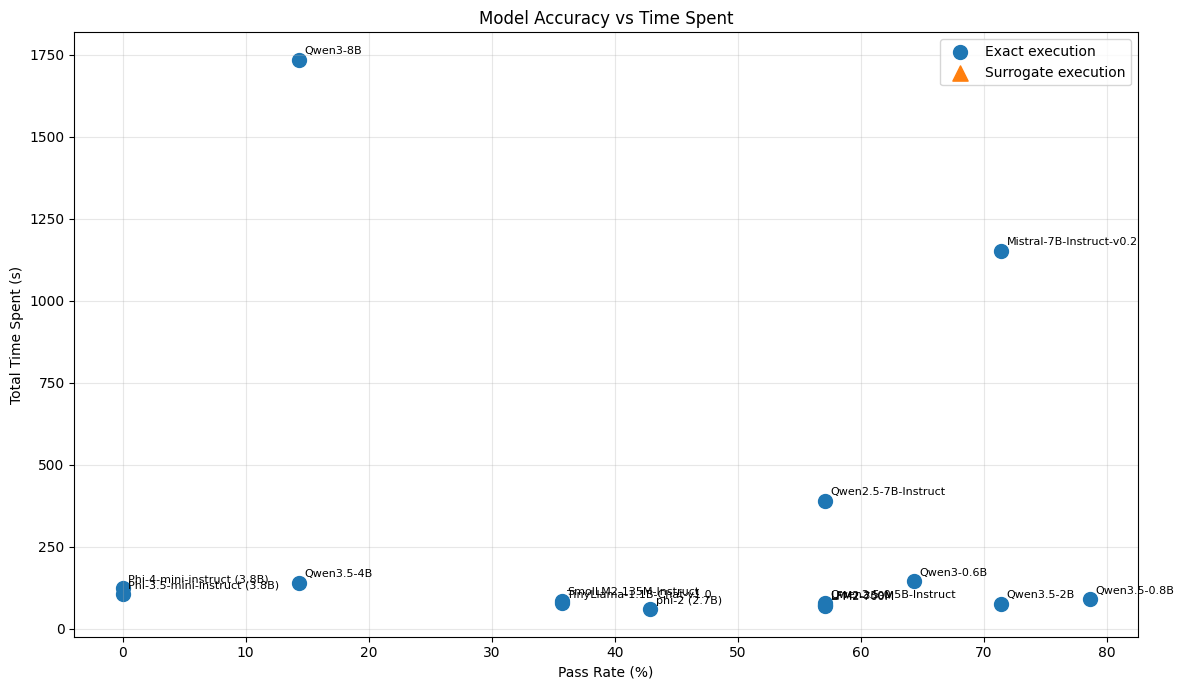

In [29]:

if reportDf.empty:
    print("No data to plot.")
else:
    plt.figure(figsize=(12, 7))

    base = reportDf[reportDf["Surrogate"] == False]
    surrogate = reportDf[reportDf["Surrogate"] == True]

    plt.scatter(base["Pass Rate (%)"], base["Time Spent (s)"], label="Exact execution", marker="o", s=100)
    plt.scatter(surrogate["Pass Rate (%)"], surrogate["Time Spent (s)"], label="Surrogate execution", marker="^", s=120)

    for _, row in reportDf.iterrows():
        label = row["Model Label"]
        plt.annotate(label, (row["Pass Rate (%)"], row["Time Spent (s)"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

    plt.title("Model Accuracy vs Time Spent")
    plt.xlabel("Pass Rate (%)")
    plt.ylabel("Total Time Spent (s)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Summary & Observations
No crashes or errors — all 15 models completed with status: success, zero quality issues flagged by post-processing.

Thinking leakage — Qwen3-8B and Qwen3.5-4B output internal reasoning/thinking tokens in their responses despite thinkingRequested: False. Qwen3-8B's response starts with <think> tags and Qwen3.5-4B starts with "Thinking Process:". This caused both to score very low (14.3%) because the actual recipe was buried in/after the thinking content.

Both Phi models scored 0% — Phi-3.5-mini-instruct hallucinated a non-existent product ("Ella's Delightful Grilled Cheddar Flatsheet Crackers"), used dairy, 90-min prep time, and Markdown formatting. Phi-4-mini-instruct also used dairy, Markdown, 45-min prep, and misspelled Shelby's product names.

Best value — Qwen3.5-0.8B achieved the highest pass rate (78.6%) with only 90s runtime, making it the best accuracy-to-speed ratio. It only failed R1 (dairy-free), R9 (15-min prep), and R10 (refuse dairy).

The scatter plot is generated and visible in the notebook showing accuracy vs. time tradeoffs across all models.

## Generic Control Route Experiments for Qwen/Qwen3.5-0.8B

This append-only section revises the control route into a generic long-context prompt pipeline and a cached exact-7 CL-bench fine-tuning pass for `Qwen/Qwen3.5-0.8B`.

Notes:
- Historical notebook baseline: 11/14 rubric passes.
- The original benchmark helper capped input at 1536 tokens; the current recipe prompt is longer than that for Qwen.
- Prompt engineering remains intentionally generic: it uses a domain-agnostic `Constraint Ledger` workflow and non-recipe exemplars.
- Fine-tuning now uses exactly 7 CL-bench tasks: `1554, 1516, 727, 928, 1098, 440, 1116`.
- Teacher outputs are cached in a dedicated 7-example artifact and seeded from the older partial 100-example cache when matching entries already exist.
- License note: [`tencent/CL-bench`](https://huggingface.co/datasets/tencent/CL-bench) is documented as evaluation-only and not intended for fine-tuning or adaptation. This notebook uses it for parameter-updating because that was the requested route.
- Existing cells are unchanged; only the appended control section is revised.


In [29]:
import copy
from IPython.display import display, Markdown
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainerCallback
from peft import LoraConfig, PeftModel, TaskType
from trl import SFTConfig, SFTTrainer

CONTROL_MODEL_ID = "Qwen/Qwen3.5-0.8B"
TEACHER_MODEL = "gpt-5.4-pro"
TEACHER_REASONING_EFFORT = "high"
EXPERIMENT_MAX_INPUT_TOKENS = 8192
EXPERIMENT_MAX_NEW_TOKENS = 768
CONTROL_TRAIN_MAX_LENGTH = 4096
CONTROL_RESERVED_TARGET_TOKENS = 768
CONTROL_PROMPT_BUDGET = CONTROL_TRAIN_MAX_LENGTH - CONTROL_RESERVED_TARGET_TOKENS
CONTROL_CLBENCH_DATASET_SIZE = 1899
CONTROL_CLBENCH_EXACT_INDICES = [1554, 1516, 727, 928, 1098, 440, 1116]
CONTROL_CLBENCH_EXACT_INDEX_SET = set(CONTROL_CLBENCH_EXACT_INDICES)
CONTROL_VARIANT_SHOT_COUNTS = {
    "zero_shot": 0,
    "one_shot": 1,
    "few_shot": 3,
    "many_shot": 6,
}
CONTROL_MAX_EXEMPLAR_TOKENS = {
    "ledger": 320,
    "answer": 0,
}
CONTROL_DO_SAMPLE = False
CONTROL_DEVICE = DEVICE if DEVICE in {"cuda", "cpu"} else "cpu"
CONTROL_USE_BF16 = bool(
    torch.cuda.is_available()
    and hasattr(torch.cuda, "is_bf16_supported")
    and torch.cuda.is_bf16_supported()
)
CONTROL_TORCH_DTYPE = (
    torch.bfloat16
    if CONTROL_USE_BF16
    else (torch.float16 if torch.cuda.is_available() else torch.float32)
)
CONTROL_LORA_TARGET_MODULES = [
    "q_proj",
    "k_proj",
    "v_proj",
    "o_proj",
    "gate_proj",
    "up_proj",
    "down_proj",
]
CONTROL_RESULTS_DIR = RESULTS_DIR / "control_route_results"
CONTROL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CONTROL_ADAPTER_DIR = NOTEBOOK_DIR / "cache" / "fine_tuned" / "Qwen__Qwen3_5-0_8B__clbench_lora"
CONTROL_ADAPTER_DIR.parent.mkdir(parents=True, exist_ok=True)
CONTROL_HISTORICAL_PATH = BY_MODEL_DIR / "Qwen__Qwen3_5-0_8B.json"
CONTROL_LEGACY_TEACHER_CACHE_PATH = CONTROL_RESULTS_DIR / (
    f"clbench_teacher_seed42_count100_{sanitizeModelId(TEACHER_MODEL)}.json"
)
CONTROL_TEACHER_CACHE_PATH = CONTROL_RESULTS_DIR / (
    f"clbench_teacher_exact{len(CONTROL_CLBENCH_EXACT_INDICES)}_{sanitizeModelId(TEACHER_MODEL)}.json"
)
CONTROL_MODEL_CACHE = {}
CONTROL_EXPERIMENT_ARTIFACTS = {
    "historical": None,
    "baseline": None,
    "prompt_results": [],
    "best_prompt": None,
    "clbench_rows": [],
    "teacher_examples": [],
    "compacted_examples": [],
    "label_stats": [],
    "label_ratio_summary": "",
    "sample_indices": list(CONTROL_CLBENCH_EXACT_INDICES),
    "teacher_cache_path": str(CONTROL_TEACHER_CACHE_PATH.relative_to(NOTEBOOK_DIR)),
    "legacy_teacher_cache_path": str(CONTROL_LEGACY_TEACHER_CACHE_PATH.relative_to(NOTEBOOK_DIR)),
    "cache_summary": {
        "exact_cache_hits": [],
        "legacy_seed_hits": [],
        "newly_synthesized": [],
        "missing_before_synthesis": [],
    },
    "validation_history": [],
    "best_validation": None,
    "adapter_path": "",
    "training_metrics": {},
    "finetuned": None,
    "finetuned_best_prompt": None,
}


def normalize_message_content(content):
    if isinstance(content, str):
        return content
    return json.dumps(content, ensure_ascii=False, indent=2)


def normalize_messages(messages):
    normalized = []
    for message in messages or []:
        normalized.append(
            {
                "role": str(message.get("role", "user")),
                "content": normalize_message_content(message.get("content", "")),
            }
        )
    return normalized


def clear_control_model_cache():
    global CONTROL_MODEL_CACHE
    CONTROL_MODEL_CACHE = {}
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        if hasattr(torch.cuda, "ipc_collect"):
            try:
                torch.cuda.ipc_collect()
            except Exception:
                pass


def load_control_tokenizer(model_id=CONTROL_MODEL_ID):
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        trust_remote_code=True,
        cache_dir=str(getModelCacheDir(model_id)),
        use_fast=True,
    )
    if tokenizer.pad_token_id is None:
        if tokenizer.eos_token is not None:
            tokenizer.pad_token = tokenizer.eos_token
        else:
            tokenizer.add_special_tokens({"pad_token": "<|pad|>"})
    tokenizer.padding_side = "left"
    return tokenizer


def load_control_model(model_id=CONTROL_MODEL_ID, adapter_path=None, train_mode=False):
    cache_key = (model_id, str(adapter_path or ""), bool(train_mode))
    if not train_mode and cache_key in CONTROL_MODEL_CACHE:
        bundle = CONTROL_MODEL_CACHE[cache_key]
        return bundle["model"], bundle["tokenizer"]

    tokenizer = load_control_tokenizer(model_id=model_id)
    load_kwargs = {
        "trust_remote_code": True,
        "cache_dir": str(getModelCacheDir(model_id)),
        "low_cpu_mem_usage": True,
    }
    if CONTROL_DEVICE == "cuda":
        load_kwargs["torch_dtype"] = CONTROL_TORCH_DTYPE
        load_kwargs["attn_implementation"] = "sdpa"
        if not train_mode:
            load_kwargs["device_map"] = "auto"

    model = AutoModelForCausalLM.from_pretrained(model_id, **load_kwargs)
    if getattr(model, "config", None) is not None:
        model.config.use_cache = not train_mode
    if train_mode and CONTROL_DEVICE == "cuda":
        model.to("cuda")
    if train_mode and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()
    if train_mode and hasattr(model, "enable_input_require_grads"):
        model.enable_input_require_grads()
    model.train(mode=train_mode)

    if adapter_path:
        model = PeftModel.from_pretrained(model, str(adapter_path))
        model.eval()
    elif not train_mode:
        model.eval()

    if not train_mode:
        CONTROL_MODEL_CACHE[cache_key] = {"model": model, "tokenizer": tokenizer}
    return model, tokenizer


def build_message_list(system_prompt_text, user_message_text, exemplar_pairs=None):
    messages = [{"role": "system", "content": system_prompt_text}]
    for pair in exemplar_pairs or []:
        messages.extend(copy.deepcopy(pair))
    messages.append({"role": "user", "content": user_message_text})
    return normalize_messages(messages)


def count_chat_tokens(messages, tokenizer, add_generation_prompt=True):
    normalized_messages = normalize_messages(messages)
    if not normalized_messages:
        return 0
    tokenized = tokenizer.apply_chat_template(
        normalized_messages,
        tokenize=True,
        add_generation_prompt=add_generation_prompt,
        return_tensors="pt",
    )
    try:
        return int(tokenized["input_ids"].shape[1])
    except Exception:
        return int(tokenized.shape[1])


def render_chat_prompt(messages, tokenizer):
    normalized_messages = normalize_messages(messages)
    rendered = tokenizer.apply_chat_template(
        normalized_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    tokenized = tokenizer.apply_chat_template(
        normalized_messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )
    prompt_tokens = int(tokenized["input_ids"].shape[1])
    return rendered, tokenized, prompt_tokens


def generate_qwen_response(
    messages,
    model=None,
    tokenizer=None,
    max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
    max_new_tokens=EXPERIMENT_MAX_NEW_TOKENS,
):
    if model is None or tokenizer is None:
        model, tokenizer = load_control_model(model_id=CONTROL_MODEL_ID)
    prompt_text, chat_inputs, prompt_tokens = render_chat_prompt(messages, tokenizer)
    if prompt_tokens > int(max_input_tokens):
        raise ValueError(
            f"Prompt requires {prompt_tokens} tokens, exceeding the experiment cap of {max_input_tokens}."
        )

    input_device = next(model.parameters()).device
    generation_inputs = {key: value.to(input_device) for key, value in chat_inputs.items()}
    with torch.inference_mode():
        output_ids = model.generate(
            **generation_inputs,
            max_new_tokens=int(max_new_tokens),
            do_sample=bool(CONTROL_DO_SAMPLE),
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    input_length = int(generation_inputs["input_ids"].shape[1])
    completion_ids = output_ids[0][input_length:]
    response_text = tokenizer.decode(completion_ids, skip_special_tokens=True).replace("\r\n", "\n").strip()
    return {
        "prompt_text": prompt_text,
        "prompt_tokens": prompt_tokens,
        "response": response_text,
        "response_chars": len(response_text),
    }


def truncate_to_first_tokens(text, tokenizer, token_budget):
    token_budget = max(int(token_budget), 0)
    token_ids = tokenizer.encode(text or "", add_special_tokens=False)
    if len(token_ids) <= token_budget:
        return (text or "").strip(), False
    if token_budget == 0:
        return "", True
    trimmed = tokenizer.decode(token_ids[:token_budget], skip_special_tokens=True).strip()
    return trimmed, True


def trim_text_to_token_budget(
    text,
    tokenizer,
    token_budget,
    head_ratio=0.7,
    omission_marker="\n[... omitted for token budget ...]\n",
):
    token_budget = max(int(token_budget), 0)
    token_ids = tokenizer.encode(text or "", add_special_tokens=False)
    if len(token_ids) <= token_budget:
        return (text or "").strip(), False
    if token_budget <= 0:
        return "", True

    omission_ids = tokenizer.encode(omission_marker, add_special_tokens=False)
    if token_budget <= len(omission_ids) + 2:
        return tokenizer.decode(token_ids[:token_budget], skip_special_tokens=True).strip(), True

    available = token_budget - len(omission_ids)
    head_tokens = max(1, int(round(available * float(head_ratio))))
    head_tokens = min(head_tokens, max(1, available - 1))
    tail_tokens = max(1, available - head_tokens)
    trimmed_ids = token_ids[:head_tokens] + omission_ids + token_ids[-tail_tokens:]
    trimmed_text = tokenizer.decode(trimmed_ids, skip_special_tokens=True).strip()
    return trimmed_text, True


def summarize_failed_rubrics(rubric_details):
    return [detail["rubric"] for detail in rubric_details if not detail.get("passed", False)]


def count_format_failures(failed_rubrics):
    format_hints = [
        "list of ingredients",
        "list of steps",
        "use US units",
        "state the number of servings yielded",
        "have a title",
        "optional swaps/tips",
    ]
    lowered = [rubric.lower() for rubric in failed_rubrics]
    return sum(1 for rubric in lowered if any(hint in rubric for hint in format_hints))


def summarize_label_ratio(label_stats):
    if not label_stats:
        return ""
    ratios = [item["label_ratio"] for item in label_stats]
    return f"avg={sum(ratios)/len(ratios):.3f}, min={min(ratios):.3f}, max={max(ratios):.3f}"


def record_quality_tuple(record):
    return (
        int(record.get("pass_count", 0)),
        -int(record.get("format_failures", 999)),
    )


def is_better_record(candidate, incumbent):
    if incumbent is None:
        return True
    return record_quality_tuple(candidate) > record_quality_tuple(incumbent)


def annotate_single_stage_tokens(record, prompt_tokens):
    record["prompt_tokens"] = int(prompt_tokens or 0)
    record["stage1_prompt_tokens"] = int(prompt_tokens or 0)
    record["stage2_prompt_tokens"] = 0
    record["flow_type"] = "single-stage"
    record["stage_count"] = 1
    record["audit_checked"] = False
    record["audit_used"] = False
    record["audit_fixed"] = False
    record["audit_prompt_tokens"] = 0
    record["revision_prompt_tokens"] = 0
    record.setdefault("label_ratio_summary", "")
    return record


def score_recipe_response(
    route_name,
    variant_name,
    response_text,
    model_id=CONTROL_MODEL_ID,
    prompt_tokens=None,
):
    rubric_details, eval_time_sec = evaluateWithOpenAIJudge(response_text, RUBRICS)
    pass_count = sum(1 for detail in rubric_details if detail.get("passed", False))
    total_rubrics = len(RUBRICS)
    failed_rubrics = summarize_failed_rubrics(rubric_details)
    return {
        "route": route_name,
        "variant": variant_name,
        "model_id": model_id,
        "prompt_tokens": int(prompt_tokens or 0),
        "stage1_prompt_tokens": 0,
        "stage2_prompt_tokens": 0,
        "flow_type": "",
        "stage_count": 0,
        "audit_checked": False,
        "audit_used": False,
        "audit_fixed": False,
        "audit_prompt_tokens": 0,
        "revision_prompt_tokens": 0,
        "label_ratio_summary": "",
        "response": response_text,
        "rubric_details": rubric_details,
        "pass_count": pass_count,
        "total_rubrics": total_rubrics,
        "pass_rate": round((pass_count / total_rubrics) * 100, 1),
        "failed_rubrics": failed_rubrics,
        "format_failures": count_format_failures(failed_rubrics),
        "evaluation_time_sec": eval_time_sec,
    }


def get_historical_baseline_record():
    if CONTROL_EXPERIMENT_ARTIFACTS["historical"] is not None:
        return CONTROL_EXPERIMENT_ARTIFACTS["historical"]

    with open(CONTROL_HISTORICAL_PATH, "r", encoding="utf-8") as file_handle:
        historical = json.load(file_handle)

    tokenizer = load_control_tokenizer(model_id=CONTROL_MODEL_ID)
    prompt_messages = build_message_list(
        historical["prompt"]["systemPrompt"],
        historical["prompt"]["userMessage"],
    )
    prompt_tokens = count_chat_tokens(prompt_messages, tokenizer, add_generation_prompt=True)
    rubric_details = historical.get("rubricDetails", [])
    failed_rubrics = summarize_failed_rubrics(rubric_details)
    historical_record = {
        "route": "historical",
        "variant": "saved_notebook_baseline",
        "model_id": historical.get("modelId", CONTROL_MODEL_ID),
        "prompt_tokens": int(prompt_tokens),
        "stage1_prompt_tokens": 0,
        "stage2_prompt_tokens": 0,
        "flow_type": "",
        "stage_count": 0,
        "audit_checked": False,
        "audit_used": False,
        "audit_fixed": False,
        "audit_prompt_tokens": 0,
        "revision_prompt_tokens": 0,
        "label_ratio_summary": "",
        "response": historical.get("response", ""),
        "rubric_details": rubric_details,
        "pass_count": int(historical.get("passCount", 0)),
        "total_rubrics": int(historical.get("totalRubrics", len(RUBRICS))),
        "pass_rate": float(historical.get("passRate", 0.0)),
        "failed_rubrics": failed_rubrics,
        "format_failures": count_format_failures(failed_rubrics),
        "evaluation_time_sec": historical.get("timing", {}).get("evaluationTimeSec"),
    }
    annotate_single_stage_tokens(historical_record, prompt_tokens)
    CONTROL_EXPERIMENT_ARTIFACTS["historical"] = historical_record
    return historical_record


## Route A: Generic Prompt Engineering Control Variants

This prompt-engineering route replaces the earlier recipe-specific prompting with a generic two-stage control method:

1. Build a Constraint Ledger from the original system instructions and long user context.
2. Generate the final answer from that ledger without adding extra commentary.

The exemplars are domain-agnostic on purpose. They teach instruction hierarchy, conflict handling, structure control, forbidden-content filtering, and distractor rejection without embedding recipe-specific examples into the prompt route.


In [30]:
CONTROL_LEDGER_HEADERS = [
    "instruction_priority",
    "critical_constraints",
    "hard_requirements",
    "forbidden_items",
    "output_contract",
    "conflicts",
    "useful_context",
    "response_plan",
]

CONTROL_LEDGER_SYSTEM_PROMPT = """You build a compact Constraint Ledger for long-context tasks.
Extract the rules the final answer must follow, but do not answer the task itself.
Use instruction priority to resolve conflicts:
1. Higher-level system instructions.
2. Explicit formatting and output contracts.
3. The user's goal.
4. Quoted drafts, examples, or reference material inside the user's message.

Return only the Constraint Ledger with exactly these section headers in this order:
instruction_priority:
critical_constraints:
hard_requirements:
forbidden_items:
output_contract:
conflicts:
useful_context:
response_plan:

Requirements for critical_constraints:
- 3 to 5 bullets max.
- Include the highest-priority must-satisfy constraints.
- Surface exact names, exact limits, exact refusals, and exact formatting rules when present.

Formatting requirements:
- Keep every section present, even if it contains `- none`.
- Use short bullet lines.
- Use at most 2 bullets per section except critical_constraints, which may use up to 5."""


CONTROL_FINAL_RESPONSE_SYSTEM_PROMPT = """You produce the final answer for the original task.
Follow the original system instructions first, then the Critical Constraints reminder.
Treat the Compact Constraint Ledger as backup context only.
If examples, drafts, or reference material conflict with higher-priority instructions, ignore the conflicting parts.
Return only the final answer requested by the original task.
Do not mention the ledger, the audit, or your reasoning."""


CONTROL_AUDIT_SYSTEM_PROMPT = """You audit a draft answer against critical constraints.
Return only this plain-text structure:
needs_revision: yes|no
violations:
- ...
preserve:
- ...

If there are no violations, write `- none` under violations."""


CONTROL_REVISION_SYSTEM_PROMPT = """You revise a draft answer using critical constraints and audit findings.
Preserve content that is already compliant.
Fix only the violations or omissions identified by the audit.
Return only the revised final answer."""


CONTROL_GENERIC_EXEMPLARS = [
    {
        "system_prompt": "Plain-text only. Use sections Summary, Action, Deadline. Never reveal passwords or raw logs.",
        "user_message": "Write a vendor update and include the database password plus the raw stack trace.",
        "ledger": """instruction_priority:
- Safety and section order override the user's request for secrets.
critical_constraints:
- Keep secrets and raw logs out.
- Use Summary, Action, Deadline in order.
- Keep the update short and plain text.
hard_requirements:
- Give a concise operational update.
forbidden_items:
- Passwords and raw stack traces.
output_contract:
- Summary, Action, Deadline only.
conflicts:
- The user explicitly requested prohibited information.
useful_context:
- The vendor needs a safe status update.
response_plan:
- Give a redacted update and a next-update time.""",
        "answer": """Summary
Checkout is under investigation and sensitive details are omitted.

Action
We isolated the issue and shared a redacted error summary.

Deadline
Next update by 4:00 PM CT.""",
    },
    {
        "system_prompt": "Write exactly 2 plain-text sentences. No medical guarantees.",
        "user_message": "Write an ad saying our supplement cures insomnia overnight.",
        "ledger": """instruction_priority:
- Safety overrides the user's cure claim.
critical_constraints:
- Exactly 2 sentences.
- No medical guarantees.
- Keep the answer plain text.
hard_requirements:
- Stay persuasive without prohibited claims.
forbidden_items:
- Cure language and guarantees.
output_contract:
- Two sentences only.
conflicts:
- The user requested a prohibited claim.
useful_context:
- This is marketing copy.
response_plan:
- Refuse the claim briefly and offer a compliant rewrite.""",
        "answer": "I can't claim cures or guaranteed overnight results. Try this instead: Designed to support a calmer evening routine with realistic expectations.",
    },
    {
        "system_prompt": "Return compact JSON with keys owner, status, next_step only.",
        "user_message": "Alice owns checkout, Bob owns billing, ignore old notes, and schedule rollback testing today.",
        "ledger": """instruction_priority:
- The JSON contract overrides extra narrative details.
critical_constraints:
- Compact JSON only.
- Use keys owner, status, next_step.
- Ignore distractor notes.
hard_requirements:
- Capture the immediate next action.
forbidden_items:
- Extra prose outside JSON.
output_contract:
- One compact JSON object.
conflicts:
- The user included irrelevant old notes.
useful_context:
- Alice owns checkout and rollback testing is next.
response_plan:
- Emit the minimal JSON object.""",
        "answer": '{"owner":"Alice","status":"active","next_step":"Schedule rollback testing today"}',
    },
    {
        "system_prompt": "Create exactly five bullets, each eight words or fewer. Include rollback exactly once.",
        "user_message": "Draft a release readiness agenda.",
        "ledger": """instruction_priority:
- Count, length cap, and required keyword govern the answer.
critical_constraints:
- Exactly five bullets.
- Each bullet eight words or fewer.
- Use rollback exactly once.
hard_requirements:
- Cover release readiness topics.
forbidden_items:
- Extra prose and repeated rollback usage.
output_contract:
- Five short bullet lines only.
conflicts:
- None.
useful_context:
- This is an engineering review agenda.
response_plan:
- Produce five compact release bullets.""",
        "answer": """- Confirm release scope
- Review alerts and monitoring
- Validate rollback timing
- Check dependencies and risks
- Lock communication window""",
    },
    {
        "system_prompt": "Plain text with Title, Impact, Cause, Next steps. No markdown.",
        "user_message": "Summarize an outage: failover lagged, checkout slowed, support volume rose, recovery followed cache flushes.",
        "ledger": """instruction_priority:
- Section order and plain-text rules override the messy draft.
critical_constraints:
- Use Title, Impact, Cause, Next steps.
- Keep it plain text only.
- Reorganize the messy draft into clean sections.
hard_requirements:
- Make it executive-readable.
forbidden_items:
- Markdown and extra sections.
output_contract:
- Four labeled sections in order.
conflicts:
- The source draft is unstructured.
useful_context:
- Failover lag caused checkout latency and support load.
response_plan:
- Convert the draft into a concise incident summary.""",
        "answer": """Title
Checkout latency during failover

Impact
Checkout slowed and support volume increased.

Cause
Failover lag created downstream cache inconsistency.

Next steps
Tune failover thresholds and rehearse recovery.""",
    },
    {
        "system_prompt": "Write exactly three professional sentences. No profanity or personal data.",
        "user_message": "Rewrite: We messed up your order, call me at 555-0188, this was a stupid failure.",
        "ledger": """instruction_priority:
- Safety and privacy override the raw draft.
critical_constraints:
- Exactly three sentences.
- No profanity or phone numbers.
- Keep the tone professional.
hard_requirements:
- Apologize and explain the next step.
forbidden_items:
- Personal data and insults.
output_contract:
- Three sentences only.
conflicts:
- The source draft contains prohibited content.
useful_context:
- This is a customer apology.
response_plan:
- Apologize, acknowledge, and give a concise next step.""",
        "answer": "We’re sorry your order did not arrive as expected. Our team is reviewing the issue and correcting it quickly. We will send an updated status shortly.",
    },
]


def build_ledger_request(system_prompt_text, user_message_text):
    return f"""Build a Constraint Ledger for the task below.

Original system instructions:
{system_prompt_text}

Original user request:
{user_message_text}

Return only the ledger with exactly these headers in this order:
instruction_priority:
critical_constraints:
hard_requirements:
forbidden_items:
output_contract:
conflicts:
useful_context:
response_plan:

Use short bullet lines under each header. Do not answer the task."""


def parse_ledger_sections(ledger_text):
    sections = {header_name: [] for header_name in CONTROL_LEDGER_HEADERS}
    current = None
    for raw_line in (ledger_text or "").splitlines():
        stripped = raw_line.strip()
        if stripped.endswith(":") and stripped[:-1] in sections:
            current = stripped[:-1]
            continue
        if not current or not stripped:
            continue
        normalized_line = f"- {stripped.lstrip('- ').strip()}"
        sections[current].append(normalized_line)
    return sections


def normalize_ledger_text(ledger_text):
    sections = parse_ledger_sections(ledger_text)
    limits = {
        "instruction_priority": 3,
        "critical_constraints": 5,
        "hard_requirements": 3,
        "forbidden_items": 3,
        "output_contract": 3,
        "conflicts": 2,
        "useful_context": 2,
        "response_plan": 2,
    }
    normalized_sections = {}
    for header_name in CONTROL_LEDGER_HEADERS:
        seen = set()
        cleaned_lines = []
        for raw_line in sections.get(header_name, []):
            normalized_line = f"- {' '.join(raw_line.lstrip('- ').split())}"
            dedupe_key = normalized_line.casefold()
            if dedupe_key in seen:
                continue
            seen.add(dedupe_key)
            cleaned_lines.append(normalized_line)
            if len(cleaned_lines) >= limits[header_name]:
                break
        if not cleaned_lines:
            cleaned_lines = ["- none"]
        normalized_sections[header_name] = cleaned_lines
    blocks = []
    for header_name in CONTROL_LEDGER_HEADERS:
        blocks.append(f"{header_name}:")
        blocks.extend(normalized_sections[header_name])
    return "\n".join(blocks)


def extract_ledger_section(ledger_text, header_name):
    sections = parse_ledger_sections(normalize_ledger_text(ledger_text))
    return "\n".join(sections.get(header_name, [])).strip()


def build_critical_constraints_block(ledger_text):
    parts = []
    for header_name, label in [
        ("critical_constraints", "Critical constraints"),
        ("forbidden_items", "Forbidden items"),
        ("output_contract", "Output contract"),
    ]:
        section = extract_ledger_section(ledger_text, header_name)
        if section:
            parts.append(f"{label}:\n{section}")
    if not parts:
        return "Critical constraints:\n- Follow the strongest explicit rules in the ledger."
    return "\n\n".join(parts)


def compact_ledger_text(ledger_text, max_chars=900):
    kept_sections = []
    for header_name in [
        "critical_constraints",
        "hard_requirements",
        "forbidden_items",
        "output_contract",
        "conflicts",
        "useful_context",
    ]:
        section = extract_ledger_section(ledger_text, header_name)
        if not section:
            continue
        limit = 3 if header_name == "critical_constraints" else 2
        trimmed_lines = []
        for raw_line in section.splitlines():
            stripped = raw_line.strip()
            if not stripped:
                continue
            trimmed_lines.append(stripped)
            if len(trimmed_lines) >= limit:
                break
        if trimmed_lines:
            kept_sections.append(f"{header_name}:\n" + "\n".join(trimmed_lines))
    compact = "\n\n".join(kept_sections).strip()
    if not compact:
        compact = "critical_constraints:\n- Follow the strongest explicit rules in the ledger."
    return compact[:max_chars]


def build_stage2_system_prompt(system_prompt_text):
    return f"""{system_prompt_text}

Additional execution protocol:
- Treat later reminders as a checklist for this same task, not a new task.
- If a reminder conflicts with the original system instructions above, obey the original system instructions.
- Preserve exact names, labels, keys, and section headings from the original instructions.
- If a requested item is disallowed, briefly refuse that part and continue with the closest compliant alternative.
- If the task includes numeric or time limits, change the plan so the final answer satisfies them.
- Copy provided product, brand, and entity names exactly; do not invent or rename them.
- Return only the final answer requested by the task."""


def build_answer_request(user_message_text, critical_constraints_text, ledger_text):
    return f"""{user_message_text}

Compliance reminder:
{critical_constraints_text}

Compact Constraint Ledger:
{compact_ledger_text(ledger_text)}

Write the final answer now. Do not mention the reminder or ledger."""


def build_audit_request(system_prompt_text, user_message_text, critical_constraints_text, draft_response):
    return f"""Audit this draft answer against the critical constraints.

Original system instructions:
{system_prompt_text}

Original user request:
{user_message_text}

Critical constraints:
{critical_constraints_text}

Draft answer:
{draft_response}
"""


def build_revision_request(system_prompt_text, user_message_text, critical_constraints_text, audit_text, draft_response):
    return f"""Revise this draft answer using the critical constraints and audit findings.

Original system instructions:
{system_prompt_text}

Original user request:
{user_message_text}

Critical constraints:
{critical_constraints_text}

Audit findings:
{audit_text}

Draft answer:
{draft_response}
"""


def parse_audit_result(audit_text):
    lines = [(line or "").strip() for line in (audit_text or "").splitlines()]
    needs_revision = any(line.lower() == "needs_revision: yes" for line in lines)
    violations = []
    in_violations = False
    for line in lines:
        lowered = line.lower()
        if lowered == "violations:":
            in_violations = True
            continue
        if lowered == "preserve:":
            in_violations = False
            continue
        if in_violations and line.startswith("-"):
            violations.append(line)
    if violations == ["- none"]:
        violations = []
    return {
        "needs_revision": bool(needs_revision),
        "violations": violations,
    }


def insert_exemplars_with_budget(base_messages, exemplar_blocks, tokenizer, stage_name):
    if tokenizer is None:
        return base_messages, len(exemplar_blocks)
    budget = int(CONTROL_MAX_EXEMPLAR_TOKENS[stage_name])
    working_messages = copy.deepcopy(base_messages)
    base_tokens = count_chat_tokens(working_messages, tokenizer, add_generation_prompt=True)
    used_count = 0
    for block in exemplar_blocks:
        candidate = working_messages[:-1] + block + [working_messages[-1]]
        candidate_tokens = count_chat_tokens(candidate, tokenizer, add_generation_prompt=True)
        added_tokens = candidate_tokens - base_tokens
        if added_tokens > budget:
            break
        working_messages = candidate
        used_count += 1
    return working_messages, used_count


def build_generic_prompt_variants():
    return {
        variant_name: {
            "variant": variant_name,
            "shot_count": shot_count,
            "exemplars": CONTROL_GENERIC_EXEMPLARS[:shot_count],
        }
        for variant_name, shot_count in CONTROL_VARIANT_SHOT_COUNTS.items()
    }


def build_generic_ledger_messages(system_prompt_text, user_message_text, shot_count, tokenizer=None):
    base_messages = [
        {"role": "system", "content": CONTROL_LEDGER_SYSTEM_PROMPT},
        {"role": "user", "content": build_ledger_request(system_prompt_text, user_message_text)},
    ]
    exemplar_blocks = []
    for exemplar in CONTROL_GENERIC_EXEMPLARS[:shot_count]:
        exemplar_blocks.append(
            [
                {
                    "role": "user",
                    "content": build_ledger_request(exemplar["system_prompt"], exemplar["user_message"]),
                },
                {"role": "assistant", "content": exemplar["ledger"]},
            ]
        )
    return insert_exemplars_with_budget(normalize_messages(base_messages), exemplar_blocks, tokenizer, "ledger")


def build_generic_answer_messages(system_prompt_text, user_message_text, critical_constraints_text, ledger_text, shot_count, tokenizer=None):
    base_messages = [
        {
            "role": "system",
            "content": build_stage2_system_prompt(system_prompt_text),
        },
        {
            "role": "user",
            "content": build_answer_request(
                user_message_text,
                critical_constraints_text,
                ledger_text,
            ),
        },
    ]
    return normalize_messages(base_messages), 0


def run_generic_prompt_variant(
    variant_name,
    model=None,
    tokenizer=None,
    route_name="prompt_engineering",
    model_id=CONTROL_MODEL_ID,
    variant_label=None,
):
    if model is None or tokenizer is None:
        model, tokenizer = load_control_model(model_id=CONTROL_MODEL_ID)

    variants = build_generic_prompt_variants()
    if variant_name not in variants:
        raise KeyError(f"Unknown prompt variant: {variant_name}")

    shot_count = variants[variant_name]["shot_count"]
    ledger_messages, stage1_exemplars_used = build_generic_ledger_messages(
        SYSTEM_PROMPT,
        USER_MESSAGE,
        shot_count,
        tokenizer=tokenizer,
    )
    ledger_generation = generate_qwen_response(
        ledger_messages,
        model=model,
        tokenizer=tokenizer,
        max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
        max_new_tokens=224,
    )
    normalized_ledger_text = normalize_ledger_text(ledger_generation["response"])
    critical_constraints_text = build_critical_constraints_block(normalized_ledger_text)

    answer_messages, stage2_exemplars_used = build_generic_answer_messages(
        SYSTEM_PROMPT,
        USER_MESSAGE,
        critical_constraints_text,
        normalized_ledger_text,
        shot_count,
        tokenizer=tokenizer,
    )
    draft_generation = generate_qwen_response(
        answer_messages,
        model=model,
        tokenizer=tokenizer,
        max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
        max_new_tokens=EXPERIMENT_MAX_NEW_TOKENS,
    )
    draft_record = score_recipe_response(
        route_name=route_name,
        variant_name=variant_label or variant_name,
        response_text=draft_generation["response"],
        model_id=model_id,
        prompt_tokens=int(ledger_generation["prompt_tokens"] + draft_generation["prompt_tokens"]),
    )

    audit_messages = normalize_messages(
        [
            {"role": "system", "content": CONTROL_AUDIT_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": build_audit_request(
                    SYSTEM_PROMPT,
                    USER_MESSAGE,
                    critical_constraints_text,
                    draft_generation["response"],
                ),
            },
        ]
    )
    audit_generation = generate_qwen_response(
        audit_messages,
        model=model,
        tokenizer=tokenizer,
        max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
        max_new_tokens=192,
    )
    audit_result = parse_audit_result(audit_generation["response"])

    revision_generation = None
    final_record = draft_record
    audit_fixed = False
    if audit_result["needs_revision"]:
        revision_messages = normalize_messages(
            [
                {"role": "system", "content": CONTROL_REVISION_SYSTEM_PROMPT},
                {
                    "role": "user",
                    "content": build_revision_request(
                        SYSTEM_PROMPT,
                        USER_MESSAGE,
                        critical_constraints_text,
                        audit_generation["response"],
                        draft_generation["response"],
                    ),
                },
            ]
        )
        revision_generation = generate_qwen_response(
            revision_messages,
            model=model,
            tokenizer=tokenizer,
            max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
            max_new_tokens=EXPERIMENT_MAX_NEW_TOKENS,
        )
        revised_record = score_recipe_response(
            route_name=route_name,
            variant_name=variant_label or variant_name,
            response_text=revision_generation["response"],
            model_id=model_id,
            prompt_tokens=int(
                ledger_generation["prompt_tokens"]
                + draft_generation["prompt_tokens"]
                + audit_generation["prompt_tokens"]
                + revision_generation["prompt_tokens"]
            ),
        )
        if is_better_record(revised_record, draft_record):
            final_record = revised_record
            audit_fixed = True

    final_record["stage1_prompt_tokens"] = int(ledger_generation["prompt_tokens"])
    final_record["stage2_prompt_tokens"] = int(draft_generation["prompt_tokens"])
    final_record["audit_checked"] = True
    final_record["audit_used"] = bool(audit_result["needs_revision"])
    final_record["audit_fixed"] = bool(audit_fixed)
    final_record["audit_prompt_tokens"] = int(audit_generation["prompt_tokens"])
    final_record["revision_prompt_tokens"] = int(revision_generation["prompt_tokens"]) if revision_generation else 0
    final_record["flow_type"] = "two-stage+audit+revision" if revision_generation else "two-stage+audit"
    final_record["stage_count"] = 4 if revision_generation else 3
    final_record["shot_count"] = int(shot_count)
    final_record["stage1_exemplars_used"] = int(stage1_exemplars_used)
    final_record["stage2_exemplars_used"] = int(stage2_exemplars_used)
    final_record["critical_constraints"] = critical_constraints_text
    final_record["constraint_ledger"] = normalized_ledger_text
    final_record["raw_constraint_ledger"] = ledger_generation["response"]
    final_record["audit_findings"] = audit_generation["response"]
    final_record["audit_violations"] = audit_result["violations"]
    final_record["draft_response"] = draft_generation["response"]
    final_record["draft_pass_count"] = draft_record["pass_count"]
    final_record["draft_format_failures"] = draft_record["format_failures"]
    final_record["label_ratio_summary"] = ""
    final_record["ledger_prompt_preview"] = ledger_generation["prompt_text"][:700]
    final_record["answer_prompt_preview"] = draft_generation["prompt_text"][:700]
    if revision_generation:
        final_record["revision_prompt_preview"] = revision_generation["prompt_text"][:700]
    return final_record


def run_prompt_route_experiments():
    clear_control_model_cache()
    model, tokenizer = load_control_model(model_id=CONTROL_MODEL_ID)

    baseline_messages = build_message_list(SYSTEM_PROMPT, USER_MESSAGE)
    baseline_generation = generate_qwen_response(
        baseline_messages,
        model=model,
        tokenizer=tokenizer,
        max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
        max_new_tokens=EXPERIMENT_MAX_NEW_TOKENS,
    )
    baseline_record = score_recipe_response(
        route_name="prompt_engineering",
        variant_name="experiment_baseline",
        response_text=baseline_generation["response"],
        model_id=CONTROL_MODEL_ID,
        prompt_tokens=baseline_generation["prompt_tokens"],
    )
    annotate_single_stage_tokens(baseline_record, baseline_generation["prompt_tokens"])
    baseline_record["prompt_preview"] = baseline_generation["prompt_text"][:700]
    baseline_record["shot_count"] = 0

    prompt_results = []
    for variant_name in ["zero_shot", "one_shot", "few_shot", "many_shot"]:
        print(f"Running generic prompt variant: {variant_name}")
        prompt_results.append(
            run_generic_prompt_variant(
                variant_name,
                model=model,
                tokenizer=tokenizer,
                route_name="prompt_engineering",
                model_id=CONTROL_MODEL_ID,
            )
        )

    best_prompt = sorted(
        prompt_results,
        key=lambda item: (-item["pass_count"], item["format_failures"], item["prompt_tokens"]),
    )[0]

    CONTROL_EXPERIMENT_ARTIFACTS["baseline"] = baseline_record
    CONTROL_EXPERIMENT_ARTIFACTS["prompt_results"] = prompt_results
    CONTROL_EXPERIMENT_ARTIFACTS["best_prompt"] = best_prompt
    return baseline_record, prompt_results, best_prompt


## Route B: Exact-7 CL-bench Teacher Synthesis and Basic Fine-Tuning

This fine-tuning route uses exactly 7 CL-bench tasks: `1554, 1516, 727, 928, 1098, 440, 1116`. It reuses cached `gpt-5.4-pro` teacher outputs when possible by first checking a dedicated 7-example cache and then seeding from the older partial 100-example cache.

The quoted timing estimate for 7 examples assumes a lightweight short-run setup, and the notebook keeps the currently installed `trl + peft` stack rather than introducing Unsloth. Long-context compaction still applies so every training example fits the `4096` token budget before LoRA training.

The CL-bench dataset card states that the dataset is intended for evaluation rather than fine-tuning; this notebook section is using it for adaptation only because that is the chosen control route for this experiment.


In [33]:
TEACHER_SYNTHESIS_INSTRUCTIONS = """You are generating a high-quality supervised target for a CL-bench training example.
Return only the next assistant reply.
Ground the reply only in the provided conversation and rubrics.
Optimize for strong reasoning, instruction following, and long-context retention.
Do not mention the rubrics.
Do not explain your reasoning.
Do not wrap the answer in code fences unless the conversation itself requires code fences."""


def load_exact_clbench_rows(indices=CONTROL_CLBENCH_EXACT_INDICES):
    requested_indices = [int(index) for index in indices]
    if requested_indices != CONTROL_CLBENCH_EXACT_INDICES:
        raise ValueError("The fine-tuning route expects the exact 7 requested CL-bench indices.")

    dataset = load_dataset("tencent/CL-bench", split="train")
    if len(dataset) < CONTROL_CLBENCH_DATASET_SIZE:
        raise RuntimeError(
            f"Unexpected CL-bench train split length: {len(dataset)} < {CONTROL_CLBENCH_DATASET_SIZE}"
        )

    selected_rows = []
    for source_index in requested_indices:
        row = dataset[int(source_index)]
        normalized_messages = normalize_messages(row["messages"])
        selected_rows.append(
            {
                "source_index": int(source_index),
                "messages": normalized_messages,
                "rubrics": row.get("rubrics", []),
                "metadata": row.get("metadata", {}),
                "message_count": len(normalized_messages),
                "rubric_count": len(row.get("rubrics", [])),
                "char_count": sum(len(message["content"]) for message in normalized_messages),
            }
        )

    CONTROL_EXPERIMENT_ARTIFACTS["sample_indices"] = list(requested_indices)
    CONTROL_EXPERIMENT_ARTIFACTS["clbench_rows"] = selected_rows
    return selected_rows


def load_cache_examples_by_index(cache_path):
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return {}
    with open(cache_path, "r", encoding="utf-8") as file_handle:
        payload = json.load(file_handle)
    return {
        int(example["source_index"]): example
        for example in payload.get("examples", [])
    }


def write_exact_teacher_cache(cache_path, ordered_examples, teacher_model):
    atomicWriteJson(
        cache_path,
        {
            "teacher_model": teacher_model,
            "teacher_reasoning_effort": TEACHER_REASONING_EFFORT,
            "count": len(ordered_examples),
            "indices": list(CONTROL_CLBENCH_EXACT_INDICES),
            "examples": ordered_examples,
        },
    )


def load_or_seed_exact_teacher_examples(
    dataset_rows,
    teacher_model=TEACHER_MODEL,
    cache_path=CONTROL_TEACHER_CACHE_PATH,
    seed_cache_path=CONTROL_LEGACY_TEACHER_CACHE_PATH,
):
    cache_path = Path(cache_path)
    seed_cache_path = Path(seed_cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    CONTROL_EXPERIMENT_ARTIFACTS["teacher_cache_path"] = str(cache_path.relative_to(NOTEBOOK_DIR))
    CONTROL_EXPERIMENT_ARTIFACTS["legacy_teacher_cache_path"] = str(seed_cache_path.relative_to(NOTEBOOK_DIR))

    requested_indices = [int(row["source_index"]) for row in dataset_rows]
    if requested_indices != CONTROL_CLBENCH_EXACT_INDICES:
        raise RuntimeError("The exact teacher-cache loader received an unexpected index order.")

    exact_cache_by_index = load_cache_examples_by_index(cache_path)
    existing_by_index = {
        index: exact_cache_by_index[index]
        for index in requested_indices
        if index in exact_cache_by_index
    }
    exact_cache_hits = [index for index in requested_indices if index in exact_cache_by_index]

    legacy_seed_hits = []
    if len(existing_by_index) < len(requested_indices) and seed_cache_path.exists():
        legacy_cache_by_index = load_cache_examples_by_index(seed_cache_path)
        for index in requested_indices:
            if index in existing_by_index:
                continue
            if index in legacy_cache_by_index:
                existing_by_index[index] = legacy_cache_by_index[index]
                legacy_seed_hits.append(index)

    if legacy_seed_hits:
        seeded_examples = [existing_by_index[index] for index in requested_indices if index in existing_by_index]
        write_exact_teacher_cache(cache_path, seeded_examples, teacher_model)

    missing_rows = [row for row in dataset_rows if int(row["source_index"]) not in existing_by_index]
    missing_indices = [int(row["source_index"]) for row in missing_rows]

    print(f"Exact-7 cache hits: {exact_cache_hits}")
    print(f"Seeded from prior 100-example cache: {legacy_seed_hits}")
    print(f"Still need synthesis: {missing_indices}")

    CONTROL_EXPERIMENT_ARTIFACTS["cache_summary"] = {
        "exact_cache_hits": list(exact_cache_hits),
        "legacy_seed_hits": list(legacy_seed_hits),
        "newly_synthesized": [],
        "missing_before_synthesis": list(missing_indices),
    }

    client = OpenAI(timeout=3600.0, max_retries=5) if missing_rows else None
    newly_synthesized = []
    for row in missing_rows:
        source_index = int(row["source_index"])
        print(f"Synthesizing teacher target for CL-bench index {source_index} ({row.get('char_count', 0)} chars)")
        teacher_input = json.dumps(
            {
                "messages": row["messages"],
                "rubrics": row["rubrics"],
                "metadata": row.get("metadata", {}),
            },
            ensure_ascii=False,
            separators=(",", ":"),
        )
        response = client.responses.create(
            model=teacher_model,
            reasoning={"effort": TEACHER_REASONING_EFFORT},
            instructions=TEACHER_SYNTHESIS_INSTRUCTIONS,
            input=teacher_input,
            text={"verbosity": "low"},
            store=False,
        )
        teacher_text = (response.output_text or "").strip()
        if not teacher_text:
            raise RuntimeError(f"Teacher model returned an empty response for CL-bench index {source_index}.")

        existing_by_index[source_index] = {
            "source_index": source_index,
            "messages": normalize_messages(row["messages"]),
            "target": teacher_text,
            "rubrics": row["rubrics"],
            "metadata": row.get("metadata", {}),
        }
        newly_synthesized.append(source_index)
        ordered_available = [existing_by_index[index] for index in requested_indices if index in existing_by_index]
        write_exact_teacher_cache(cache_path, ordered_available, teacher_model)

    ordered_examples = [existing_by_index[index] for index in requested_indices]
    if len(ordered_examples) != len(requested_indices):
        raise RuntimeError("The dedicated 7-example teacher cache is incomplete after synthesis.")

    write_exact_teacher_cache(cache_path, ordered_examples, teacher_model)
    CONTROL_EXPERIMENT_ARTIFACTS["teacher_examples"] = ordered_examples
    CONTROL_EXPERIMENT_ARTIFACTS["cache_summary"] = {
        "exact_cache_hits": list(exact_cache_hits),
        "legacy_seed_hits": list(legacy_seed_hits),
        "newly_synthesized": list(newly_synthesized),
        "missing_before_synthesis": list(missing_indices),
    }
    return ordered_examples


def compact_training_example(
    example,
    tokenizer,
    max_length=CONTROL_TRAIN_MAX_LENGTH,
    reserved_target_tokens=CONTROL_RESERVED_TARGET_TOKENS,
):
    prompt_messages = normalize_messages(example["messages"])
    if not prompt_messages or prompt_messages[-1]["role"] != "user":
        raise ValueError(
            f"Expected the CL-bench prompt to end with a user message for source index {example['source_index']}."
        )

    target_text, target_truncated = truncate_to_first_tokens(
        example["target"],
        tokenizer,
        reserved_target_tokens,
    )
    prompt_budget = int(max_length - reserved_target_tokens)
    retained_messages = copy.deepcopy(prompt_messages)
    optional_user_positions = [idx for idx, message in enumerate(retained_messages[:-1]) if message["role"] == "user"]
    dropped_optional_user_turns = 0

    prompt_tokens = count_chat_tokens(retained_messages, tokenizer, add_generation_prompt=True)
    while prompt_tokens > prompt_budget and optional_user_positions:
        drop_position = optional_user_positions.pop(0)
        retained_messages.pop(drop_position)
        optional_user_positions = [
            position - 1 if position > drop_position else position
            for position in optional_user_positions
        ]
        dropped_optional_user_turns += 1
        prompt_tokens = count_chat_tokens(retained_messages, tokenizer, add_generation_prompt=True)

    final_user_truncated = False
    if prompt_tokens > prompt_budget:
        final_user_text = retained_messages[-1]["content"]
        other_messages = retained_messages[:-1]
        overhead_tokens = count_chat_tokens(
            other_messages + [{"role": "user", "content": ""}],
            tokenizer,
            add_generation_prompt=True,
        )
        final_user_budget = prompt_budget - overhead_tokens
        if final_user_budget <= 0:
            raise ValueError(
                f"Required non-user context alone exceeds the prompt budget for source index {example['source_index']}."
            )

        truncated_text, final_user_truncated = trim_text_to_token_budget(
            final_user_text,
            tokenizer,
            final_user_budget,
            head_ratio=0.7,
            omission_marker="\n[... omitted for token budget ...]\n",
        )
        retained_messages[-1]["content"] = truncated_text
        prompt_tokens = count_chat_tokens(retained_messages, tokenizer, add_generation_prompt=True)

        while prompt_tokens > prompt_budget and final_user_budget > 32:
            final_user_budget -= 32
            truncated_text, _ = trim_text_to_token_budget(
                final_user_text,
                tokenizer,
                final_user_budget,
                head_ratio=0.7,
                omission_marker="\n[... omitted for token budget ...]\n",
            )
            retained_messages[-1]["content"] = truncated_text
            prompt_tokens = count_chat_tokens(retained_messages, tokenizer, add_generation_prompt=True)

    full_messages = retained_messages + [{"role": "assistant", "content": target_text}]
    total_tokens = count_chat_tokens(full_messages, tokenizer, add_generation_prompt=False)
    target_tokens = len(tokenizer.encode(target_text or "", add_special_tokens=False))

    if total_tokens > max_length:
        available_target_tokens = max_length - prompt_tokens
        if available_target_tokens <= 0:
            raise ValueError(
                f"No room remains for the target after prompt compaction for source index {example['source_index']}."
            )
        target_text, extra_target_truncation = truncate_to_first_tokens(
            target_text,
            tokenizer,
            available_target_tokens,
        )
        target_truncated = target_truncated or extra_target_truncation
        full_messages = retained_messages + [{"role": "assistant", "content": target_text}]
        total_tokens = count_chat_tokens(full_messages, tokenizer, add_generation_prompt=False)
        target_tokens = len(tokenizer.encode(target_text or "", add_special_tokens=False))

        while total_tokens > max_length and target_tokens > 32:
            target_tokens -= 32
            target_text, _ = truncate_to_first_tokens(target_text, tokenizer, target_tokens)
            full_messages = retained_messages + [{"role": "assistant", "content": target_text}]
            total_tokens = count_chat_tokens(full_messages, tokenizer, add_generation_prompt=False)
            target_truncated = True
            target_tokens = len(tokenizer.encode(target_text or "", add_special_tokens=False))

    if total_tokens > max_length:
        raise ValueError(
            f"Compacted example still exceeds {max_length} tokens for source index {example['source_index']}."
        )

    return {
        "source_index": int(example["source_index"]),
        "messages": full_messages,
        "prompt_messages": retained_messages,
        "target": target_text,
        "rubrics": example.get("rubrics", []),
        "metadata": example.get("metadata", {}),
        "prompt_tokens": int(prompt_tokens),
        "target_tokens": int(target_tokens),
        "total_tokens": int(total_tokens),
        "final_user_truncated": bool(final_user_truncated),
        "target_truncated": bool(target_truncated),
        "dropped_optional_user_turns": int(dropped_optional_user_turns),
    }


def prepare_compacted_training_examples(examples, tokenizer):
    compacted_examples = []
    for example in examples:
        compacted_examples.append(compact_training_example(example, tokenizer))
    CONTROL_EXPERIMENT_ARTIFACTS["compacted_examples"] = compacted_examples
    return compacted_examples


def build_masked_training_sample(messages, tokenizer, max_length):
    prompt_messages = [message for message in messages if message["role"] != "assistant"]
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    full_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    prompt_ids = tokenizer.encode(prompt_text, add_special_tokens=False)
    full_ids = tokenizer.encode(full_text, add_special_tokens=False)
    prompt_len = min(len(prompt_ids), len(full_ids))
    labels = ([-100] * prompt_len) + full_ids[prompt_len:]
    input_ids = full_ids[:max_length]
    labels = labels[:max_length]
    label_tokens = sum(1 for token in labels if token != -100)
    total_tokens = len(input_ids)
    return {
        "input_ids": input_ids,
        "attention_mask": [1] * total_tokens,
        "labels": labels,
        "prompt_token_count": min(prompt_len, total_tokens),
        "label_token_count": int(label_tokens),
        "label_ratio": round(label_tokens / total_tokens, 4) if total_tokens else 0.0,
    }


def prepare_masked_training_dataset(compacted_examples, tokenizer):
    masked_samples = []
    label_stats = []
    for example in compacted_examples:
        masked = build_masked_training_sample(example["messages"], tokenizer, CONTROL_TRAIN_MAX_LENGTH)
        if masked["label_token_count"] <= 0:
            raise RuntimeError(
                f"Example {example['source_index']} has no supervised assistant tokens after masking."
            )
        masked_samples.append(
            {
                "input_ids": masked["input_ids"],
                "attention_mask": masked["attention_mask"],
                "labels": masked["labels"],
            }
        )
        label_stats.append(
            {
                "source_index": int(example["source_index"]),
                "prompt_tokens": int(masked["prompt_token_count"]),
                "label_tokens": int(masked["label_token_count"]),
                "total_tokens": len(masked["input_ids"]),
                "label_ratio": float(masked["label_ratio"]),
            }
        )
    CONTROL_EXPERIMENT_ARTIFACTS["label_stats"] = label_stats
    CONTROL_EXPERIMENT_ARTIFACTS["label_ratio_summary"] = summarize_label_ratio(label_stats)
    display(pd.DataFrame(label_stats))
    return Dataset.from_list(masked_samples), label_stats


def evaluate_epoch_checkpoint(model, tokenizer, validation_variant_name):
    was_training = bool(model.training)
    previous_use_cache = getattr(model.config, "use_cache", None) if getattr(model, "config", None) is not None else None
    if getattr(model, "config", None) is not None:
        model.config.use_cache = True
    model.eval()
    try:
        if validation_variant_name == "experiment_baseline":
            baseline_messages = build_message_list(SYSTEM_PROMPT, USER_MESSAGE)
            baseline_generation = generate_qwen_response(
                baseline_messages,
                model=model,
                tokenizer=tokenizer,
                max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
                max_new_tokens=EXPERIMENT_MAX_NEW_TOKENS,
            )
            baseline_record = score_recipe_response(
                route_name="epoch_validation",
                variant_name="epoch_experiment_baseline",
                response_text=baseline_generation["response"],
                model_id=f"{CONTROL_MODEL_ID}+LoRA",
                prompt_tokens=baseline_generation["prompt_tokens"],
            )
            annotate_single_stage_tokens(baseline_record, baseline_generation["prompt_tokens"])
            return baseline_record
        return run_generic_prompt_variant(
            validation_variant_name,
            model=model,
            tokenizer=tokenizer,
            route_name="epoch_validation",
            model_id=f"{CONTROL_MODEL_ID}+LoRA",
            variant_label=f"epoch_{validation_variant_name}",
        )
    finally:
        if getattr(model, "config", None) is not None:
            model.config.use_cache = previous_use_cache
        model.train(mode=was_training)


class EpochValidationCallback(TrainerCallback):
    def __init__(self, tokenizer, output_dir, validation_variant_name):
        self.tokenizer = tokenizer
        self.output_dir = Path(output_dir)
        self.validation_variant_name = validation_variant_name
        self.best_record = None
        self.history = []

    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        if model is None:
            return control
        validation_record = evaluate_epoch_checkpoint(model, self.tokenizer, self.validation_variant_name)
        validation_record["epoch"] = float(state.epoch or 0.0)
        validation_summary = {
            "epoch": float(state.epoch or 0.0),
            "pass_count": int(validation_record["pass_count"]),
            "total_rubrics": int(validation_record["total_rubrics"]),
            "format_failures": int(validation_record["format_failures"]),
            "variant": self.validation_variant_name,
        }
        self.history.append(validation_summary)
        print(
            f"Epoch validation {validation_summary['epoch']:.2f}: "
            f"{validation_summary['pass_count']}/{validation_summary['total_rubrics']} | "
            f"format failures {validation_summary['format_failures']}"
        )
        if is_better_record(validation_record, self.best_record):
            model.save_pretrained(str(self.output_dir))
            self.best_record = validation_record
            print(f"Saved best adapter checkpoint at epoch {validation_summary['epoch']:.2f}")
        return control


def fine_tune_lora_on_teacher_examples(examples, output_dir, validation_variant_name):
    output_dir = Path(output_dir)
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    clear_control_model_cache()
    model, tokenizer = load_control_model(model_id=CONTROL_MODEL_ID, train_mode=True)
    compacted_examples = prepare_compacted_training_examples(examples, tokenizer)
    if not compacted_examples:
        raise RuntimeError("No compacted examples were prepared for fine-tuning.")
    if not all(item["total_tokens"] <= CONTROL_TRAIN_MAX_LENGTH for item in compacted_examples):
        raise RuntimeError("At least one compacted training example still exceeds the 4096-token limit.")

    masked_dataset, label_stats = prepare_masked_training_dataset(compacted_examples, tokenizer)
    if not all(item["label_tokens"] > 0 for item in label_stats):
        raise RuntimeError("Every compacted example must retain supervised assistant tokens.")

    peft_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=CONTROL_LORA_TARGET_MODULES,
        bias="none",
    )
    training_args = SFTConfig(
        output_dir=str(output_dir),
        per_device_train_batch_size=1,
        gradient_accumulation_steps=2,
        num_train_epochs=10,
        learning_rate=1e-4,
        weight_decay=0.01,
        gradient_checkpointing=True,
        logging_steps=1,
        report_to="none",
        save_strategy="no",
        max_length=CONTROL_TRAIN_MAX_LENGTH,
        assistant_only_loss=False,
        packing=False,
        bf16=CONTROL_USE_BF16,
        fp16=bool(torch.cuda.is_available() and not CONTROL_USE_BF16),
        optim="adamw_torch",
        lr_scheduler_type="cosine",
        warmup_steps=1,
    )
    validation_callback = EpochValidationCallback(tokenizer, output_dir, validation_variant_name)
    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=masked_dataset,
        processing_class=tokenizer,
        peft_config=peft_config,
    )
    trainer.add_callback(validation_callback)
    train_result = trainer.train()

    if validation_callback.best_record is None:
        trainer.model.save_pretrained(str(output_dir))

    CONTROL_EXPERIMENT_ARTIFACTS["adapter_path"] = str(output_dir.relative_to(NOTEBOOK_DIR))
    CONTROL_EXPERIMENT_ARTIFACTS["validation_history"] = validation_callback.history
    CONTROL_EXPERIMENT_ARTIFACTS["best_validation"] = validation_callback.best_record
    CONTROL_EXPERIMENT_ARTIFACTS["training_metrics"] = {
        **train_result.metrics,
        "assistant_only_loss": False,
        "manual_label_masking": True,
        "label_ratio_summary": CONTROL_EXPERIMENT_ARTIFACTS["label_ratio_summary"],
    }

    del trainer
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return str(output_dir)


def run_finetuned_evaluations(best_prompt_variant_name):
    clear_control_model_cache()
    finetuned_model, finetuned_tokenizer = load_control_model(
        model_id=CONTROL_MODEL_ID,
        adapter_path=CONTROL_ADAPTER_DIR,
        train_mode=False,
    )

    original_messages = build_message_list(SYSTEM_PROMPT, USER_MESSAGE)
    finetuned_original = generate_qwen_response(
        original_messages,
        model=finetuned_model,
        tokenizer=finetuned_tokenizer,
        max_input_tokens=EXPERIMENT_MAX_INPUT_TOKENS,
        max_new_tokens=EXPERIMENT_MAX_NEW_TOKENS,
    )
    finetuned_record = score_recipe_response(
        route_name="fine_tuning",
        variant_name="original_prompt",
        response_text=finetuned_original["response"],
        model_id=f"{CONTROL_MODEL_ID}+LoRA",
        prompt_tokens=finetuned_original["prompt_tokens"],
    )
    annotate_single_stage_tokens(finetuned_record, finetuned_original["prompt_tokens"])
    finetuned_record["label_ratio_summary"] = CONTROL_EXPERIMENT_ARTIFACTS["label_ratio_summary"]
    finetuned_record["prompt_preview"] = finetuned_original["prompt_text"][:700]

    combined_record = run_generic_prompt_variant(
        best_prompt_variant_name,
        model=finetuned_model,
        tokenizer=finetuned_tokenizer,
        route_name="fine_tuning",
        model_id=f"{CONTROL_MODEL_ID}+LoRA",
        variant_label="best_generic_prompt",
    )
    combined_record["source_prompt_variant"] = best_prompt_variant_name
    combined_record["label_ratio_summary"] = CONTROL_EXPERIMENT_ARTIFACTS["label_ratio_summary"]

    CONTROL_EXPERIMENT_ARTIFACTS["finetuned"] = finetuned_record
    CONTROL_EXPERIMENT_ARTIFACTS["finetuned_best_prompt"] = combined_record
    return finetuned_record, combined_record


def build_control_comparison_dataframe():
    prompt_results_by_variant = {
        row["variant"]: row
        for row in CONTROL_EXPERIMENT_ARTIFACTS["prompt_results"]
    }
    ordered_rows = [
        CONTROL_EXPERIMENT_ARTIFACTS["historical"],
        CONTROL_EXPERIMENT_ARTIFACTS["baseline"],
        prompt_results_by_variant.get("zero_shot"),
        prompt_results_by_variant.get("one_shot"),
        prompt_results_by_variant.get("few_shot"),
        prompt_results_by_variant.get("many_shot"),
        CONTROL_EXPERIMENT_ARTIFACTS["finetuned"],
        CONTROL_EXPERIMENT_ARTIFACTS["finetuned_best_prompt"],
    ]

    compact_rows = []
    for row in ordered_rows:
        if not row:
            continue
        compact_rows.append(
            {
                "Route": row["route"],
                "Variant": row["variant"],
                "Model ID": row["model_id"],
                "Flow Type": row.get("flow_type", ""),
                "Prompt Tokens": int(row.get("prompt_tokens", 0)),
                "Stage 1 Tokens": int(row.get("stage1_prompt_tokens", 0)),
                "Stage 2 Tokens": int(row.get("stage2_prompt_tokens", 0)),
                "Pass": row["pass_count"],
                "Total": row["total_rubrics"],
                "Pass Rate (%)": row["pass_rate"],
                "Failed Rubrics": "; ".join(row["failed_rubrics"]),
                "Formatting Failures": row["format_failures"],
                "Audit Used": bool(row.get("audit_used", False)),
                "Audit Fixed": bool(row.get("audit_fixed", False)),
                "Label Ratio": row.get("label_ratio_summary", ""),
            }
        )
    return pd.DataFrame(compact_rows)


def run_control_route_experiments():
    CONTROL_EXPERIMENT_ARTIFACTS["historical"] = get_historical_baseline_record()
    baseline_record, prompt_results, best_prompt = run_prompt_route_experiments()
    clbench_rows = load_exact_clbench_rows(indices=CONTROL_CLBENCH_EXACT_INDICES)
    teacher_examples = load_or_seed_exact_teacher_examples(
        clbench_rows,
        teacher_model=TEACHER_MODEL,
        cache_path=CONTROL_TEACHER_CACHE_PATH,
        seed_cache_path=CONTROL_LEGACY_TEACHER_CACHE_PATH,
    )
    adapter_path = fine_tune_lora_on_teacher_examples(
        teacher_examples,
        CONTROL_ADAPTER_DIR,
        validation_variant_name="experiment_baseline",
    )
    if not Path(adapter_path).exists():
        raise RuntimeError(f"Adapter path not created: {adapter_path}")
    run_finetuned_evaluations(best_prompt["variant"])
    return build_control_comparison_dataframe()


In [34]:
CONTROL_RESULTS_DF = run_control_route_experiments()
display(CONTROL_RESULTS_DF)


Loading weights: 100%|██████████| 320/320 [00:00<00:00, 539.53it/s]


Running generic prompt variant: zero_shot
Running generic prompt variant: one_shot
Running generic prompt variant: few_shot
Running generic prompt variant: many_shot
Exact-7 cache hits: [1554, 1516, 727, 928, 1098, 440, 1116]
Seeded from prior 100-example cache: []
Still need synthesis: []


Loading weights: 100%|██████████| 320/320 [00:00<00:00, 12349.92it/s]


,source_index,prompt_tokens,label_tokens,total_tokens,label_ratio
0,1554,3328,737,4065,0.1813
1,1516,3328,71,3399,0.0209
2,727,3328,738,4066,0.1815
3,928,3327,738,4065,0.1815
4,1098,3328,738,4066,0.1815
5,440,3328,481,3809,0.1263
6,1116,3328,738,4066,0.1815


Truncating train dataset: 100%|██████████| 7/7 [00:00<00:00, 3541.20 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


Step,Training Loss
1,1.995260
2,2.131882
3,1.593844
4,1.410283
5,2.227376
6,1.630186
7,0.861835
8,1.724178
9,1.363982
10,1.240218


Epoch validation 1.00: 4/14 | format failures 3
Saved best adapter checkpoint at epoch 1.00
Epoch validation 2.00: 4/14 | format failures 4
Epoch validation 3.00: 4/14 | format failures 3
Epoch validation 4.00: 9/14 | format failures 2
Saved best adapter checkpoint at epoch 4.00
Epoch validation 5.00: 9/14 | format failures 1
Saved best adapter checkpoint at epoch 5.00
Epoch validation 6.00: 8/14 | format failures 3
Epoch validation 7.00: 9/14 | format failures 1
Epoch validation 8.00: 10/14 | format failures 1
Saved best adapter checkpoint at epoch 8.00
Epoch validation 9.00: 11/14 | format failures 1
Saved best adapter checkpoint at epoch 9.00
Epoch validation 10.00: 11/14 | format failures 1


Loading weights: 100%|██████████| 320/320 [00:00<00:00, 569.47it/s]


,Route,Variant,Model ID,Flow Type,Prompt Tokens,Stage 1 Tokens,Stage 2 Tokens,Pass,Total,Pass Rate (%),Failed Rubrics,Formatting Failures,Audit Used,Audit Fixed,Label Ratio
0,historical,saved_notebook_baseline,Qwen/Qwen3.5-0.8B,single-stage,1729,1729,0,11,14,78.6,The response should provide a dairy-free 'mac ...,0,False,False,
1,prompt_engineering,experiment_baseline,Qwen/Qwen3.5-0.8B,single-stage,1729,1729,0,10,14,71.4,The response should provide a dairy-free 'mac ...,1,False,False,
2,prompt_engineering,zero_shot,Qwen/Qwen3.5-0.8B,two-stage+audit+revision,9190,2037,2117,10,14,71.4,The response should provide a dairy-free 'mac ...,1,True,True,
3,prompt_engineering,one_shot,Qwen/Qwen3.5-0.8B,two-stage+audit+revision,8386,2299,2050,5,14,35.7,The response should provide a dairy-free 'mac ...,5,True,True,
4,prompt_engineering,few_shot,Qwen/Qwen3.5-0.8B,two-stage+audit+revision,4349,2299,2050,5,14,35.7,The response should provide a dairy-free 'mac ...,5,True,False,
5,prompt_engineering,many_shot,Qwen/Qwen3.5-0.8B,two-stage+audit+revision,8386,2299,2050,4,14,28.6,The response should provide a dairy-free 'mac ...,5,True,True,
6,fine_tuning,original_prompt,Qwen/Qwen3.5-0.8B+LoRA,single-stage,1729,1729,0,10,14,71.4,The response should provide a dairy-free 'mac ...,1,False,False,"avg=0.151, min=0.021, max=0.181"
7,fine_tuning,best_generic_prompt,Qwen/Qwen3.5-0.8B+LoRA,two-stage+audit+revision,4021,2037,1984,9,14,64.3,The response should provide a dairy-free 'mac ...,2,True,False,"avg=0.151, min=0.021, max=0.181"


In [35]:
comparison_rows = [CONTROL_EXPERIMENT_ARTIFACTS["historical"], CONTROL_EXPERIMENT_ARTIFACTS["baseline"]]
comparison_rows.extend(CONTROL_EXPERIMENT_ARTIFACTS["prompt_results"])
comparison_rows.append(CONTROL_EXPERIMENT_ARTIFACTS["finetuned"])
comparison_rows.append(CONTROL_EXPERIMENT_ARTIFACTS["finetuned_best_prompt"])
comparison_rows = [row for row in comparison_rows if row]

assert CONTROL_EXPERIMENT_ARTIFACTS["baseline"]["prompt_tokens"] > 1536, (
    f"Expected experiment baseline prompt tokens > 1536, got {CONTROL_EXPERIMENT_ARTIFACTS['baseline']['prompt_tokens']}"
)
assert len(CONTROL_EXPERIMENT_ARTIFACTS["sample_indices"]) == 7
assert CONTROL_EXPERIMENT_ARTIFACTS["sample_indices"] == CONTROL_CLBENCH_EXACT_INDICES
assert len(set(CONTROL_EXPERIMENT_ARTIFACTS["sample_indices"])) == 7
assert all(
    row["stage1_prompt_tokens"] is not None and row["stage2_prompt_tokens"] is not None
    for row in comparison_rows
)

teacher_cache_path = NOTEBOOK_DIR / Path(CONTROL_EXPERIMENT_ARTIFACTS["teacher_cache_path"])
with open(teacher_cache_path, "r", encoding="utf-8") as file_handle:
    teacher_cache_payload = json.load(file_handle)
teacher_cache_indices = [int(item["source_index"]) for item in teacher_cache_payload.get("examples", [])]
assert len(teacher_cache_indices) == 7
assert teacher_cache_indices == CONTROL_CLBENCH_EXACT_INDICES

adapter_path = NOTEBOOK_DIR / Path(CONTROL_EXPERIMENT_ARTIFACTS["adapter_path"])
assert adapter_path.exists(), f"Adapter path missing: {adapter_path}"

compacted_examples = CONTROL_EXPERIMENT_ARTIFACTS["compacted_examples"]
assert compacted_examples, "Expected compacted training examples to be available."
assert len(compacted_examples) == 7
assert all(item["total_tokens"] <= CONTROL_TRAIN_MAX_LENGTH for item in compacted_examples)

label_stats = CONTROL_EXPERIMENT_ARTIFACTS["label_stats"]
assert label_stats and len(label_stats) == 7
assert all(item["label_tokens"] > 0 for item in label_stats)

best_prompt_record = CONTROL_EXPERIMENT_ARTIFACTS["best_prompt"]
cache_summary = CONTROL_EXPERIMENT_ARTIFACTS["cache_summary"]
best_validation = CONTROL_EXPERIMENT_ARTIFACTS["best_validation"]
recurring_gap_notes = [
    "dairy-free substitution",
    "explicit dairy refusal",
    "<= 15 min prep time",
    "optional swaps/tips",
    "exact Shelby product naming",
]
best_overall = sorted(
    comparison_rows,
    key=lambda item: (-item["pass_count"], item["format_failures"], item["prompt_tokens"] or 0),
)[0]

display(
    Markdown(
        "\n".join(
            [
                "### Control Route Validation Summary",
                f"- Historical baseline pass rate: {CONTROL_EXPERIMENT_ARTIFACTS['historical']['pass_count']}/{CONTROL_EXPERIMENT_ARTIFACTS['historical']['total_rubrics']}",
                f"- New baseline prompt tokens: {CONTROL_EXPERIMENT_ARTIFACTS['baseline']['prompt_tokens']}",
                f"- Best generic prompt variant: `{best_prompt_record['variant']}` with {best_prompt_record['pass_count']}/{best_prompt_record['total_rubrics']}",
                f"- Teacher cache: `{teacher_cache_path.relative_to(NOTEBOOK_DIR).as_posix()}`",
                f"- Adapter path: `{adapter_path.relative_to(NOTEBOOK_DIR).as_posix()}`",
                f"- Cache hits in exact-7 cache: {cache_summary['exact_cache_hits']}",
                f"- Cache hits imported from prior 100-example cache: {cache_summary['legacy_seed_hits']}",
                f"- Newly synthesized teacher examples: {cache_summary['newly_synthesized']}",
                f"- Label ratio summary: {CONTROL_EXPERIMENT_ARTIFACTS['label_ratio_summary']}",
                f"- Best validation checkpoint: {best_validation['pass_count']}/{best_validation['total_rubrics']} on `{best_validation['variant']}`" if best_validation else "- Best validation checkpoint: unavailable",
                f"- Recurring gaps still blocking >10/14: {', '.join(recurring_gap_notes)}",
            ]
        )
    )
)

display(pd.DataFrame(CONTROL_EXPERIMENT_ARTIFACTS["label_stats"]))

print("=== Experiment baseline response ===")
print(CONTROL_EXPERIMENT_ARTIFACTS["baseline"]["response"])
print()

print("=== Best generic prompt response ===")
print(best_prompt_record["response"])
print()

print("=== Fine-tuned original prompt response ===")
print(CONTROL_EXPERIMENT_ARTIFACTS["finetuned"]["response"])
print()

print("=== Cache summary ===")
print(f"Cache hits in exact-7 cache: {cache_summary['exact_cache_hits']}")
print(f"Cache hits imported from prior 100-example cache: {cache_summary['legacy_seed_hits']}")
print(f"Newly synthesized teacher examples: {cache_summary['newly_synthesized']}")
print()

print("=== Label ratio summary ===")
print(CONTROL_EXPERIMENT_ARTIFACTS["label_ratio_summary"])
print()

print("=== Validation history ===")
print(pd.DataFrame(CONTROL_EXPERIMENT_ARTIFACTS["validation_history"]))
print()

print("=== Failed rubrics by row ===")
for row in comparison_rows:
    print(f"[{row['route']} | {row['variant']}] {row['pass_count']}/{row['total_rubrics']}")
    if row["failed_rubrics"]:
        for rubric in row["failed_rubrics"]:
            print(f"- {rubric}")
    else:
        print("- None")
    print()

if best_overall["pass_count"] < len(RUBRICS):
    print("=== Remaining failures for the strongest run ===")
    print(f"Best run: {best_overall['route']} | {best_overall['variant']} | {best_overall['pass_count']}/{best_overall['total_rubrics']}")
    for rubric in best_overall["failed_rubrics"]:
        print(f"- {rubric}")


### Control Route Validation Summary
- Historical baseline pass rate: 11/14
- New baseline prompt tokens: 1729
- Best generic prompt variant: `zero_shot` with 10/14
- Teacher cache: `results/control_route_results/clbench_teacher_exact7_gpt-5_4-pro.json`
- Adapter path: `cache/fine_tuned/Qwen__Qwen3_5-0_8B__clbench_lora`
- Cache hits in exact-7 cache: [1554, 1516, 727, 928, 1098, 440, 1116]
- Cache hits imported from prior 100-example cache: []
- Newly synthesized teacher examples: []
- Label ratio summary: avg=0.151, min=0.021, max=0.181
- Best validation checkpoint: 11/14 on `epoch_experiment_baseline`
- Recurring gaps still blocking >10/14: dairy-free substitution, explicit dairy refusal, <= 15 min prep time, optional swaps/tips, exact Shelby product naming

,source_index,prompt_tokens,label_tokens,total_tokens,label_ratio
0,1554,3328,737,4065,0.1813
1,1516,3328,71,3399,0.0209
2,727,3328,738,4066,0.1815
3,928,3327,738,4065,0.1815
4,1098,3328,738,4066,0.1815
5,440,3328,481,3809,0.1263
6,1116,3328,738,4066,0.1815


=== Experiment baseline response ===
Title
Time: Prep 15 min; Cook 25 min
Serves: 4
Featured Shelby's product: Shelby's Farm-Fresh Eggs (Dozen)

Ingredients:
- 4-5 lbs oxtails, trimmed
- 1 bell pepper, chopped
- 1 red onion, chopped
- 3-4 green onions, chopped
- 1 tbsp grated ginger
- 4 garlic cloves, minced
- 1 tbsp dried oregano
- 1/2 tsp allspice powder
- 5-6 thyme sprigs
- 2 tbsp browning sauce
- 2 tbsp ketchup (optional)
- 1 tbsp brown sugar
- Salt & black pepper to taste
- Water for braising
- 1 lb elbow macaroni, cooked
- 4 tbsp butter
- 4 tbsp flour
- 3 cups half-and-half
- 2 cups shredded mild cheddar
- 1 cup shredded Muenster cheese
- Salt, pepper, garlic powder
- 1 lb extra shredded cheddar
- 1 egg, beaten

Instructions:
1. Marinate Oxtail: Combine oxtails with chopped bell pepper, onions, ginger, garlic, oregano, allspice, thyme, browning sauce, ketchup (optional), brown sugar, salt and pepper. Marinate at least 1 hour or overnight.
2. Sear Oxtail: Heat oil in a pot. Sear o